In [2]:
import os
import polars as pl

final_df = pl.read_parquet("data/joined_df.parquet")
final_df.head()
final_df.columns

['Időpont',
 'Requested Negative aFRR Balancing Energy (kWh)',
 'Negative GCC Energy (kWh)',
 'Activated Negative aFRR Balancing Energy (kWh)',
 'Activated Negative aFRR Balancing Energy Cost (HUF)',
 'Activated Negative mFRR and RR Balancing Energy (kWh)',
 'Activated Negative mFRR and RR Balancing Energy Cost (HUF)',
 'Negatív nemzetközi kisegítés (kWh)',
 'Negatív rendszer-irányítói menetrend-módosítás (kWh)',
 'Negative Balancing Energy Unit Price for Balance Groups (HUF/kWh)',
 'Requested Positive aFRR Balancing Energy (kWh)',
 'Positive GCC Energy (kWh)',
 'Activated Positive aFRR Balancing Energy (kWh)',
 'Activated Positive aFRR Balancing Energy Cost (HUF)',
 'Activated Positive mFRR and RR Balancing Energy (kWh)',
 'Activated Positive mFRR and RR Balancing Energy Cost (HUF)',
 'Pozitív nemzetközi kisegítés (kWh)',
 'Pozitív rendszer-irányítói menetrend-módosítás (kWh)',
 'Positive Balancing Energy Unit Price for Balance Groups (HUF/kWh)',
 'System Direction (kWh)',
 'Estimated

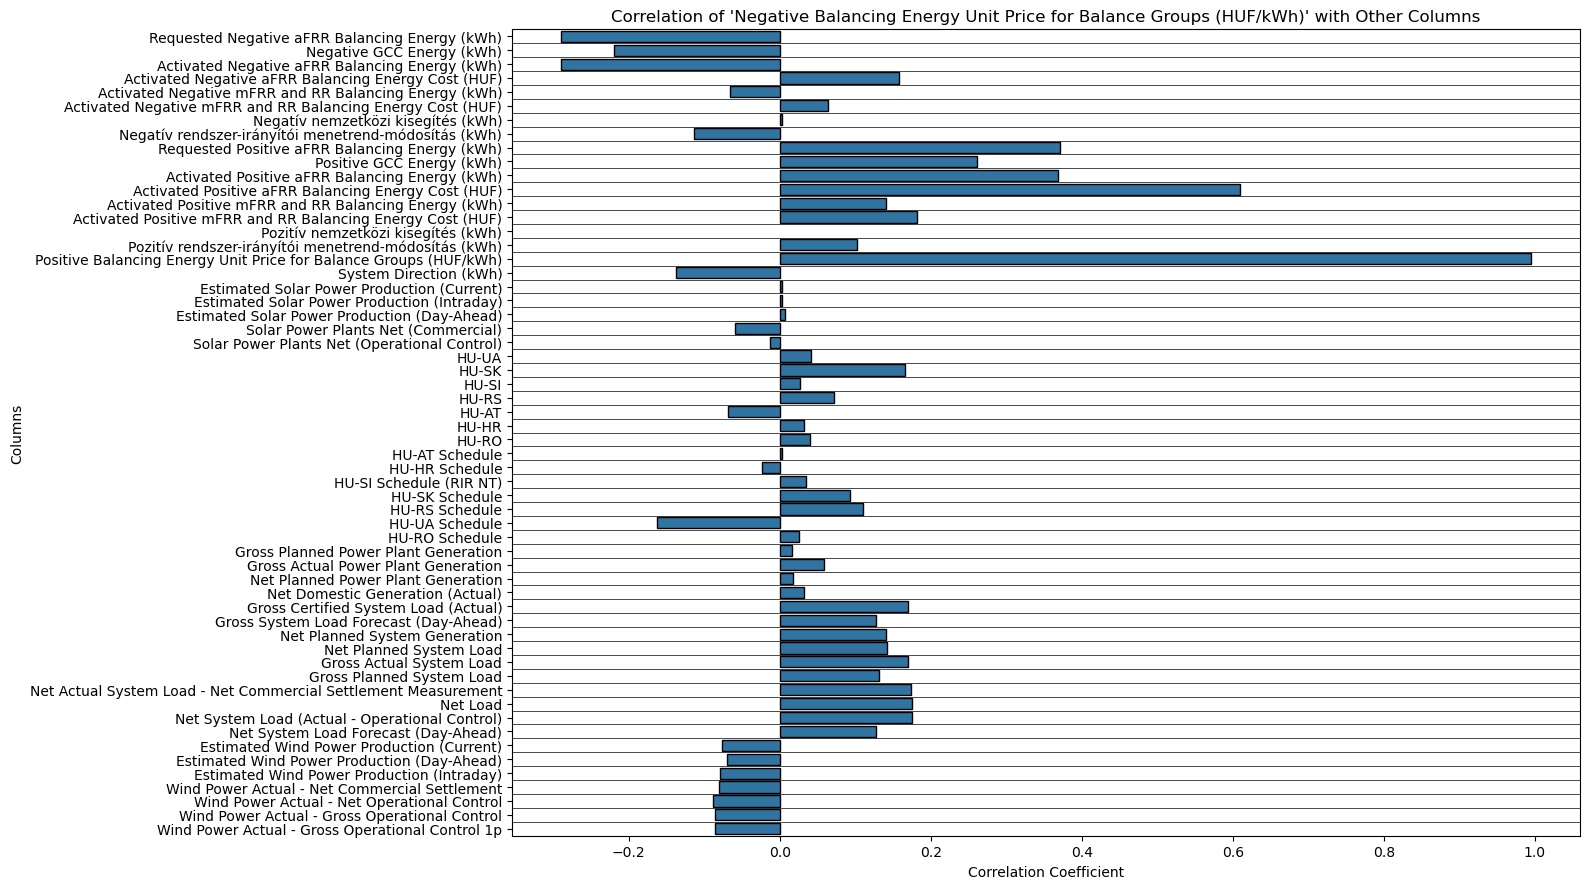

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the correlation matrix, excluding the 'Időpont' column
correlation_matrix = final_df.drop("Időpont").to_pandas().corr()

# Extract the correlations for 'Negatív Mérlegköri kiegyenlítő energia egységára (HUF/kWh)'
target_col = "Negative Balancing Energy Unit Price for Balance Groups (HUF/kWh)"
target_corr = correlation_matrix[target_col].drop(target_col)

# Plot the correlations with slim black lines separating each row
plt.figure(figsize=(16, 9))
sns.barplot(y=target_corr.index, x=target_corr.values, orient="h", edgecolor="black", linewidth=1)
plt.title(f"Correlation of '{target_col}' with Other Columns")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Columns")
plt.tight_layout()

# Add horizontal lines between bars
for i in range(len(target_corr)):
    plt.axhline(i - 0.5, color="black", linewidth=0.5)

plt.show()

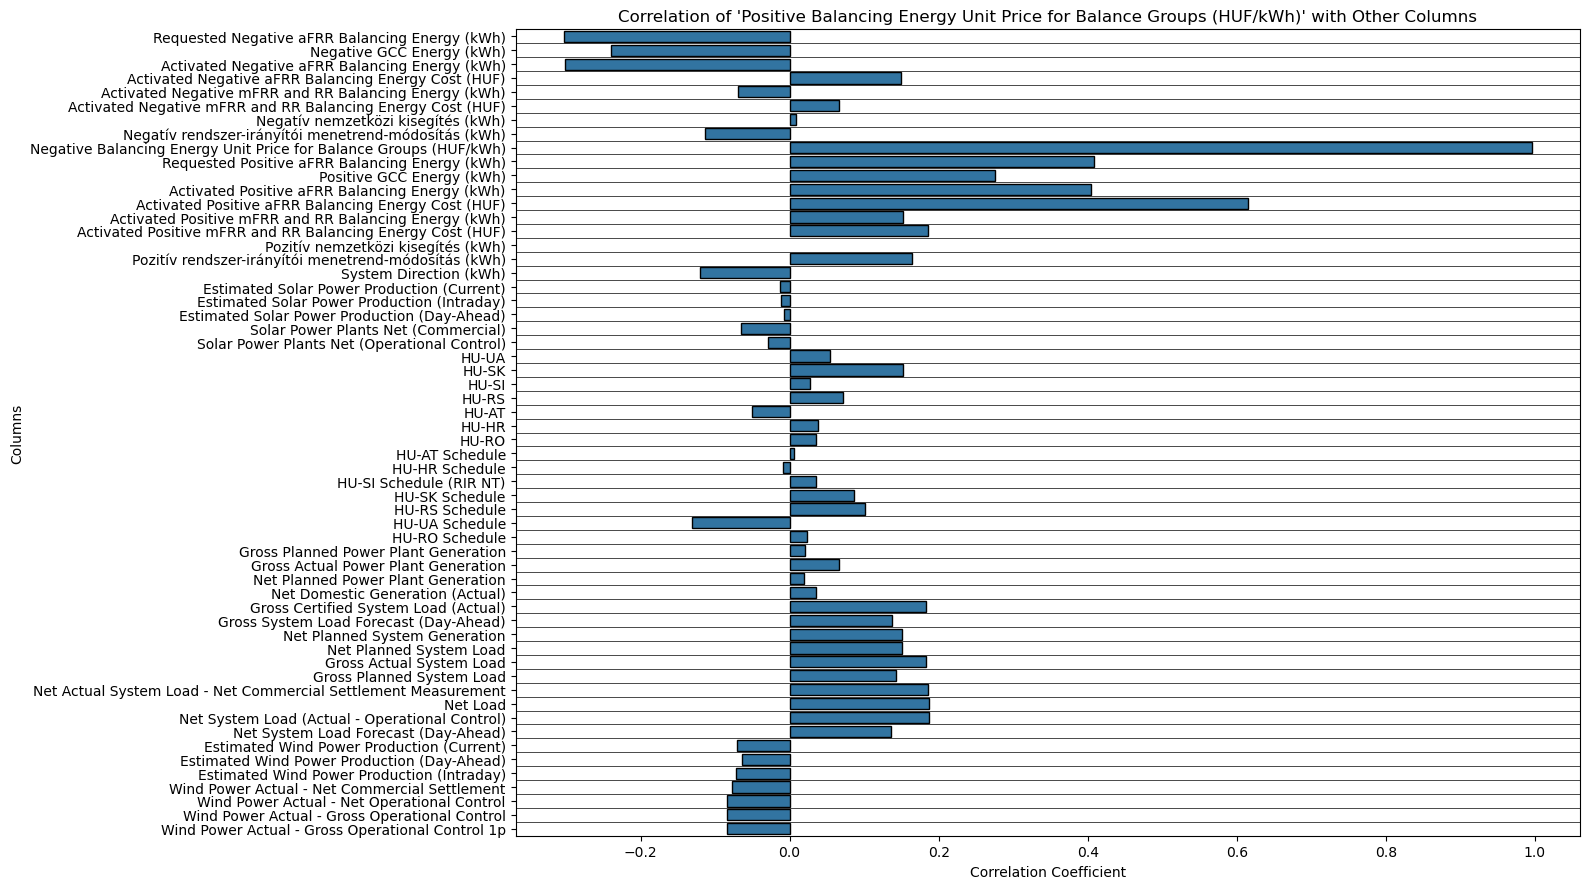

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the correlation matrix, excluding the 'Időpont' column
correlation_matrix = final_df.drop("Időpont").to_pandas().corr()

# Extract the correlations for 'Pozitív Mérlegköri kiegyenlítő energia egységára (HUF/kWh)'
target_col = "Positive Balancing Energy Unit Price for Balance Groups (HUF/kWh)"
target_corr = correlation_matrix[target_col].drop(target_col)

# Plot the correlations with slim black lines separating each row
plt.figure(figsize=(16, 9))
sns.barplot(y=target_corr.index, x=target_corr.values, orient="h", edgecolor="black", linewidth=1)
plt.title(f"Correlation of '{target_col}' with Other Columns")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Columns")
plt.tight_layout()

# Add horizontal lines between bars
for i in range(len(target_corr)):
    plt.axhline(i - 0.5, color="black", linewidth=0.5)

plt.show()

In [5]:
print(final_df.columns)

['Időpont', 'Requested Negative aFRR Balancing Energy (kWh)', 'Negative GCC Energy (kWh)', 'Activated Negative aFRR Balancing Energy (kWh)', 'Activated Negative aFRR Balancing Energy Cost (HUF)', 'Activated Negative mFRR and RR Balancing Energy (kWh)', 'Activated Negative mFRR and RR Balancing Energy Cost (HUF)', 'Negatív nemzetközi kisegítés (kWh)', 'Negatív rendszer-irányítói menetrend-módosítás (kWh)', 'Negative Balancing Energy Unit Price for Balance Groups (HUF/kWh)', 'Requested Positive aFRR Balancing Energy (kWh)', 'Positive GCC Energy (kWh)', 'Activated Positive aFRR Balancing Energy (kWh)', 'Activated Positive aFRR Balancing Energy Cost (HUF)', 'Activated Positive mFRR and RR Balancing Energy (kWh)', 'Activated Positive mFRR and RR Balancing Energy Cost (HUF)', 'Pozitív nemzetközi kisegítés (kWh)', 'Pozitív rendszer-irányítói menetrend-módosítás (kWh)', 'Positive Balancing Energy Unit Price for Balance Groups (HUF/kWh)', 'System Direction (kWh)', 'Estimated Solar Power Product

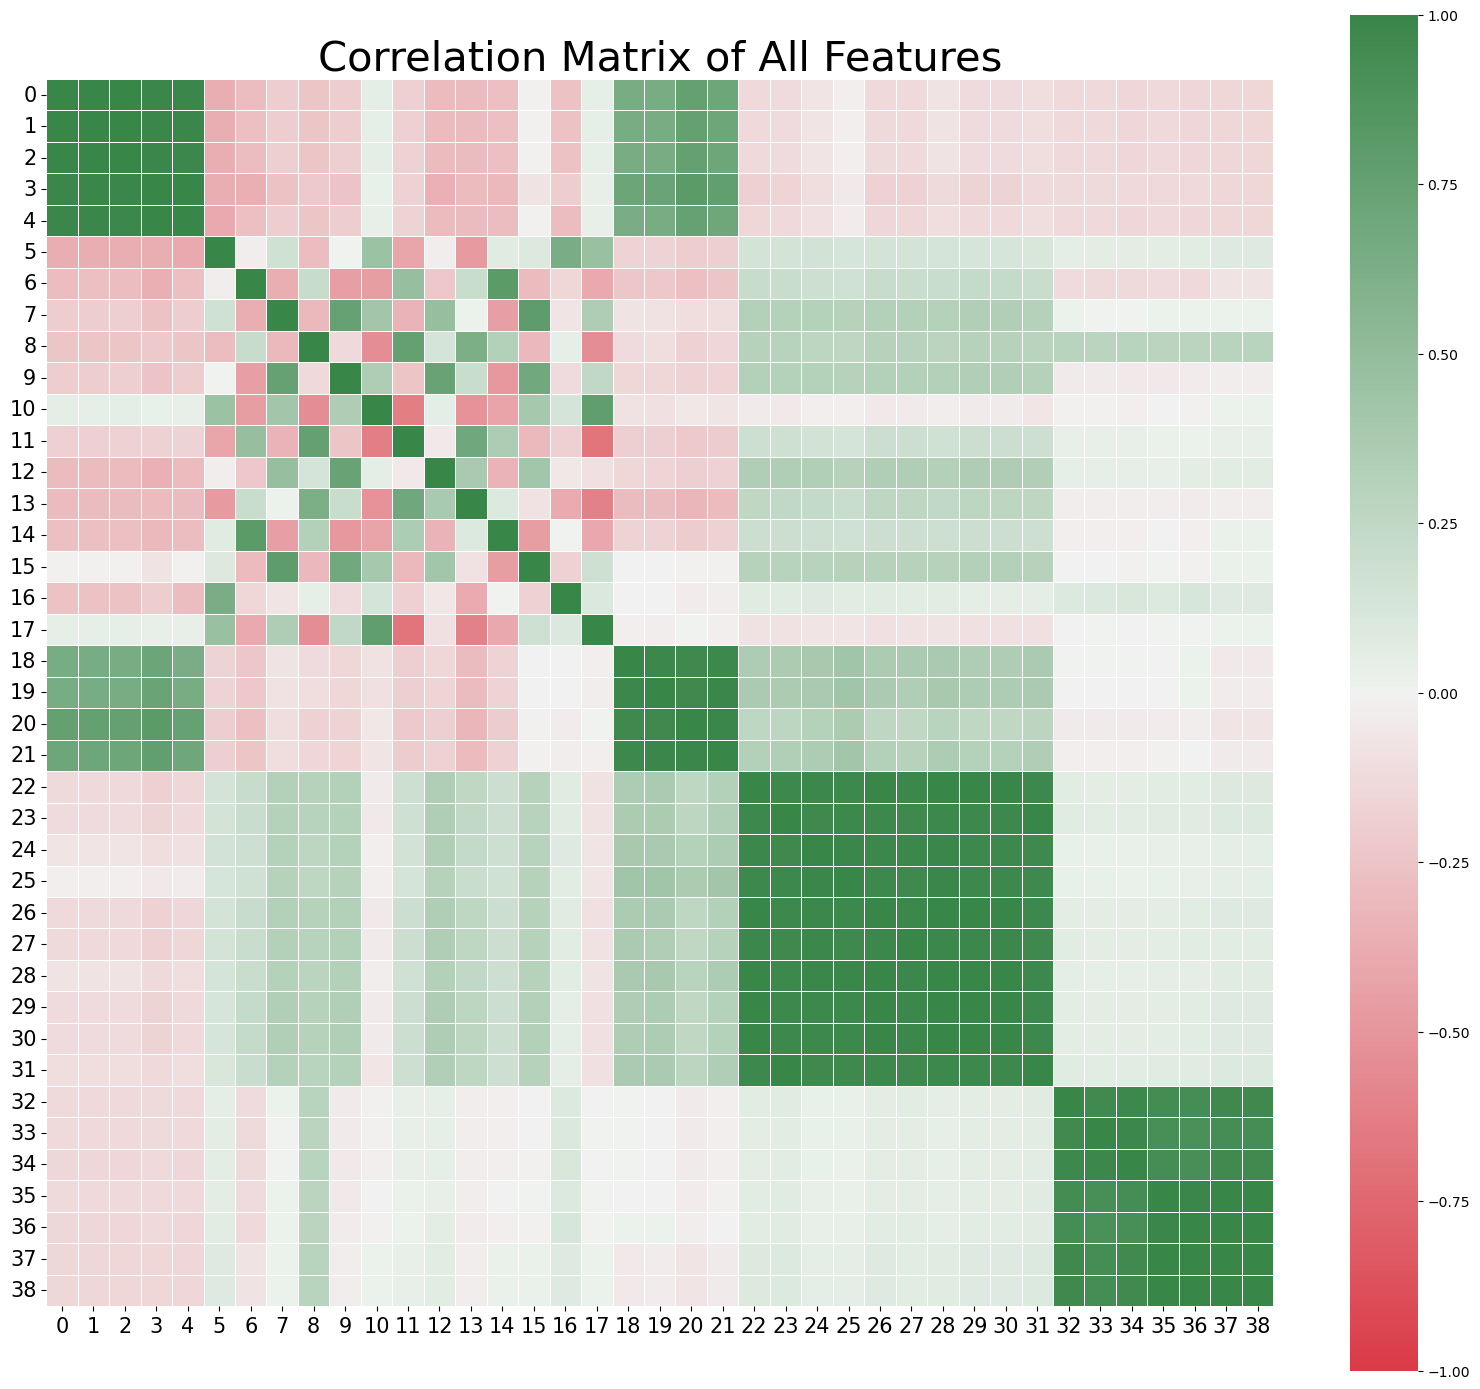

In [6]:
import seaborn as sns

# List of columns to include in the correlation matrix
cols = [
    "Estimated Solar Power Production (Current)",
    "Estimated Solar Power Production (Intraday)",
    "Estimated Solar Power Production (Day-Ahead)",
    "Solar Power Plants Net (Commercial)",
    "Solar Power Plants Net (Operational Control)",
    "HU-UA",
    "HU-SK",
    "HU-RS",
    "HU-AT",
    "HU-HR",
    "HU-RO",
    "HU-AT Schedule",
    "HU-HR Schedule",
    "HU-SI Schedule (RIR NT)",
    "HU-SK Schedule",
    "HU-RS Schedule",
    "HU-UA Schedule",
    "HU-RO Schedule",
    "Gross Planned Power Plant Generation",
    "Gross Actual Power Plant Generation",
    "Net Planned Power Plant Generation",
    "Net Domestic Generation (Actual)",
    "Gross Certified System Load (Actual)",
    "Gross System Load Forecast (Day-Ahead)",
    "Net Planned System Generation",
    "Net Planned System Load",
    "Gross Actual System Load",
    "Gross Planned System Load",
    "Net Actual System Load - Net Commercial Settlement Measurement",
    "Net Load",
    "Net System Load (Actual - Operational Control)",
    "Net System Load Forecast (Day-Ahead)",
    "Estimated Wind Power Production (Current)",
    "Estimated Wind Power Production (Day-Ahead)",
    "Estimated Wind Power Production (Intraday)",
    "Wind Power Actual - Net Commercial Settlement",
    "Wind Power Actual - Net Operational Control",
    "Wind Power Actual - Gross Operational Control",
    "Wind Power Actual - Gross Operational Control 1p",
]

idx_col = {c: i for i, c in enumerate(cols)}
# Filter final_df to get only the desired columns
final_df_subset = final_df.select(cols)

# Convert to a pandas DataFrame
df_corr = final_df_subset.to_pandas().corr()

# Plot the correlation heatmap
plt.figure(figsize=(16, 14))
fig = sns.heatmap(
    df_corr,
    annot=False,
    cmap=sns.diverging_palette(10, 133, as_cmap=True),
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    xticklabels=idx_col.values(),
    yticklabels=idx_col.values(),
    square=True,
)
fig.set_xticklabels(fig.get_xmajorticklabels(), fontsize=15)
fig.set_yticklabels(fig.get_ymajorticklabels(), fontsize=15, rotation=0)
plt.title("Correlation Matrix of All Features", fontdict={"fontsize": 30})
plt.tight_layout()
plt.savefig("figures/correlation_before.png")
plt.show()

In [7]:
idx_col

{'Estimated Solar Power Production (Current)': 0,
 'Estimated Solar Power Production (Intraday)': 1,
 'Estimated Solar Power Production (Day-Ahead)': 2,
 'Solar Power Plants Net (Commercial)': 3,
 'Solar Power Plants Net (Operational Control)': 4,
 'HU-UA': 5,
 'HU-SK': 6,
 'HU-RS': 7,
 'HU-AT': 8,
 'HU-HR': 9,
 'HU-RO': 10,
 'HU-AT Schedule': 11,
 'HU-HR Schedule': 12,
 'HU-SI Schedule (RIR NT)': 13,
 'HU-SK Schedule': 14,
 'HU-RS Schedule': 15,
 'HU-UA Schedule': 16,
 'HU-RO Schedule': 17,
 'Gross Planned Power Plant Generation': 18,
 'Gross Actual Power Plant Generation': 19,
 'Net Planned Power Plant Generation': 20,
 'Net Domestic Generation (Actual)': 21,
 'Gross Certified System Load (Actual)': 22,
 'Gross System Load Forecast (Day-Ahead)': 23,
 'Net Planned System Generation': 24,
 'Net Planned System Load': 25,
 'Gross Actual System Load': 26,
 'Gross Planned System Load': 27,
 'Net Actual System Load - Net Commercial Settlement Measurement': 28,
 'Net Load': 29,
 'Net System 

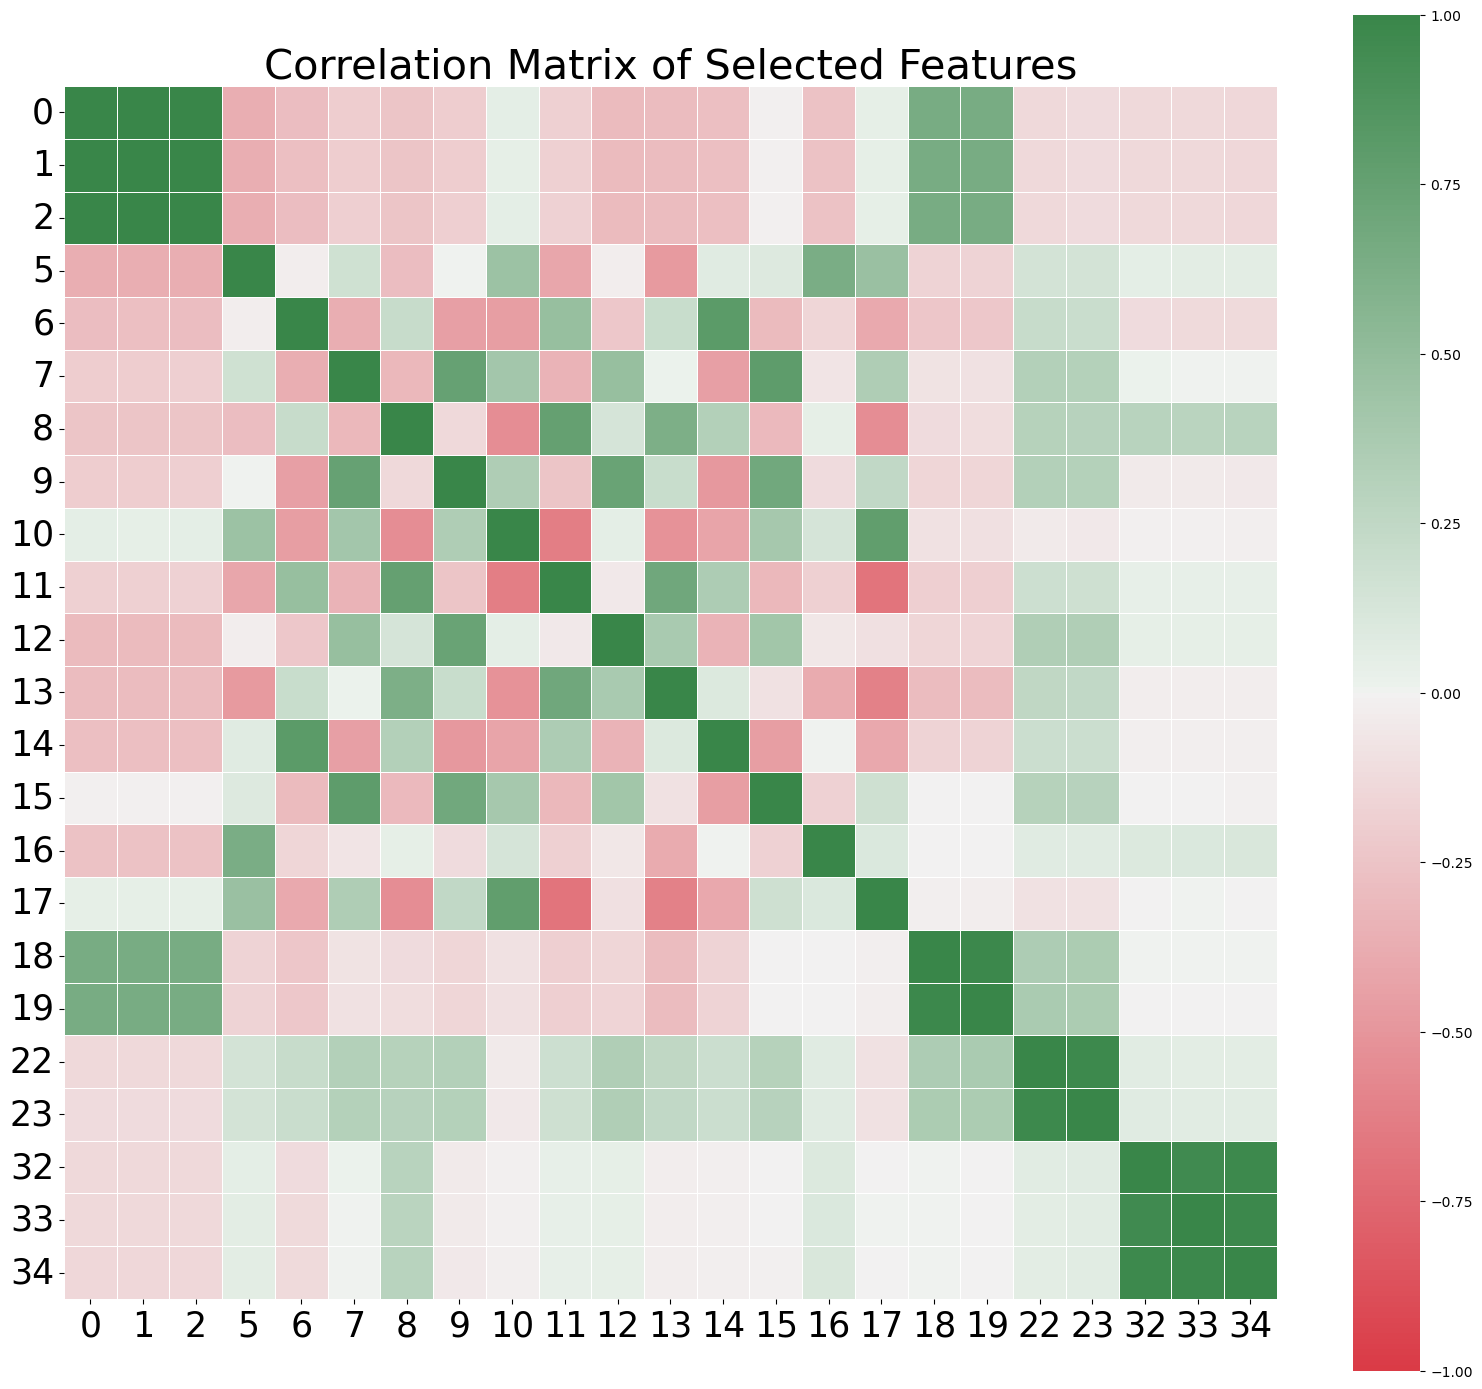

In [8]:
# 04/17 konzi után kivett oszlopokkal:
# List of columns to include in the correlation matrix
cols = [
    "Estimated Solar Power Production (Current)",
    "Estimated Solar Power Production (Intraday)",
    "Estimated Solar Power Production (Day-Ahead)",
    "HU-UA",
    "HU-SK",
    "HU-RS",
    "HU-AT",
    "HU-HR",
    "HU-RO",
    "HU-AT Schedule",
    "HU-HR Schedule",
    "HU-SI Schedule (RIR NT)",
    "HU-SK Schedule",
    "HU-RS Schedule",
    "HU-UA Schedule",
    "HU-RO Schedule",
    "Gross Planned Power Plant Generation",
    "Gross Actual Power Plant Generation",
    "Gross Certified System Load (Actual)",
    "Gross System Load Forecast (Day-Ahead)",
    "Estimated Wind Power Production (Current)",
    "Estimated Wind Power Production (Day-Ahead)",
    "Estimated Wind Power Production (Intraday)",
]

# Filter final_df to get only the desired columns
final_df_subset = final_df.select(cols)

# Convert to a pandas DataFrame
df_corr = final_df_subset.to_pandas().corr()


num_labels = list(map(idx_col.get, cols))
# Plot the correlation heatmap
plt.figure(figsize=(16, 14))
fig = sns.heatmap(
    df_corr,
    annot=False,
    cmap=sns.diverging_palette(10, 133, as_cmap=True),
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    xticklabels=num_labels,
    yticklabels=num_labels,
    square=True,
)
fig.set_xticklabels(fig.get_xmajorticklabels(), fontsize=25)
fig.set_yticklabels(fig.get_ymajorticklabels(), fontsize=25, rotation=0)
plt.title("Correlation Matrix of Selected Features", fontdict={"fontsize": 30})
plt.tight_layout()
plt.savefig("figures/correlation_after.png")
plt.show()

In [9]:
# List of columns to keep
keep_cols = [
    "Időpont",
    "Negatív Mérlegköri kiegyenlítő energia egységára (HUF/kWh)",
    "Pozitív Mérlegköri kiegyenlítő energia egységára (HUF/kWh)",
    "Rendszer-irány (kWh)",
    "Naperőművek becsült termelése (aktuális)",
    "Naperőművek becsült termelése (intraday)",
    "Naperőművek becsült termelése (dayahead)",
    "HU-UK",
    "HU-SK",
    # "HU-SI", too many NaN values
    "HU-RS",
    "HU-AT",
    "HU-HR",
    "HU-RO",
    "HU-AT menetrend",
    "HU-HR menetrend",
    # "HU-SI menetrend (RIR NT)", too many NaN values
    "HU-SK menetrend",
    "HU-RS menetrend",
    "HU-UK menetrend",
    "HU-RO menetrend",
    "Bruttó terv erőművi termelés",
    "Bruttó tény erőművi termelés",
    "Bruttó hitelesített rendszerterhelés tény",
    "Bruttó rendszerterhelés becslés (dayahead)",
    "Szélerőművek becsült termelése (aktuális)",
    "Szélerőművek becsült termelése (dayahead)",
    "Szélerőművek becsült termelése (intraday)",
]

# Filter the DataFrame to keep only the specified columns
final_df = final_df.select(keep_cols)
final_df
# 100-200 NaN max per col (out of 210k), just fill it
final_df = final_df.fill_null(strategy="forward")
# Define columns to create forward lags for
cols_10_h = [
    "Szélerőművek becsült termelése (aktuális)",
    "Szélerőművek becsült termelése (dayahead)",
    "Szélerőművek becsült termelése (intraday)",
    "Naperőművek becsült termelése (aktuális)",
    "Naperőművek becsült termelése (intraday)",
    "Naperőművek becsült termelése (dayahead)",
]

# Max number of 15-minute steps (10 hours)
max_ahead = 40

# Collect all new columns
new_cols = []

for col in cols_10_h:
    for i in range(1, max_ahead + 1):
        new_col_name = f"{col}_t+{i*15}min"
        new_cols.append(pl.col(col).shift(-i).alias(new_col_name))

# Apply with_columns to add all new forward lags
final_df = final_df.with_columns(new_cols)
# Define columns to create forward lags for
cols_12_h = [
    "Bruttó terv erőművi termelés",
    "Bruttó rendszerterhelés becslés (dayahead)",
    "HU-AT menetrend",
    "HU-HR menetrend",
    # "HU-SI menetrend (RIR NT)",
    "HU-SK menetrend",
    "HU-RS menetrend",
    "HU-UK menetrend",
    "HU-RO menetrend",
]

# Max number of 15-minute steps (12 hours)
max_ahead = 48

# Collect all new columns
new_cols = []

for col in cols_12_h:
    for i in range(1, max_ahead + 1):
        new_col_name = f"{col}_t+{i*15}min"
        new_cols.append(pl.col(col).shift(-i).alias(new_col_name))

# Apply with_columns to add all new forward lags
final_df = final_df.with_columns(new_cols)
# Targets to forecast
target_cols = [
    "Negatív Mérlegköri kiegyenlítő energia egységára (HUF/kWh)",
    "Pozitív Mérlegköri kiegyenlítő energia egységára (HUF/kWh)",
    "Rendszer-irány (kWh)",
]

# 15-minute steps for 4h to 5h ahead (i.e., 16 to 20 steps)
ahead_steps = range(16, 21)

# Create forward lag columns
target_future_cols = []

for col in target_cols:
    for i in ahead_steps:
        new_col = f"{col}_t+{i*15}min"
        target_future_cols.append(pl.col(col).shift(-i).alias(new_col))

# Apply to dataframe
final_df = final_df.with_columns(target_future_cols)
# Remove the last 48 rows (12 hours) from the final_df, since forward lags cause NaN values
final_df = final_df.slice(0, final_df.height - 48)
final_df

ColumnNotFoundError: Negatív Mérlegköri kiegyenlítő energia egységára (HUF/kWh)

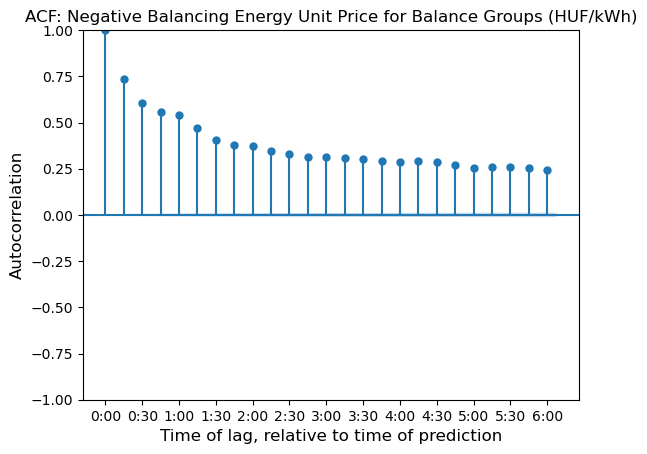

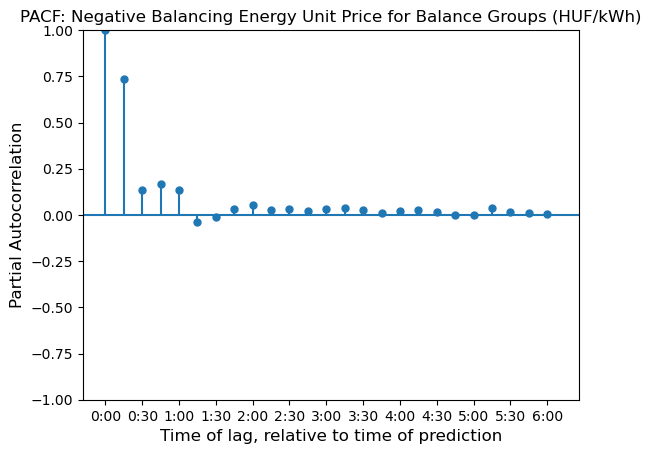

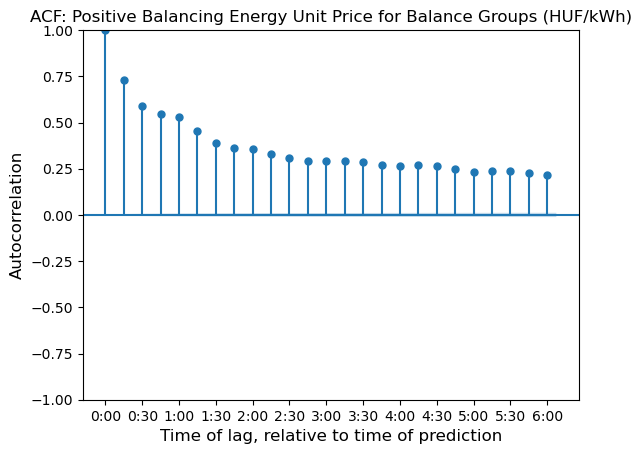

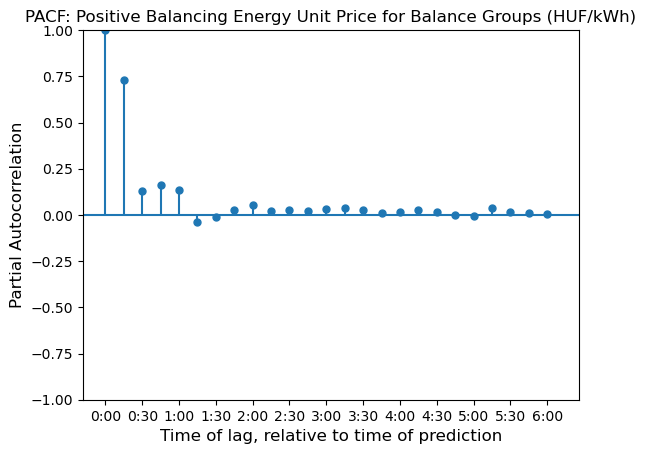

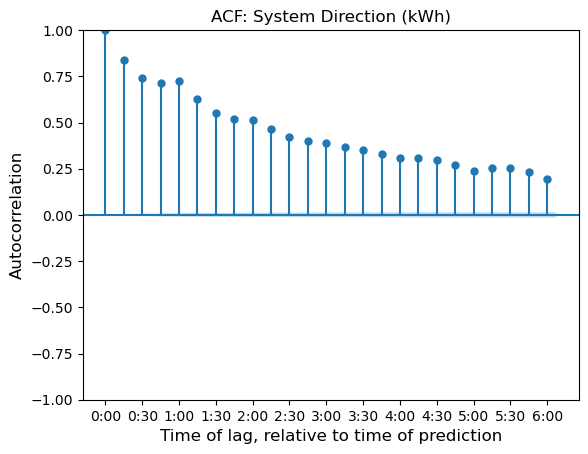

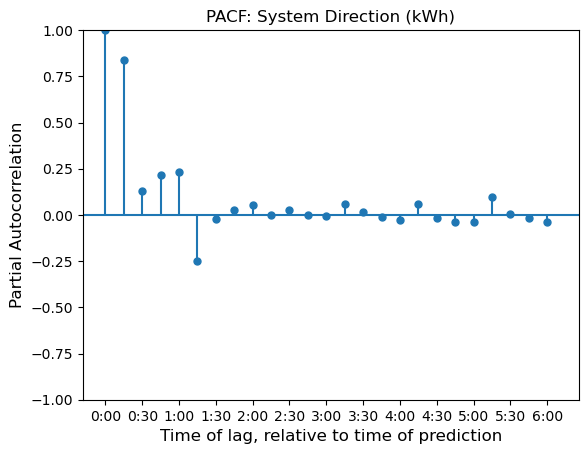

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import polars as pl
import matplotlib.pyplot as plt

# Load the data from parquet
df = pl.read_parquet("data/joined_df.parquet").to_pandas()

target_cols = [
    "Negative Balancing Energy Unit Price for Balance Groups (HUF/kWh)",
    "Positive Balancing Energy Unit Price for Balance Groups (HUF/kWh)",
    "System Direction (kWh)",
]

for col in target_cols:
    series = df[col].dropna()
    # Calculate x-tick labels as hours:minutes for 15-min intervals
    lags = 24
    tick_positions = list(range(0, lags + 1, 2))
    tick_labels = [f"{(i*15)//60}:{(i*15)%60:02d}" for i in tick_positions]

    plot_acf(series, lags=lags, title=f"ACF: {col}")
    plt.xlabel("Time of lag, relative to time of prediction", fontsize=12)
    plt.ylabel("Autocorrelation", fontsize=12)
    plt.xticks(tick_positions, tick_labels)
    plt.show()

    plot_pacf(series, lags=lags, title=f"PACF: {col}")
    plt.xlabel("Time of lag, relative to time of prediction", fontsize=12)
    plt.ylabel("Partial Autocorrelation", fontsize=12)
    plt.xticks(tick_positions, tick_labels)
    plt.show()

In [11]:
### GPU XGB RUNNER
import polars as pl
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import numpy as np
import polars as pl


def timelag_expressions(lags, cols=None):
    if isinstance(lags, int):
        if lags > 0:
            lags = range(1, lags + 1)
        else:
            lags = range(lags, 0)
    if not cols:
        for i in lags:
            yield (pl.all().exclude("Időpont").shift(-i).name.suffix(f"_t{i*15:+}min"))
    else:
        for i in lags:
            for colname in cols:
                yield (pl.col(colname).shift(-i).name.suffix(f"_t{i*15:+}min"))


def create_training_data(df):

    col_stats = (
        df.describe()
        .transpose(column_names="statistic", include_header=True)
        .with_columns((pl.col("null_count") / pl.col("count")).alias("null_ratio"))
    )

    keep_cols = col_stats.filter(pl.col("null_ratio") <= 0.1)["column"]

    final_df = df.select(keep_cols.to_list()).fill_null(strategy="forward")

    cols_10_h = (
        "Estimated Wind Power Production (Current)",
        "Estimated Wind Power Production (Day-Ahead)",
        "Estimated Wind Power Production (Intraday)",
        "Estimated Solar Power Production (Current)",
        "Estimated Solar Power Production (Intraday)",
        "Estimated Solar Power Production (Day-Ahead)",
    )

    cols_12_h = (
        "Gross Planned Power Plant Generation",
        "Gross System Load Forecast (Day-Ahead)",
        "HU-AT Schedule",
        "HU-HR Schedule",
        "HU-SK Schedule",
        "HU-RS Schedule",
        "HU-UA Schedule",
        "HU-RO Schedule",
    )

    target_cols = (
        "Negative Balancing Energy Unit Price for Balance Groups (HUF/kWh)",
        "Positive Balancing Energy Unit Price for Balance Groups (HUF/kWh)",
        "System Direction (kWh)",
    )

    X = final_df.select(
        pl.all(),
        *timelag_expressions(40, cols_10_h),
        *timelag_expressions(48, cols_12_h),
        *timelag_expressions(-40, set(keep_cols) - set(cols_10_h) - set(cols_12_h) - {"Időpont"}),
    )
    y = final_df.select(
        *timelag_expressions(range(1, 6), target_cols),
    )

    X = X.drop_nulls()
    y = y.slice(40, y.height - 48 - 40)

    return (X, y)


# Load and preprocess data
joined_df = pl.read_parquet("./data/joined_df.parquet")
X, y = create_training_data(joined_df)

# Convert Polars to NumPy
X_np = X.to_numpy()
y_np = y.to_numpy()

del joined_df

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_np, y_np, test_size=0.2, shuffle=False)

del X_np, y_np


# Standard scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

del X_train, X_test


from xgboost import XGBRegressor

xgb_base = XGBRegressor()
xgb_base.load_model("xgb_base_model.json")


y_pred_np = xgb_base.predict(X_test_scaled)

# Evaluation
results = []
for idx, col in enumerate(y.columns):
    y_true_col = y_test[:, idx]
    y_pred_col = y_pred_np[:, idx]

    rmse = root_mean_squared_error(y_true_col, y_pred_col)
    mae = mean_absolute_error(y_true_col, y_pred_col)
    r2 = r2_score(y_true_col, y_pred_col)

    # Plotting last 288 predictions
    plt.figure(figsize=(15, 5))
    plt.plot(y_true_col[-288:], label="True")
    plt.plot(y_pred_col[-288:], label="Predicted")

    # Increased font sizes by 50%
    plt.title(f"Last 288 Predictions vs True Values - {col}", fontsize=18)
    plt.xlabel("Time Steps", fontsize=15)
    plt.ylabel("Value", fontsize=15)
    plt.legend(fontsize=13)
    plt.grid(True)

    # Increase tick label sizes
    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)

    plt.tight_layout()
    plt.show()

    results.append({"Target": col, "RMSE": rmse, "MAE": mae, "R²": r2})

# Display metrics
results_df = pd.DataFrame(results)
display(results_df)

XGBoostError: [22:04:26] C:\actions-runner\_work\xgboost\xgboost\src\common\io.cc:146: Opening xgb_base_model.json failed: The system cannot find the file specified.

In [ ]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller, grangercausalitytests

# Convert Polars to pandas
df = final_df.to_pandas()

# Set datetime index
df["Időpont"] = pd.to_datetime(df["Időpont"])
df = df.set_index("Időpont").sort_index()

# 1. Identify target lagged columns
base_targets = [
    "Negatív Mérlegköri kiegyenlítő energia egységára (HUF/kWh)",
    "Pozitív Mérlegköri kiegyenlítő energia egységára (HUF/kWh)",
    "Rendszer-irány (kWh)",
]
target_lags_min = [240, 255, 270, 285, 300]  # 16–20 steps of 15 mins

target_cols = [f"{base}_t+{lag}min" for base in base_targets for lag in target_lags_min]

# 2. Define predictors: all other non-lagged columns (excluding targets and their lags)
predictors = [col for col in df.columns if col not in target_cols and not any(f"_t+" in col for col in [col])]

In [ ]:
# # 3. ADF Test
# print("=== ADF TESTS ===")
# stationarity = {}
# for col in predictors + target_cols:
#     try:
#         pval = adfuller(df[col].dropna())[1]
#         stationarity[col] = pval
#         status = "Stationary" if pval < 0.05 else "Non-stationary"
#         print(f"{col[:55]:<55} | p = {pval:.4f} → {status}")
#     except Exception as e:
#         print(f"{col[:55]:<55} | ADF Error: {e}")

=== ADF TESTS ===
Negatív Mérlegköri kiegyenlítő energia egységára (HUF/k | p = 0.0000 → Stationary
Pozitív Mérlegköri kiegyenlítő energia egységára (HUF/k | p = 0.0000 → Stationary
Rendszer-irány (kWh)                                    | p = 0.0000 → Stationary
Naperőművek becsült termelése (aktuális)                | p = 0.0000 → Stationary
Naperőművek becsült termelése (intraday)                | p = 0.0000 → Stationary
Naperőművek becsült termelése (dayahead)                | p = 0.0000 → Stationary
HU-UK                                                   | p = 0.0000 → Stationary
HU-SK                                                   | p = 0.0000 → Stationary
HU-SI                                                   | p = 0.0000 → Stationary
HU-RS                                                   | p = 0.0000 → Stationary
HU-AT                                                   | p = 0.0000 → Stationary
HU-HR                                                   | p = 0.0000 → Stationary
HU-RO                                                   | p = 0.0000 → Stationary
HU-AT menetrend                                         | p = 0.0000 → Stationary
HU-HR menetrend                                         | p = 0.0000 → Stationary
HU-SI menetrend (RIR NT)                                | p = 0.0000 → Stationary
HU-SK menetrend                                         | p = 0.0000 → Stationary
HU-RS menetrend                                         | p = 0.0000 → Stationary
HU-UK menetrend                                         | p = 0.0000 → Stationary
HU-RO menetrend                                         | p = 0.0000 → Stationary
Bruttó terv erőművi termelés                            | p = 0.0000 → Stationary
Bruttó tény erőművi termelés                            | p = 0.0000 → Stationary
Bruttó hitelesített rendszerterhelés tény               | p = 0.0000 → Stationary
Bruttó rendszerterhelés becslés (dayahead)              | p = 0.0000 → Stationary
Szélerőművek becsült termelése (aktuális)               | p = 0.0000 → Stationary
Szélerőművek becsült termelése (dayahead)               | p = 0.0000 → Stationary
Szélerőművek becsült termelése (intraday)               | p = 0.0000 → Stationary
Negatív Mérlegköri kiegyenlítő energia egységára (HUF/k | p = 0.0000 → Stationary
Negatív Mérlegköri kiegyenlítő energia egységára (HUF/k | p = 0.0000 → Stationary
Negatív Mérlegköri kiegyenlítő energia egységára (HUF/k | p = 0.0000 → Stationary
Negatív Mérlegköri kiegyenlítő energia egységára (HUF/k | p = 0.0000 → Stationary
Negatív Mérlegköri kiegyenlítő energia egységára (HUF/k | p = 0.0000 → Stationary
Pozitív Mérlegköri kiegyenlítő energia egységára (HUF/k | p = 0.0000 → Stationary
Pozitív Mérlegköri kiegyenlítő energia egységára (HUF/k | p = 0.0000 → Stationary
Pozitív Mérlegköri kiegyenlítő energia egységára (HUF/k | p = 0.0000 → Stationary
Pozitív Mérlegköri kiegyenlítő energia egységára (HUF/k | p = 0.0000 → Stationary
Pozitív Mérlegköri kiegyenlítő energia egységára (HUF/k | p = 0.0000 → Stationary
Rendszer-irány (kWh)_t+240min                           | p = 0.0000 → Stationary
Rendszer-irány (kWh)_t+255min                           | p = 0.0000 → Stationary
Rendszer-irány (kWh)_t+270min                           | p = 0.0000 → Stationary
Rendszer-irány (kWh)_t+285min                           | p = 0.0000 → Stationary
Rendszer-irány (kWh)_t+300min                           | p = 0.0000 → Stationary

# 4. Granger Causality Test (lag=4)
print("\n=== GRANGER CAUSALITY TESTS (lag=4) ===")
granger_results = {target: {} for target in target_cols}
max_lag = 4

for target in target_cols:
    print(f"\nTarget: {target}")
    for predictor in predictors:
        try:
            test_df = df[[target, predictor]].dropna()
            if len(test_df) > max_lag + 1:
                test_result = grangercausalitytests(test_df, maxlag=max_lag)
                min_pval = min([test_result[lag][0]["ssr_chi2test"][1] for lag in test_result])
                granger_results[target][predictor] = min_pval
                if min_pval < 0.05:
                    print(f"  {predictor[:40]:<40} → p = {min_pval:.4f} *** Granger-causal")
                else:
                    print(f"  {predictor[:40]:<40} → p = {min_pval:.4f} NOT Granger-causal")
        except Exception as e:
            print(f"  {predictor[:40]:<40} → Error: {e}")

In [ ]:
# Count total number of NaNs per column
nan_counts = final_df.select([pl.col(col).is_null().sum().alias(f"{col}_NaNs") for col in final_df.columns])

# Show total NaNs per column
print(nan_counts)

shape: (1, 665)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ Időpont_N ┆ Negatív   ┆ Pozitív   ┆ Rendszer- ┆ … ┆ Rendszer- ┆ Rendszer- ┆ Rendszer- ┆ Rendszer │
│ aNs       ┆ Mérlegkör ┆ Mérlegkör ┆ irány (kW ┆   ┆ irány (kW ┆ irány (kW ┆ irány (kW ┆ -irány   │
│ ---       ┆ i kiegyen ┆ i kiegyen ┆ h)_NaNs   ┆   ┆ h)_t+255m ┆ h)_t+270m ┆ h)_t+285m ┆ (kWh)_t+ │
│ u32       ┆ lítő…     ┆ lítő…     ┆ ---       ┆   ┆ in_…      ┆ in_…      ┆ in_…      ┆ 300min_… │
│           ┆ ---       ┆ ---       ┆ u32       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│           ┆ u32       ┆ u32       ┆           ┆   ┆ u32       ┆ u32       ┆ u32       ┆ u32      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 0         ┆ 0         ┆ 0         ┆ 0         ┆ … ┆ 0         ┆ 0         ┆ 0         ┆ 0        │
└───────────┴───────────┴───────────┴───────────┴───┴───────────┴──────────

In [1]:
import pandas as pd
import polars as pl
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import statsmodels.api as sm
import numpy as np
from preprocess_dataset_for_training import create_training_data

In [2]:
joined_df = pl.read_parquet("./data/joined_df_with_weather.parquet")
X, y = create_training_data(joined_df)

In [3]:
joined_df

valid_time,number,expver,temp_avg,temp_std,Requested Negative aFRR Balancing Energy (kWh),Negative GCC Energy (kWh),Activated Negative aFRR Balancing Energy (kWh),Activated Negative aFRR Balancing Energy Cost (HUF),Activated Negative mFRR and RR Balancing Energy (kWh),Activated Negative mFRR and RR Balancing Energy Cost (HUF),Negatív nemzetközi kisegítés (kWh),Negatív rendszer-irányítói menetrend-módosítás (kWh),Negative Balancing Energy Unit Price for Balance Groups (HUF/kWh),Óraátállítás,Requested Positive aFRR Balancing Energy (kWh),Positive GCC Energy (kWh),Activated Positive aFRR Balancing Energy (kWh),Activated Positive aFRR Balancing Energy Cost (HUF),Activated Positive mFRR and RR Balancing Energy (kWh),Activated Positive mFRR and RR Balancing Energy Cost (HUF),Pozitív nemzetközi kisegítés (kWh),Pozitív rendszer-irányítói menetrend-módosítás (kWh),Positive Balancing Energy Unit Price for Balance Groups (HUF/kWh),System Direction (kWh),Estimated Solar Power Production (Current),Estimated Solar Power Production (Intraday),Estimated Solar Power Production (Day-Ahead),Solar Power Plants Net (Commercial),Solar Power Plants Net (Operational Control),HU-UA,HU-SK,HU-SI,HU-RS,HU-AT,HU-HR,HU-RO,HU-AT Schedule,HU-HR Schedule,HU-SI Schedule (RIR NT),HU-SK Schedule,HU-RS Schedule,HU-UA Schedule,HU-RO Schedule,Gross Planned Power Plant Generation,Gross Actual Power Plant Generation,Net Planned Power Plant Generation,Net Domestic Generation (Actual),Gross Certified System Load (Actual),Gross System Load Forecast (Day-Ahead),Net Planned System Generation,Net Planned System Load,Gross Actual System Load,Gross Planned System Load,Net Actual System Load - Net Commercial Settlement Measurement,Net Load,Net System Load (Actual - Operational Control),Net System Load Forecast (Day-Ahead),Estimated Wind Power Production (Current),Estimated Wind Power Production (Day-Ahead),Estimated Wind Power Production (Intraday),Wind Power Actual - Net Commercial Settlement,Wind Power Actual - Net Operational Control,Wind Power Actual - Gross Operational Control,Wind Power Actual - Gross Operational Control 1p
"datetime[μs, Europe/Budapest]",i64,str,f32,f32,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2019-01-01 00:15:00 CET,0,"""0001""",-0.133809,1.6542,0.0,0.0,0.0,0.0,0.0,0.0,null,null,25.19219,1,5981.41667,7546.0,5981.42,198269.72,0.0,0.0,null,null,41.10305,13527.42,0.0,0.0,0.0,null,1.811,672.907,1628.383,null,-441.663,365.09,-1323.96,-252.413,600.0,-302.0,null,1285.0,-919.0,612.0,-634.5,3724.12,3734.98,3398.374,3398.581,4360.0,4245.0,4032.314,4045.403,4364.971,4377.62,4030.38,4116.652,4116.652,3816.269,17.285,17.285,17.285,22.151,21.346,null,null
2019-01-01 00:30:00 CET,0,"""0001""",-0.133809,1.6542,0.0,0.0,0.0,0.0,0.0,0.0,null,null,21.80806,1,10450.08333,6.0,10351.75,297041.62,0.0,0.0,null,null,35.58158,10456.08,0.0,0.0,0.0,null,1.811,666.88,1796.303,null,-532.027,539.847,-1493.383,-312.673,600.0,-302.0,null,1285.0,-919.0,612.0,-634.5,3685.35,3706.073,3364.349,3357.024,4333.0,4218.0,3998.319,4008.314,4342.022,4338.85,4003.836,4095.698,4095.698,3789.24,17.407,17.407,17.407,16.588,16.244,null,null
2019-01-01 00:45:00 CET,0,"""0001""",-0.133809,1.6542,0.0,0.0,0.0,0.0,0.0,0.0,null,null,21.43053,1,11115.33333,2314.0,10708.0,301944.95,0.0,0.0,null,null,34.96561,13429.33,0.0,0.0,0.0,null,1.811,649.29,1830.697,null,-528.733,509.727,-1525.147,-283.383,600.0,-302.0,null,1285.0,-919.0,612.0,-634.5,3668.83,3655.859,3350.146,3337.298,4302.0,4177.0,3984.078,3995.549,4308.544,4322.33,3969.57,4065.177,4065.177,3748.994,20.485,20.485,20.485,8.44,7.432,null,null
2019-01-01 01:00:00 CET,0,"""0001""",-0.471332,1.652672,0.0,0.0,0.0,0.0,0.0,0.0,null,null,24.30898,1,20087.25,19918.0,18550.33,593341.68,0.0,0.0,null,null,39.66202,40005.25,0.0,0.0,0.0,null,1.812,675.547,1877.437,null,-

In [4]:
X.columns

['temp_avg',
 'temp_std',
 'Requested Negative aFRR Balancing Energy (kWh)',
 'Negative GCC Energy (kWh)',
 'Activated Negative aFRR Balancing Energy (kWh)',
 'Activated Negative aFRR Balancing Energy Cost (HUF)',
 'Activated Negative mFRR and RR Balancing Energy (kWh)',
 'Activated Negative mFRR and RR Balancing Energy Cost (HUF)',
 'Negative Balancing Energy Unit Price for Balance Groups (HUF/kWh)',
 'Óraátállítás',
 'Requested Positive aFRR Balancing Energy (kWh)',
 'Positive GCC Energy (kWh)',
 'Activated Positive aFRR Balancing Energy (kWh)',
 'Activated Positive aFRR Balancing Energy Cost (HUF)',
 'Activated Positive mFRR and RR Balancing Energy (kWh)',
 'Activated Positive mFRR and RR Balancing Energy Cost (HUF)',
 'Positive Balancing Energy Unit Price for Balance Groups (HUF/kWh)',
 'System Direction (kWh)',
 'Estimated Solar Power Production (Current)',
 'Estimated Solar Power Production (Intraday)',
 'Estimated Solar Power Production (Day-Ahead)',
 'Solar Power Plants Net (Op

In [5]:
### GPU XGB RUNNER
import polars as pl
import cupy as cp
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from preprocess_dataset_for_training import create_training_data

# Load and preprocess data
joined_df = pl.read_parquet("./data/joined_df_with_weather.parquet")
X, y = create_training_data(joined_df)

# Convert Polars to NumPy
X_np = X.to_numpy()
y_np = y.to_numpy()

del joined_df, X

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_np, y_np, test_size=0.2, shuffle=False)

del X_np, y_np


# Standard scaling on CPU first
scaler = StandardScaler()
X_train_scaled_cpu = scaler.fit_transform(X_train)
X_test_scaled_cpu = scaler.transform(X_test)
del X_train, X_test

# Convert to CuPy arrays for GPU usage
X_train_scaled = cp.asarray(X_train_scaled_cpu)
del X_train_scaled_cpu
X_test_scaled = cp.asarray(X_test_scaled_cpu)
del X_test_scaled_cpu





# Define XGBoost GPU model
xgb_base = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.01,
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
    device="cuda"
)

# Multi-output regressor
print("Fitting model...")
xgb_base.fit(X_train_scaled, y_train)



y_pred_np = xgb_base.predict(X_test_scaled)


Fitting model...


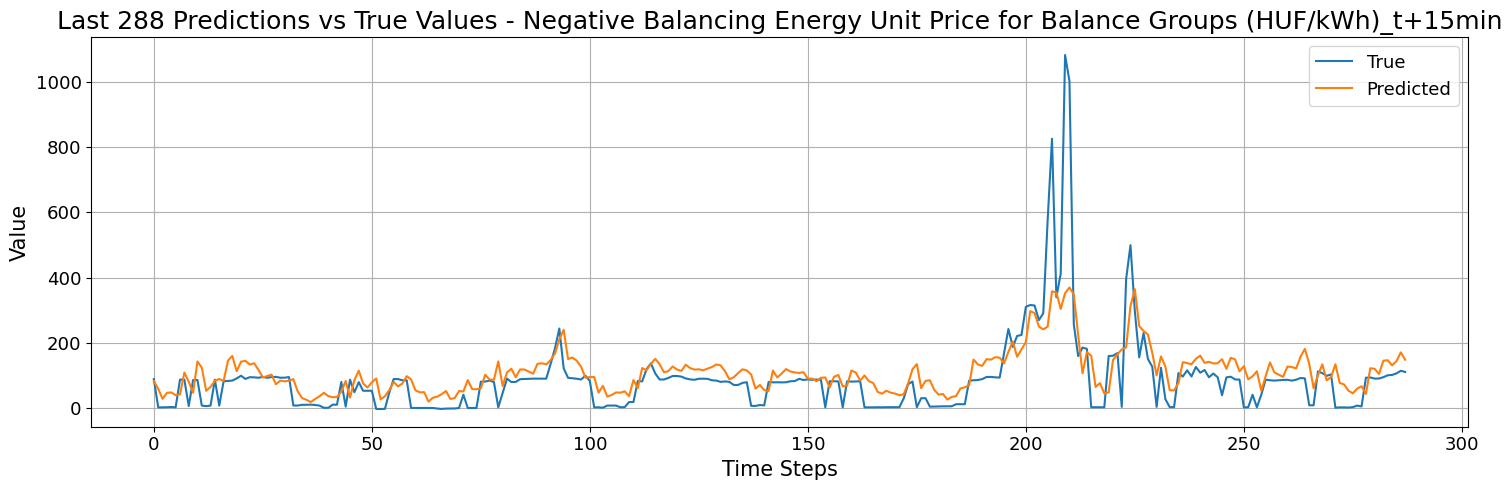

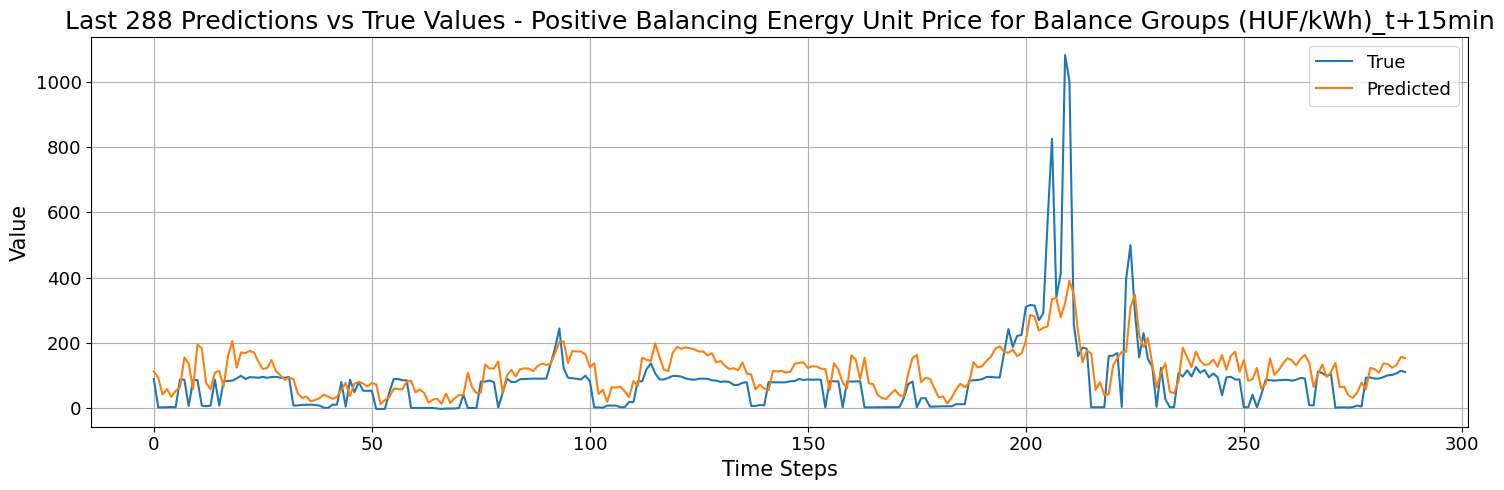

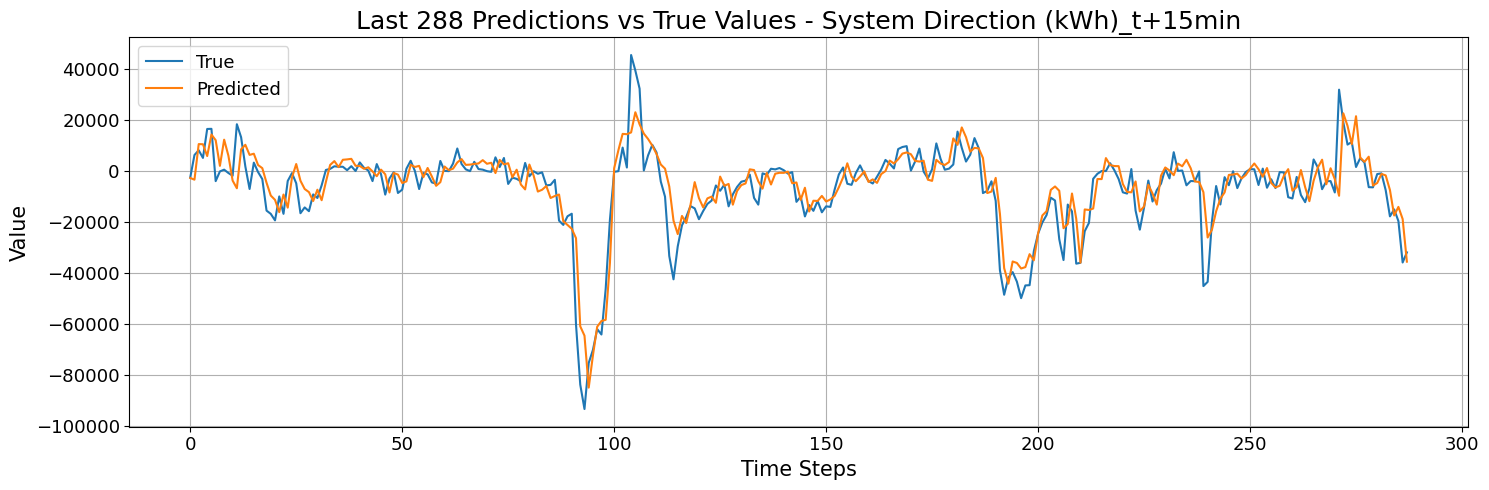

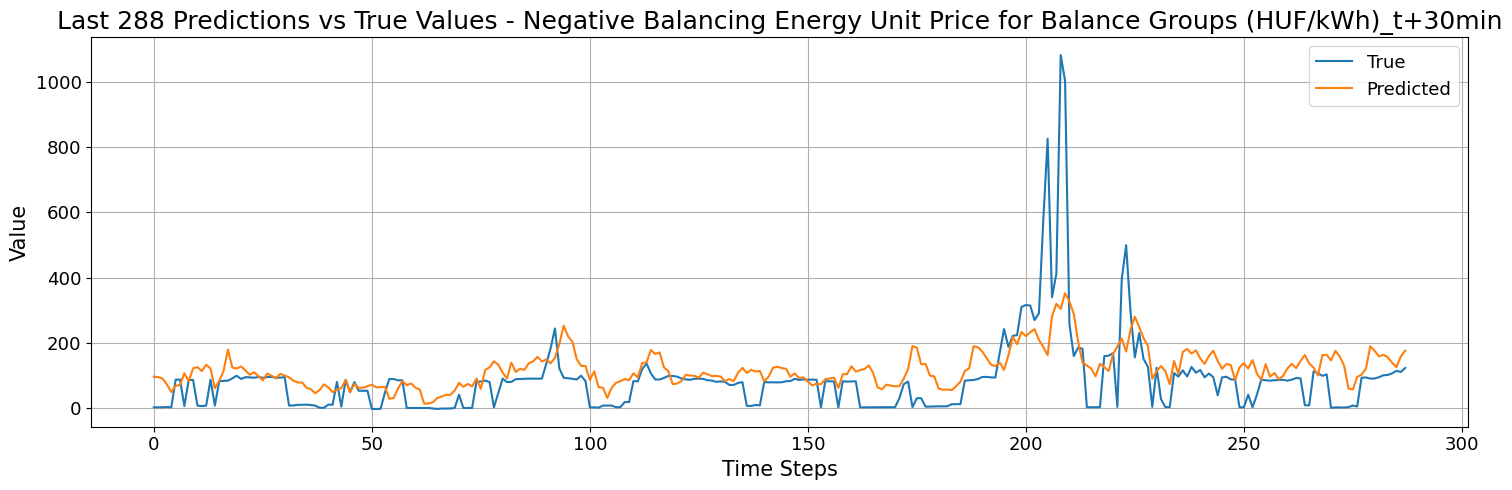

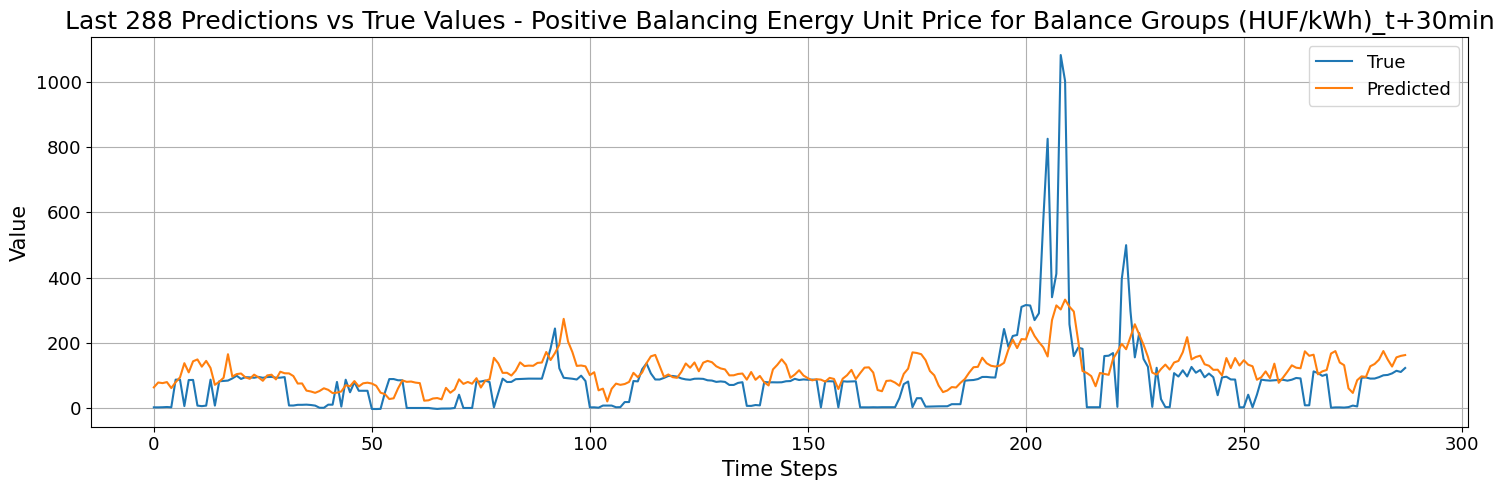

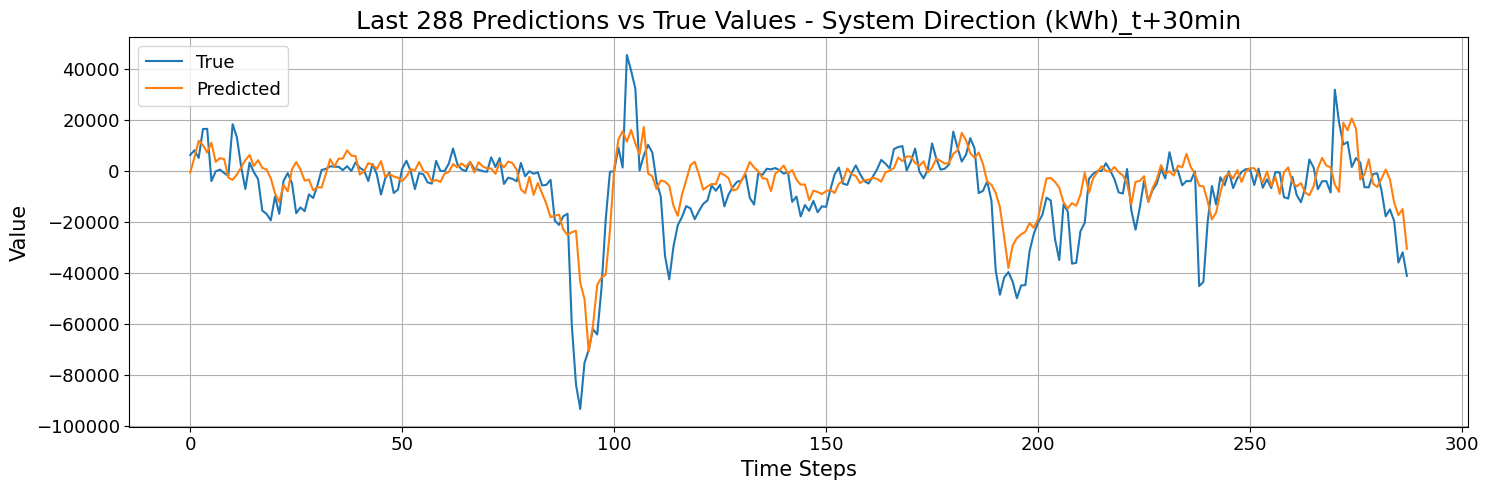

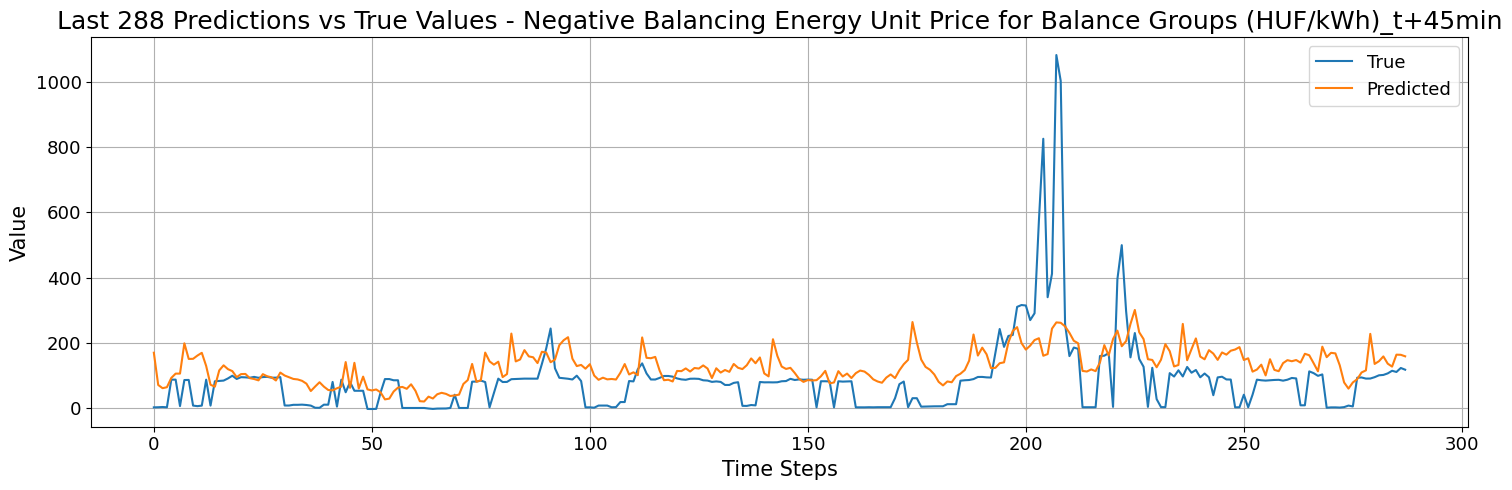

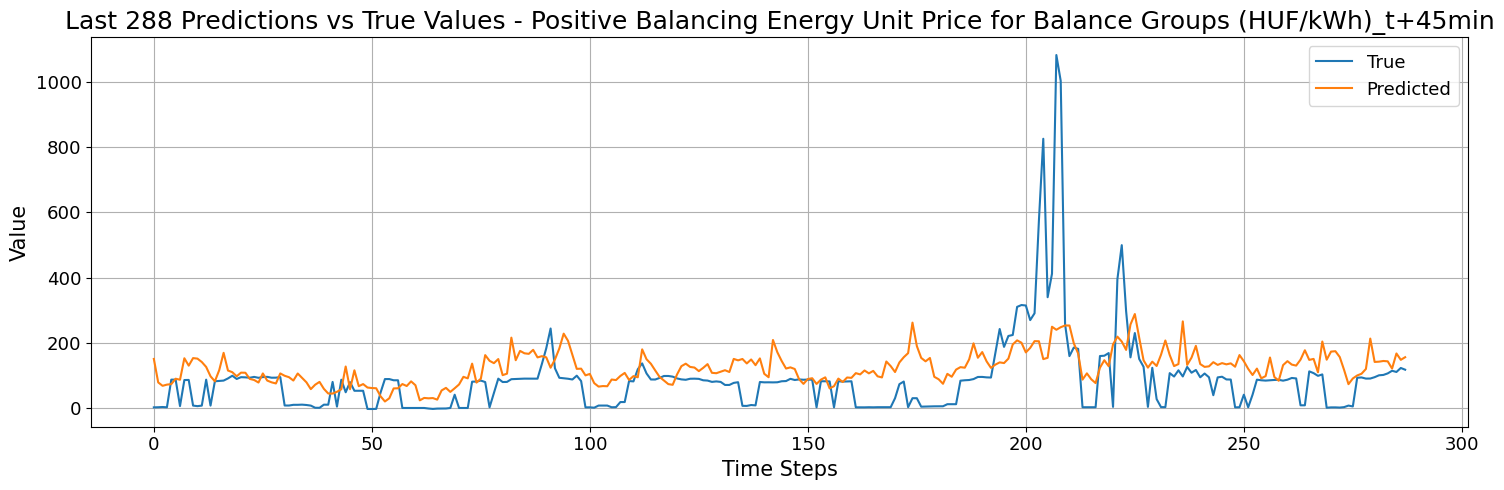

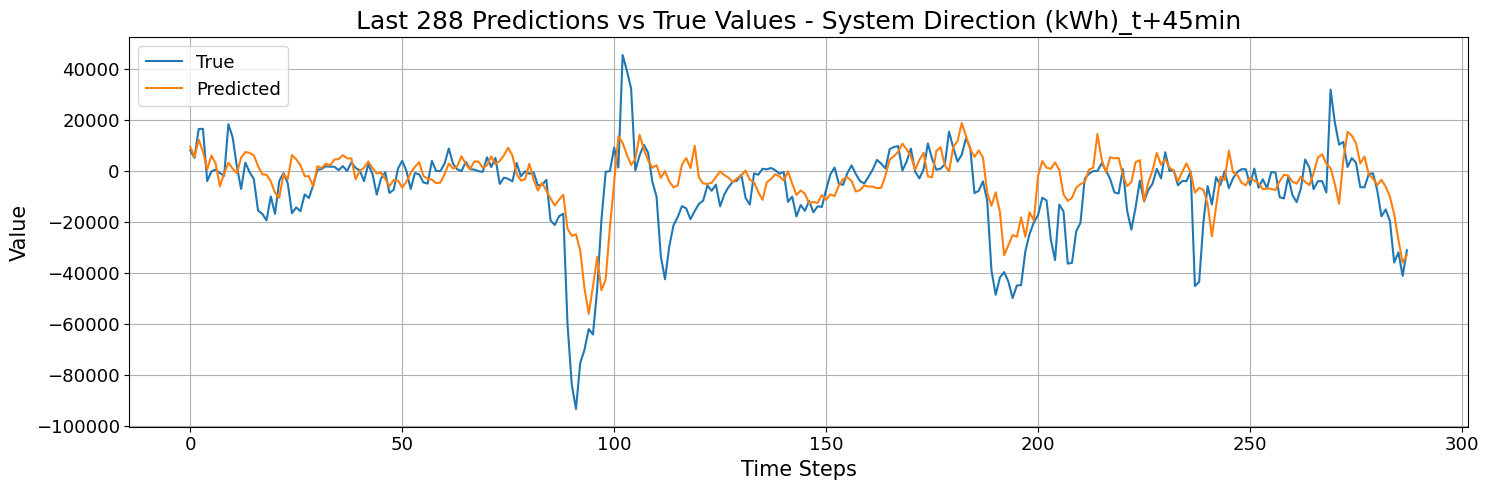

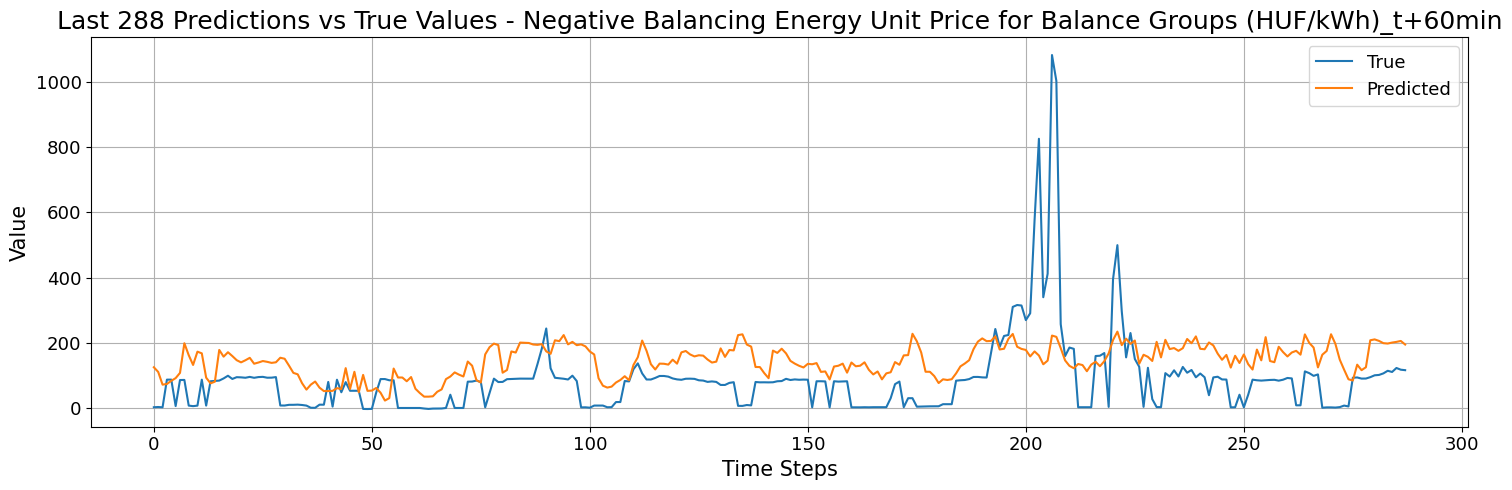

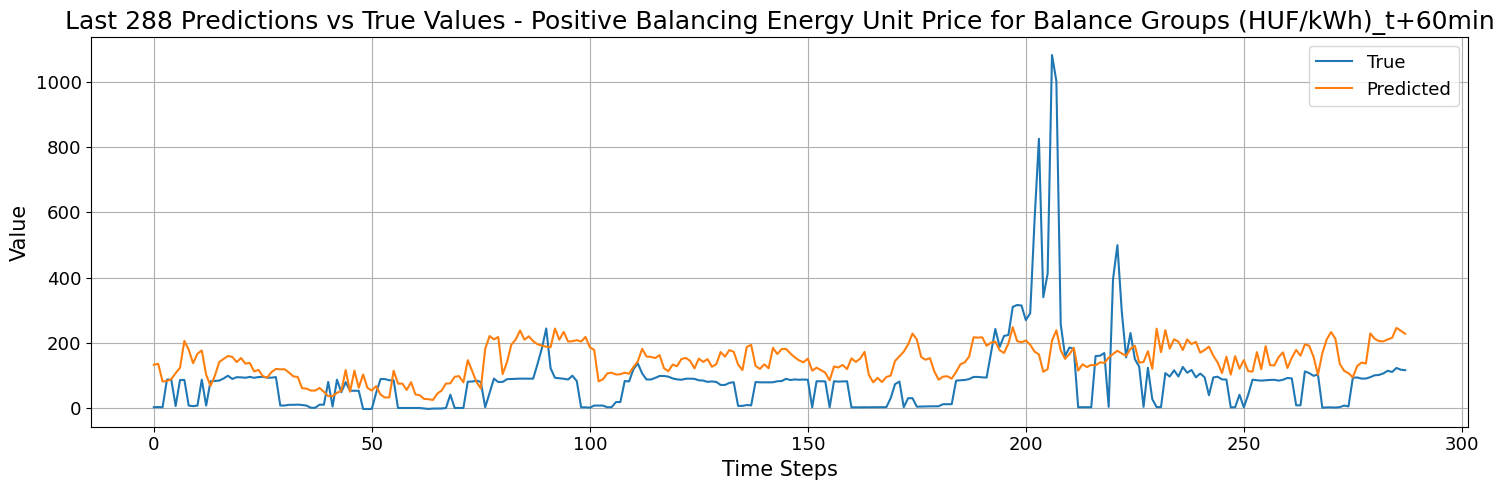

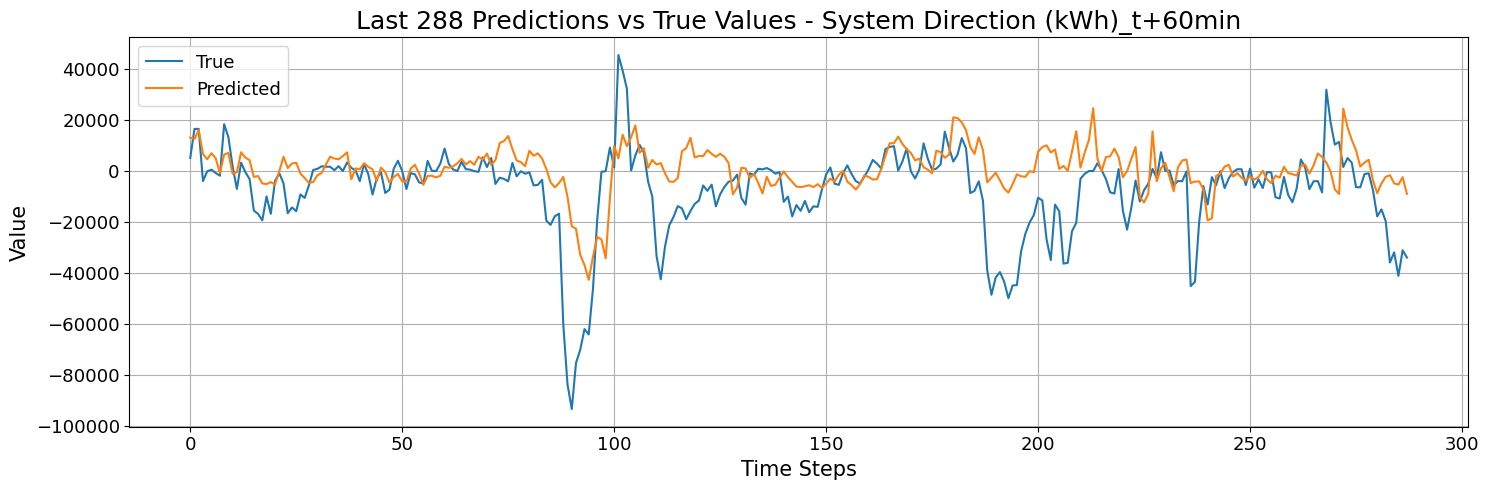

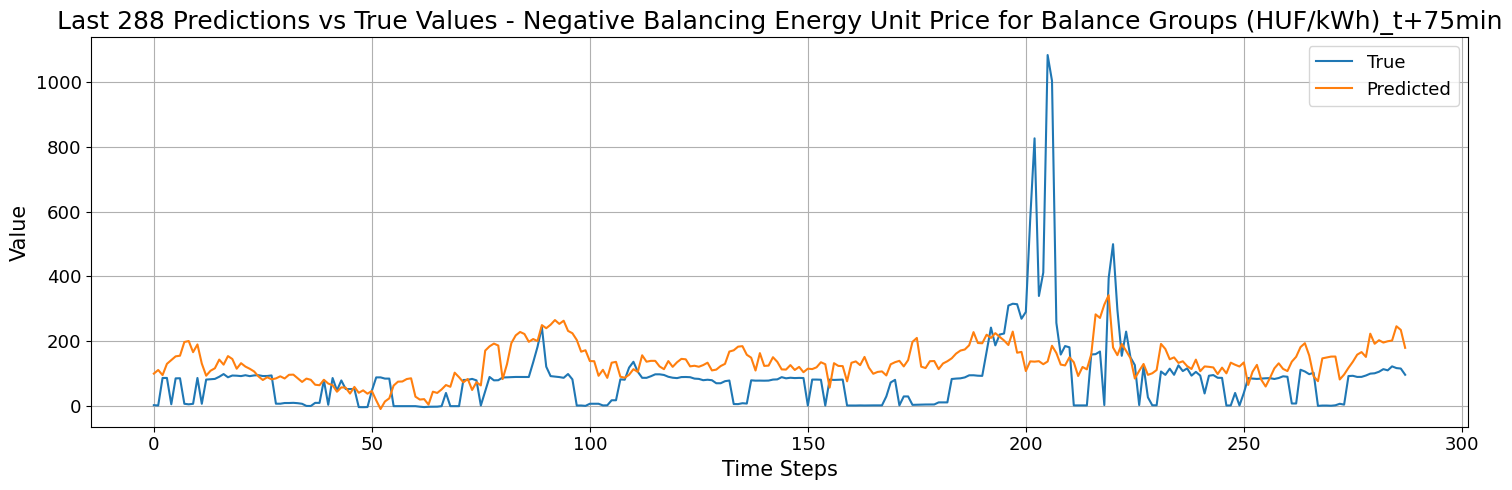

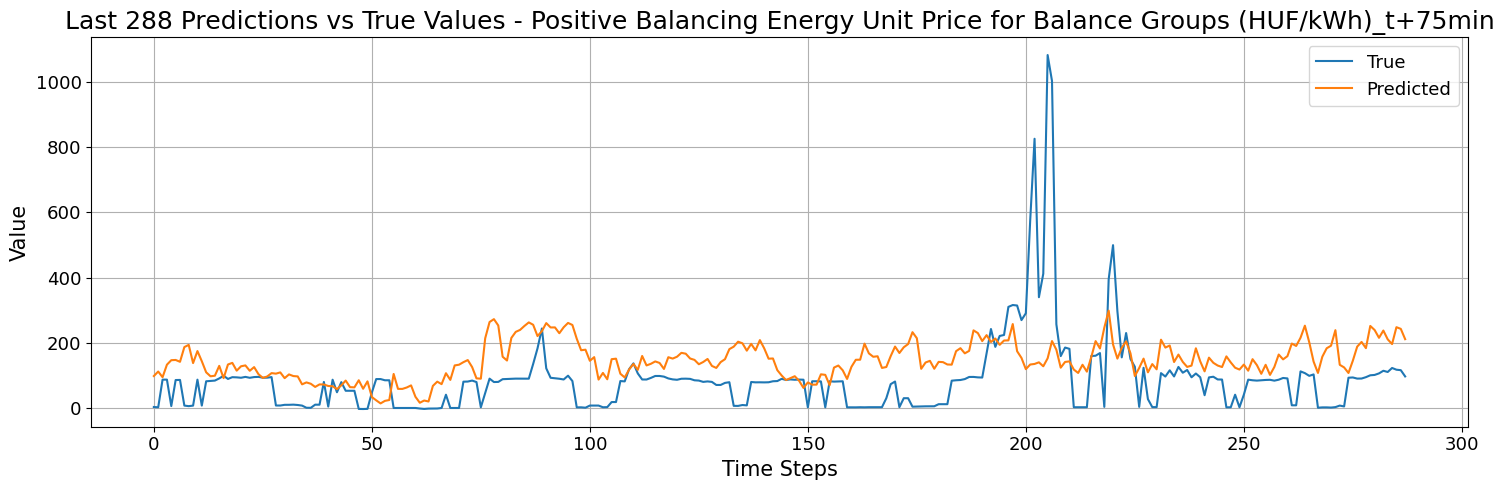

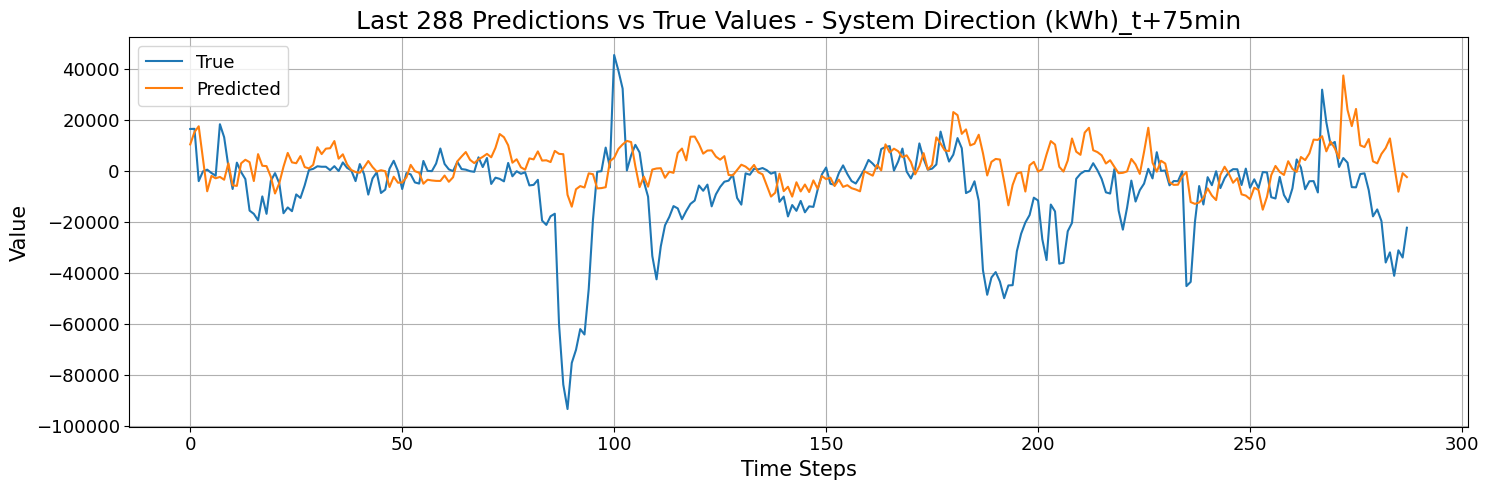

,Target,RMSE,MAE,R²
0,Negative Balancing Energy Unit Price for Balan...,76.434368,44.607331,0.370935
1,Positive Balancing Energy Unit Price for Balan...,76.146900,44.121083,0.375658
2,System Direction (kWh)_t+15min,15551.270962,10059.351118,0.677979
3,Negative Balancing Energy Unit Price for Balan...,91.432057,59.578335,0.099446
4,Positive Balancing Energy Unit Price for Balan...,90.937354,59.286061,0.109165
5,System Direction (kWh)_t+30min,18876.639952,12214.841707,0.525451
6,Negative Balancing Energy Unit Price for Balan...,98.994231,67.058838,-0.055990
7,Positive Balancing Energy Unit Price for Balan...,98.796470,67.320035,-0.051775
8,System Direction (kWh)_t+45min,20928.379508,13400.729575,0.416540
9,Negative Balancing Energy Unit Price for Balan...,106.226242,74.094293,-0.216348


In [ ]:

# Evaluation
results = []
for idx, col in enumerate(y.columns):
    y_true_col = y_test[:, idx]
    y_pred_col = y_pred_np[:, idx]

    rmse = root_mean_squared_error(y_true_col, y_pred_col)
    mae = mean_absolute_error(y_true_col, y_pred_col)
    r2 = r2_score(y_true_col, y_pred_col)

    # Plotting last 288 predictions
    plt.figure(figsize=(15, 5))
    plt.plot(y_true_col[-288:], label="True")
    plt.plot(y_pred_col[-288:], label="Predicted")

    # Increased font sizes by 50%
    plt.title(f"Last 288 Predictions vs True Values - {col}", fontsize=18)
    plt.xlabel("Time Steps", fontsize=15)
    plt.ylabel("Value", fontsize=15)
    plt.legend(fontsize=13)
    plt.grid(True)

    # Increase tick label sizes
    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)

    plt.tight_layout()
    plt.show()

    results.append({"Target": col, "RMSE": rmse, "MAE": mae, "R²": r2})

# Display metrics
results_df = pd.DataFrame(results)
display(results_df)

In [ ]:
from preprocess_dataset_for_training import create_training_data

joined_df = pl.read_parquet("data/joined_df.parquet")
X, y = create_training_data(joined_df)
y

Negatív Mérlegköri kiegyenlítő energia egységára (HUF/kWh)_t+240min,Pozitív Mérlegköri kiegyenlítő energia egységára (HUF/kWh)_t+240min,Rendszer-irány (kWh)_t+240min,Negatív Mérlegköri kiegyenlítő energia egységára (HUF/kWh)_t+255min,Pozitív Mérlegköri kiegyenlítő energia egységára (HUF/kWh)_t+255min,Rendszer-irány (kWh)_t+255min,Negatív Mérlegköri kiegyenlítő energia egységára (HUF/kWh)_t+270min,Pozitív Mérlegköri kiegyenlítő energia egységára (HUF/kWh)_t+270min,Rendszer-irány (kWh)_t+270min,Negatív Mérlegköri kiegyenlítő energia egységára (HUF/kWh)_t+285min,Pozitív Mérlegköri kiegyenlítő energia egységára (HUF/kWh)_t+285min,Rendszer-irány (kWh)_t+285min,Negatív Mérlegköri kiegyenlítő energia egységára (HUF/kWh)_t+300min,Pozitív Mérlegköri kiegyenlítő energia egységára (HUF/kWh)_t+300min,Rendszer-irány (kWh)_t+300min
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
24.17198,39.43849,15123.83,23.60712,38.51688,14764.67,24.80155,40.46569,7149.33,3.20021,5.2214,-13976.5,3.49512,5.70257,-6077.42
23.60712,38.51688,14764.67,24.80155,40.46569,7149.33,3.20021,5.2214,-13976.5,3.49512,5.70257,-6077.42,27.885,45.49658,2516.42
24.80155,40.46569,7149.33,3.20021,5.2214,-13976.5,3.49512,5.70257,-6077.42,27.885,45.49658,2516.42,23.65367,38.59283,13829.08
3.20021,5.2214,-13976.5,3.49512,5.70257,-6077.42,27.885,45.49658,2516.42,23.65367,38.59283,13829.08,3.17945,5.18752,-28613.75
3.49512,5.70257,-6077.42,27.885,45.49658,2516.42,23.65367,38.59283,13829.08,3.17945,5.18752,-28613.75,3.23381,5.27622,-10917.42
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
220.12873,220.12873,-35139.58333,243.84265,243.84265,-33338.25,208.49996,208.49996,-27891.0,279.25912,279.25912,-32586.5,347.72525,347.72525,-37439.41667
243.84265,243.84265,-33338.25,208.49996,208.49996,-27891.0,279.25912,279.25912,-32586.5,347.72525,347.72525,-37439.41667,679.13146,679.13146,-22593.41667
208.49996,208.49996,-27891.0,279.25912,279.25912,-32586.5,347.72525,347.72525,-37439.41667,679.13146,679.13146,-22593.41667,430.35668,430.35668,-19580.75


Processing target: Negative Balancing Energy Unit Price for Balance Groups (HUF/kWh)_t+15min
RMSE: 72.7235, MAE: 38.5456, R²: 0.4305


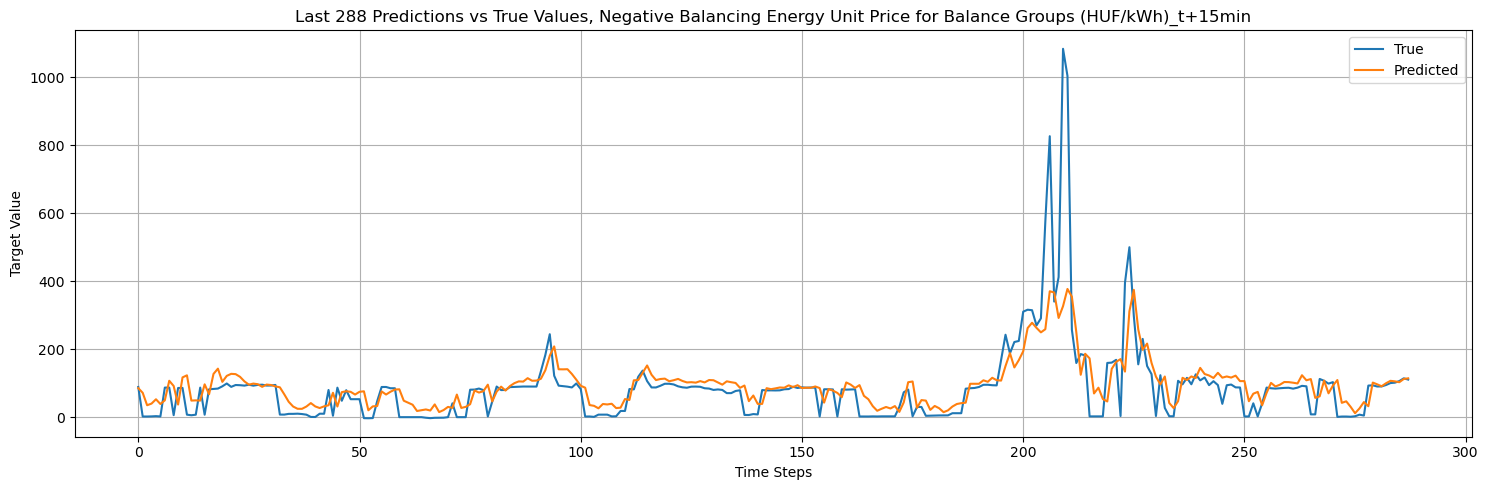

Processing target: Positive Balancing Energy Unit Price for Balance Groups (HUF/kWh)_t+15min
RMSE: 72.9305, MAE: 39.2660, R²: 0.4273


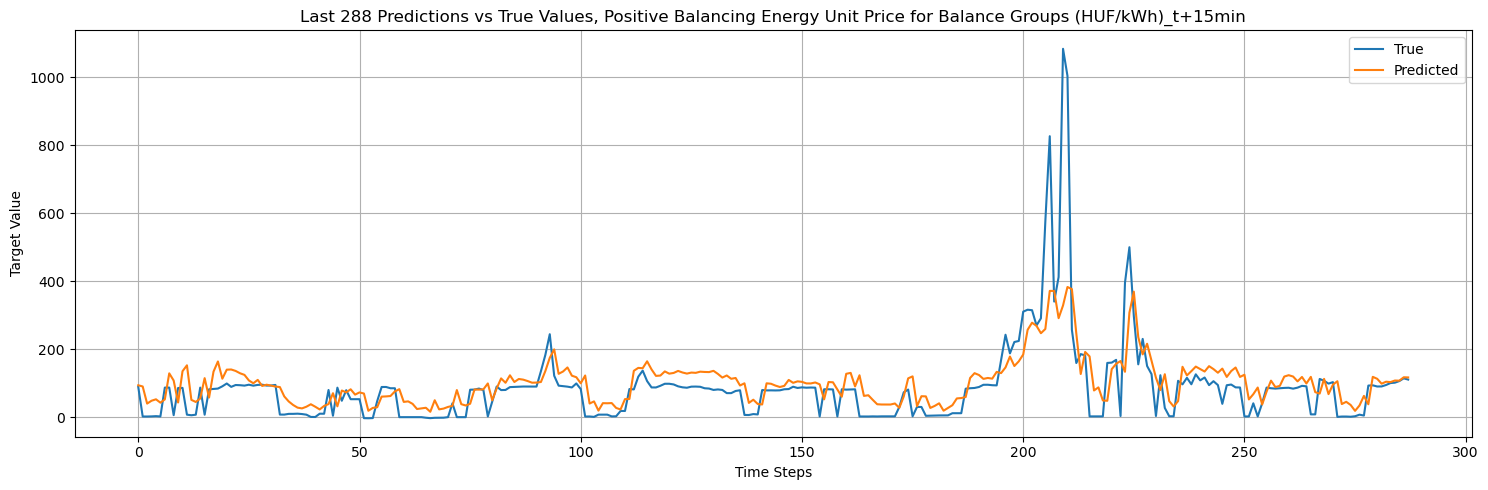

Processing target: System Direction (kWh)_t+15min
RMSE: 15491.1601, MAE: 9919.9716, R²: 0.6805


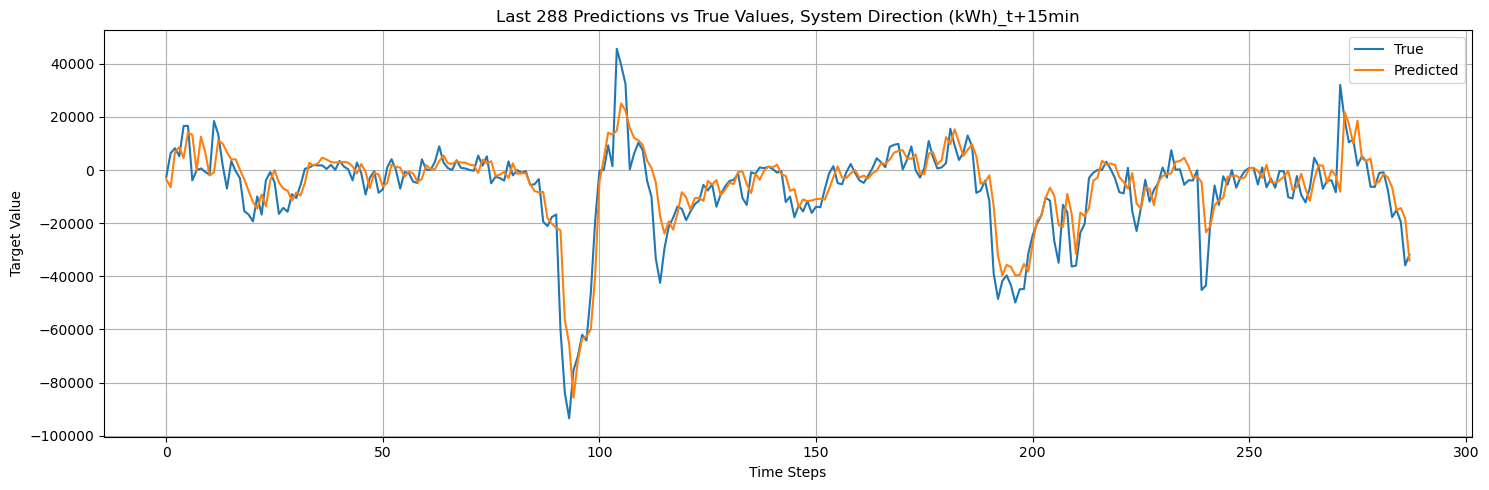

Processing target: Negative Balancing Energy Unit Price for Balance Groups (HUF/kWh)_t+30min
RMSE: 84.2357, MAE: 50.3674, R²: 0.2356


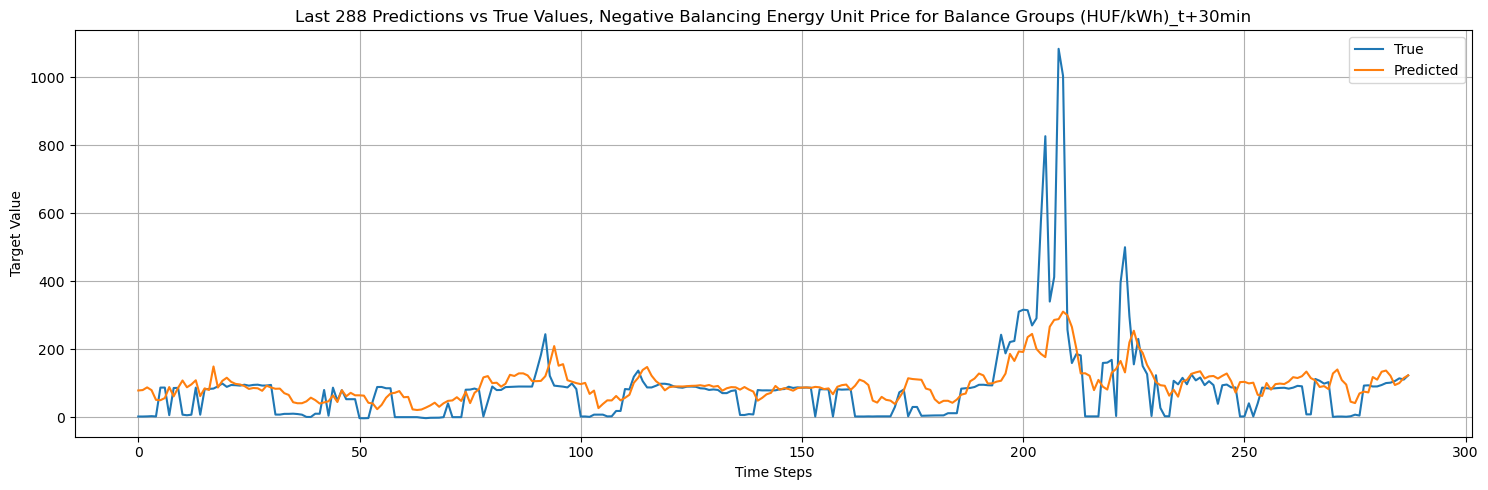

Processing target: Positive Balancing Energy Unit Price for Balance Groups (HUF/kWh)_t+30min
RMSE: 84.1481, MAE: 49.9922, R²: 0.2372


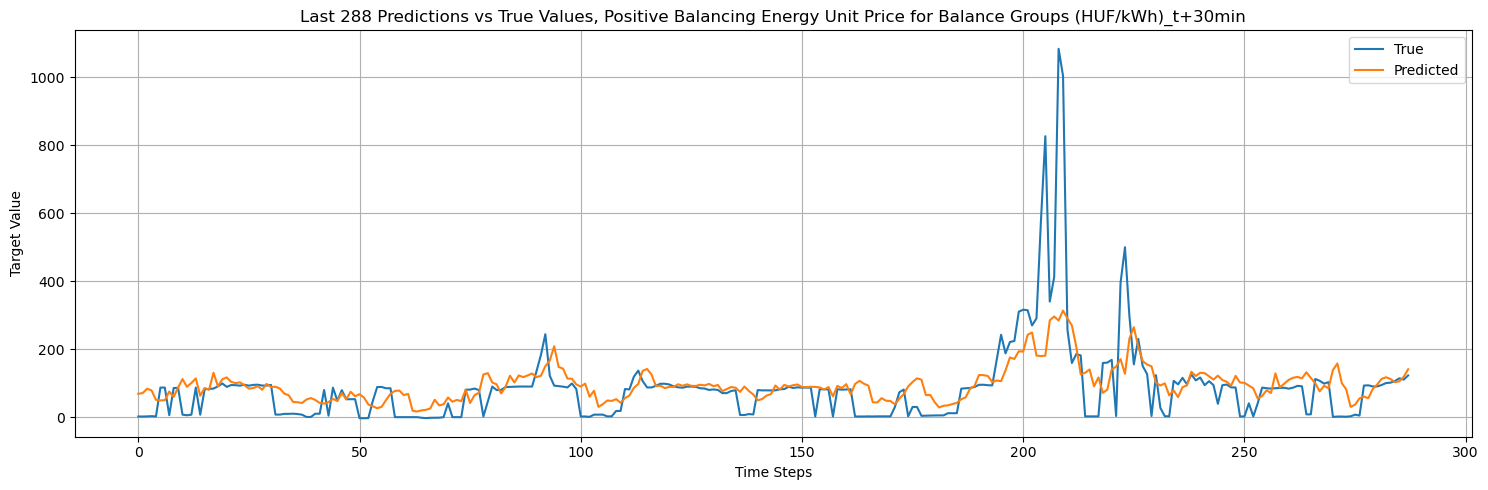

Processing target: System Direction (kWh)_t+30min
RMSE: 18906.8989, MAE: 12202.5281, R²: 0.5239


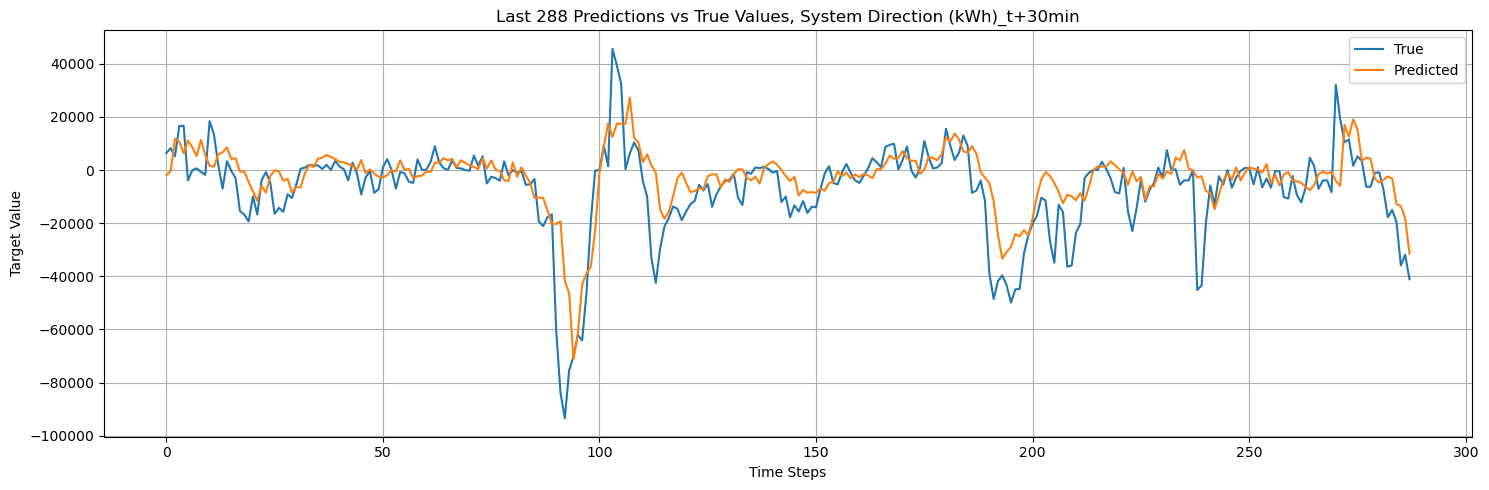

Processing target: Negative Balancing Energy Unit Price for Balance Groups (HUF/kWh)_t+45min
RMSE: 89.1169, MAE: 55.4192, R²: 0.1442


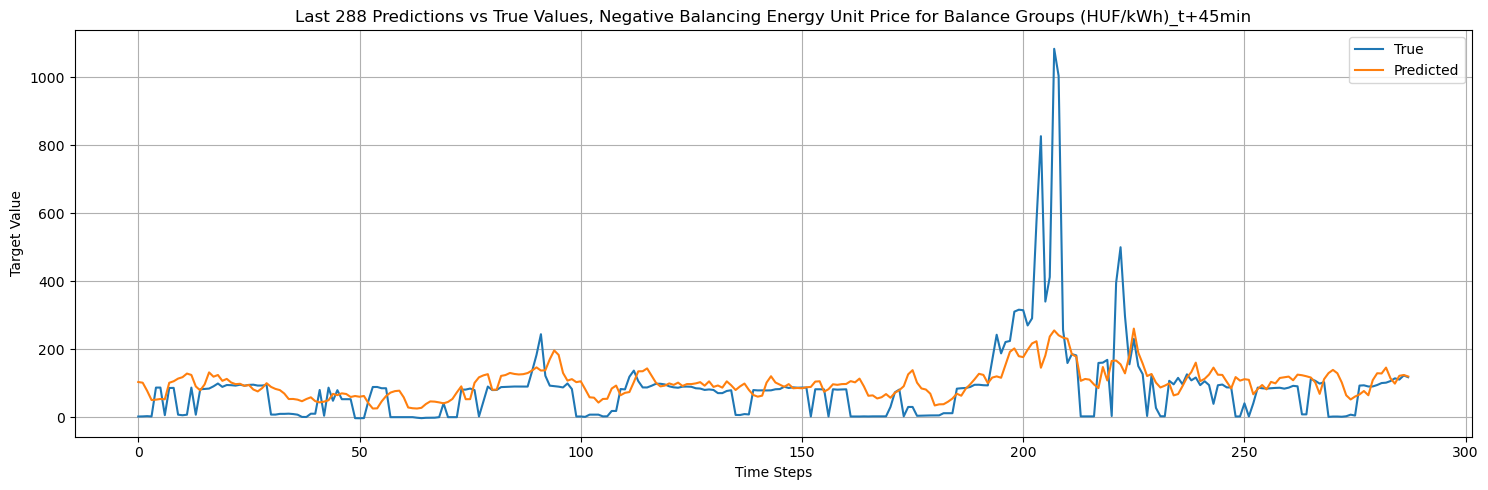

Processing target: Positive Balancing Energy Unit Price for Balance Groups (HUF/kWh)_t+45min
RMSE: 89.5495, MAE: 56.2268, R²: 0.1359


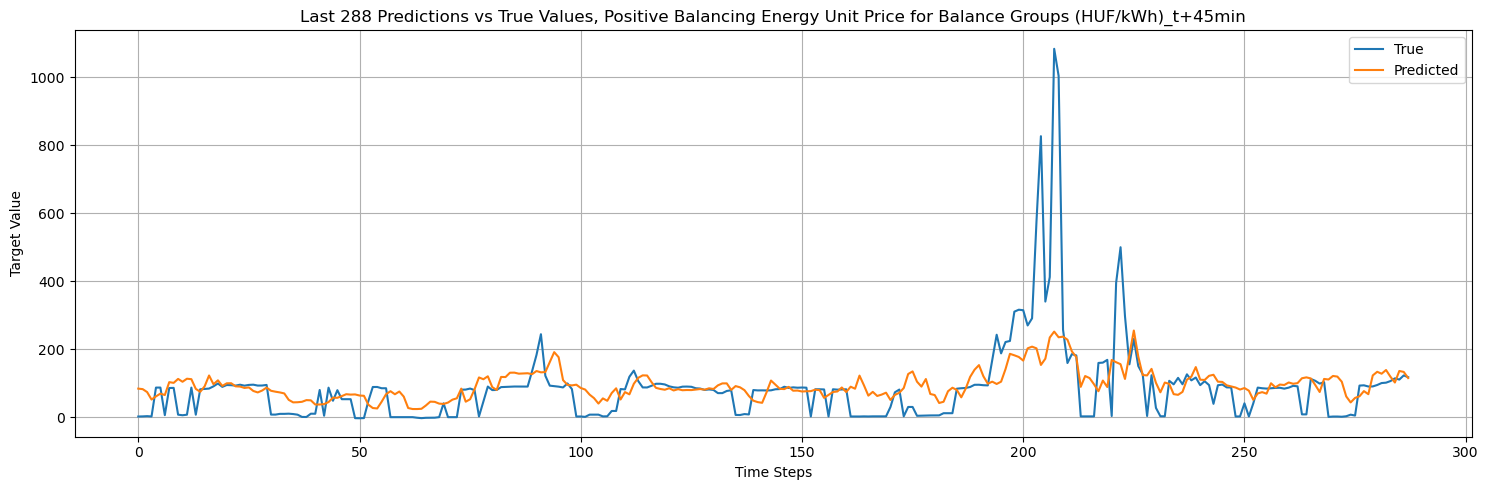

Processing target: System Direction (kWh)_t+45min
RMSE: 20897.1134, MAE: 13275.8626, R²: 0.4183


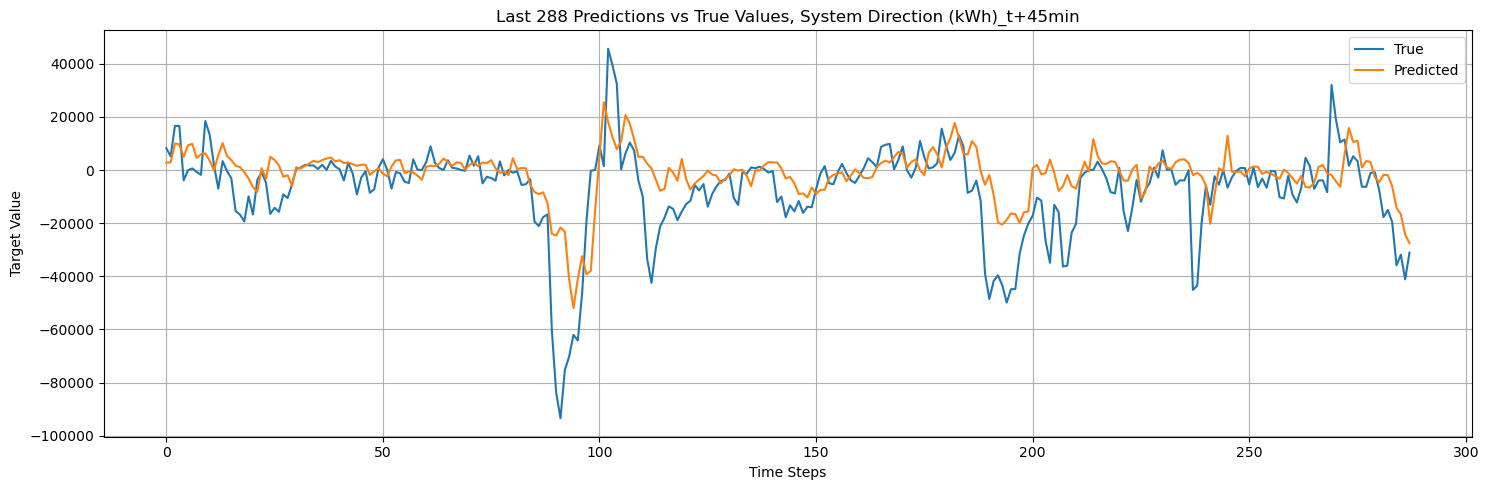

Processing target: Negative Balancing Energy Unit Price for Balance Groups (HUF/kWh)_t+60min
RMSE: 93.9831, MAE: 60.5386, R²: 0.0479


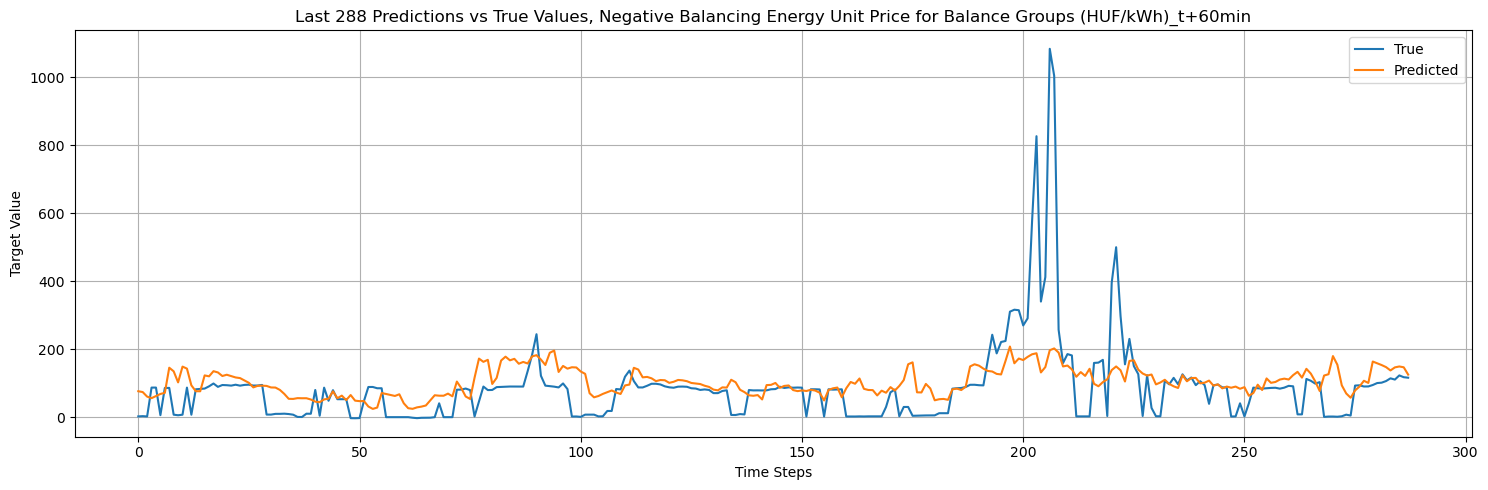

Processing target: Positive Balancing Energy Unit Price for Balance Groups (HUF/kWh)_t+60min
RMSE: 93.0554, MAE: 59.1686, R²: 0.0666


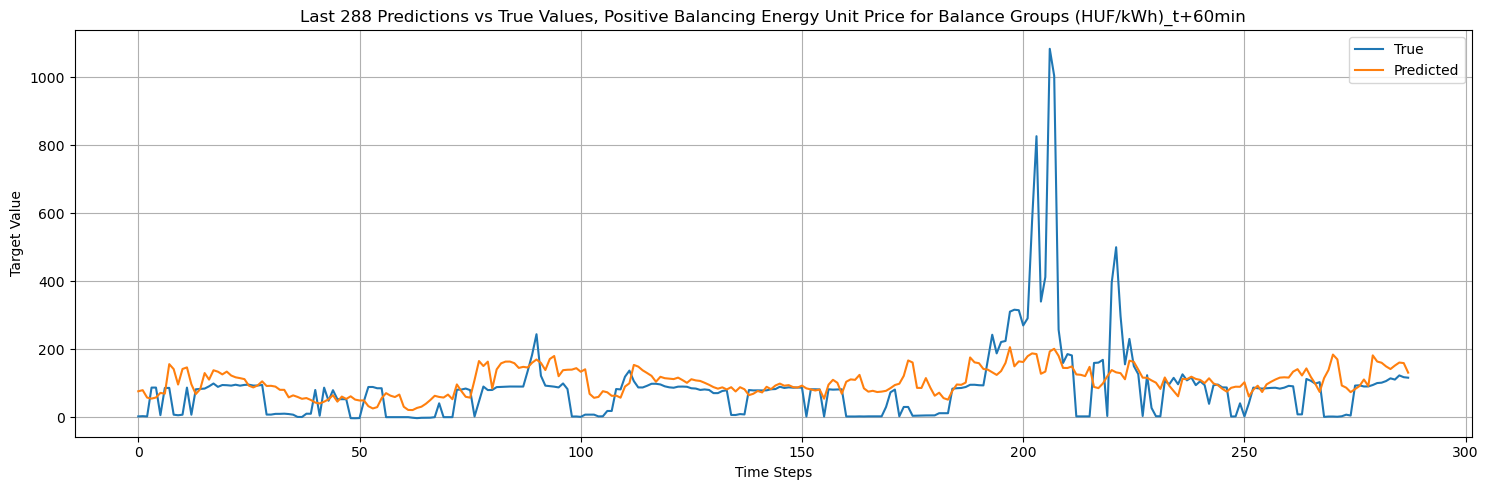

Processing target: System Direction (kWh)_t+60min
RMSE: 22072.6039, MAE: 13857.5629, R²: 0.3508


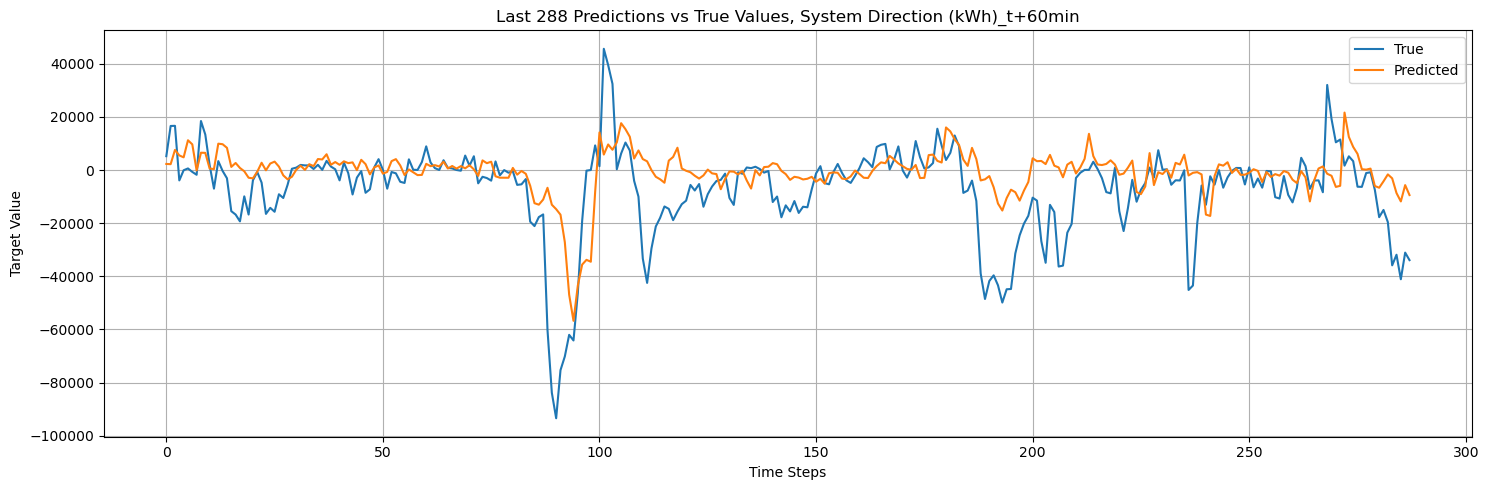

Processing target: Negative Balancing Energy Unit Price for Balance Groups (HUF/kWh)_t+75min
RMSE: 98.5456, MAE: 65.9640, R²: -0.0472


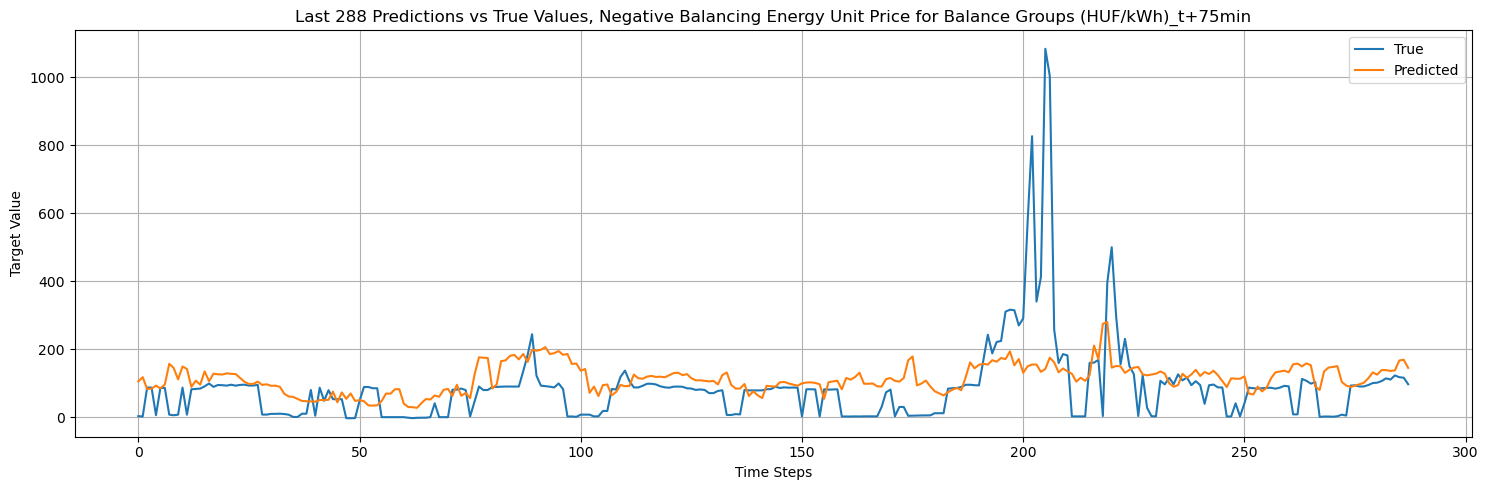

Processing target: Positive Balancing Energy Unit Price for Balance Groups (HUF/kWh)_t+75min
RMSE: 99.0753, MAE: 66.4327, R²: -0.0585


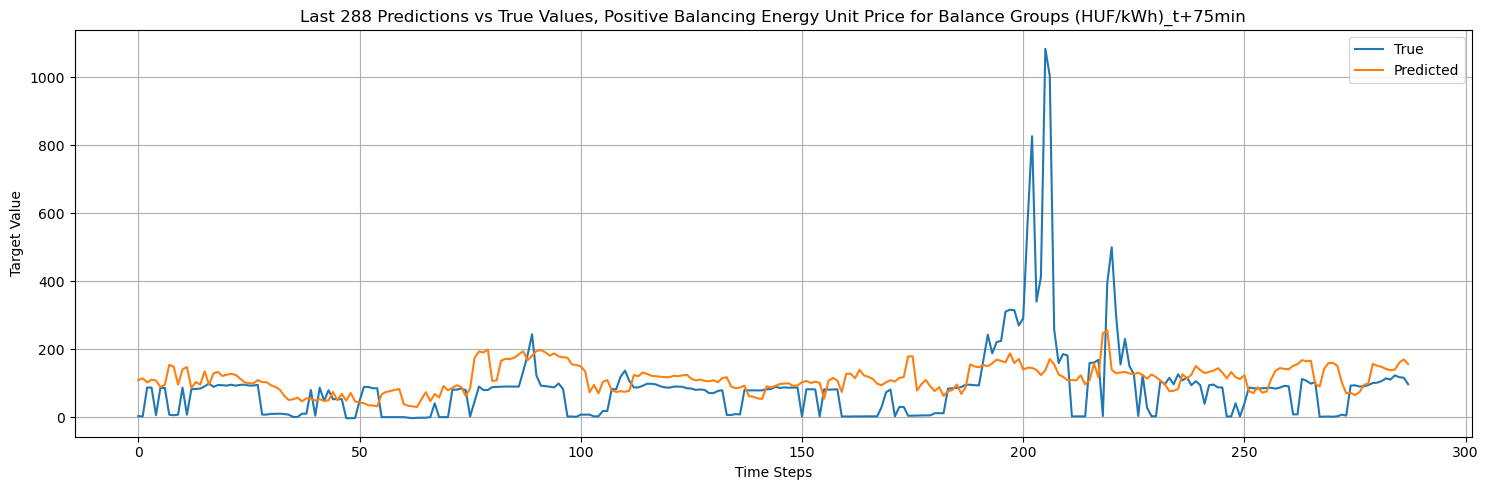

Processing target: System Direction (kWh)_t+75min
RMSE: 23848.6246, MAE: 14870.8710, R²: 0.2420


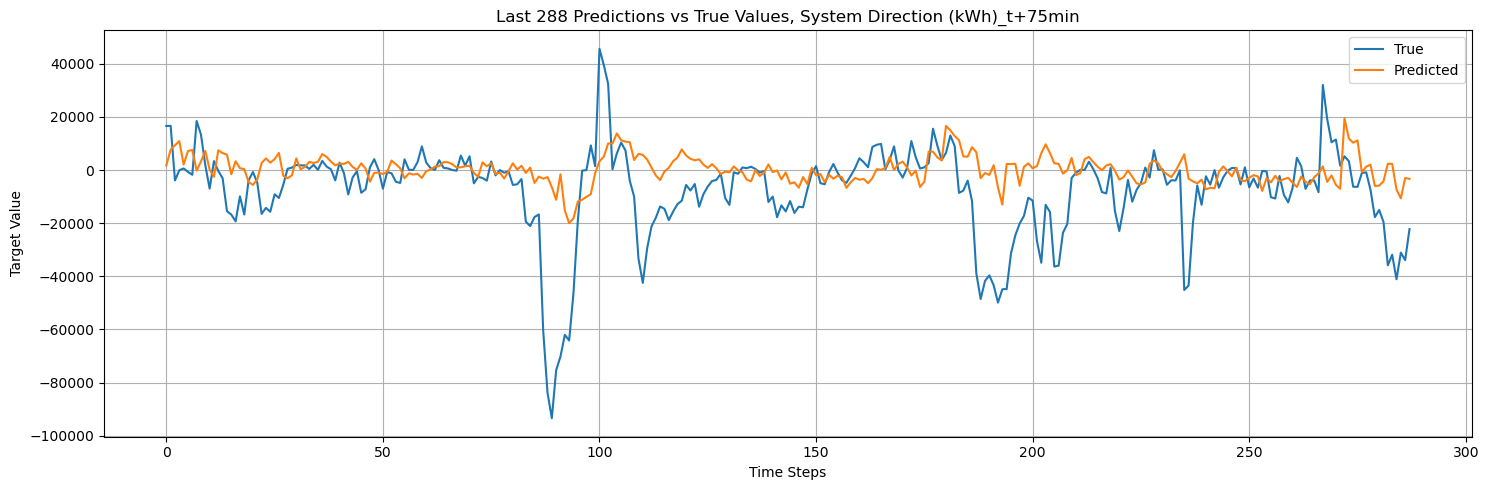

,Target,RMSE,MAE,R²
0,Negative Balancing Energy Unit Price for Balan...,72.723494,38.545646,0.430534
1,Positive Balancing Energy Unit Price for Balan...,72.930452,39.265952,0.427289
2,System Direction (kWh)_t+15min,15491.160070,9919.971644,0.680464
3,Negative Balancing Energy Unit Price for Balan...,84.235696,50.367384,0.235627
4,Positive Balancing Energy Unit Price for Balan...,84.148111,49.992184,0.237216
5,System Direction (kWh)_t+30min,18906.898861,12202.528089,0.523929
6,Negative Balancing Energy Unit Price for Balan...,89.116852,55.419247,0.144225
7,Positive Balancing Energy Unit Price for Balan...,89.549511,56.226847,0.135895
8,System Direction (kWh)_t+45min,20897.113422,13275.862590,0.418282
9,Negative Balancing Energy Unit Price for Balan...,93.983081,60.538607,0.047876


In [ ]:
from preprocess_dataset_for_training import create_training_data
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import pandas as pd
import polars as pl
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt


joined_df = pl.read_parquet("data/joined_df.parquet")
X, y = create_training_data(joined_df)

results = []

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = []
for col in y.columns:
    print(f"Processing target: {col}")
    # Fit XGBoost for each target separately
    model = XGBRegressor(n_estimators=500, learning_rate=0.01, random_state=42, n_jobs=-1, tree_method="approx")
    model.fit(X_train_scaled, y_train[col])

    y_pred = model.predict(X_test_scaled)

    rmse = root_mean_squared_error(y_test[col], y_pred)
    mae = mean_absolute_error(y_test[col], y_pred)
    r2 = r2_score(y_test[col], y_pred)
    print(f"RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

    plt.figure(figsize=(15, 5))
    plt.plot(y_test[col][-288:], label="True")
    plt.plot(y_pred[-288:], label="Predicted")
    plt.title(f"Last 288 Predictions vs True Values, {col}")
    plt.xlabel("Time Steps")
    plt.ylabel("Target Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    results.append({"Target": col, "RMSE": rmse, "MAE": mae, "R²": r2})

results_df = pd.DataFrame(results)
display(results_df)

In [4]:
results_df.to_parquet("xgboost_separate_results.parquet")

In [2]:
results

[{'Target': 'Negative Balancing Energy Unit Price for Balance Groups (HUF/kWh)_t+15min',
  'RMSE': 73.41208645507464,
  'MAE': 38.59843810795707,
  'R²': 0.41969919204711914}]

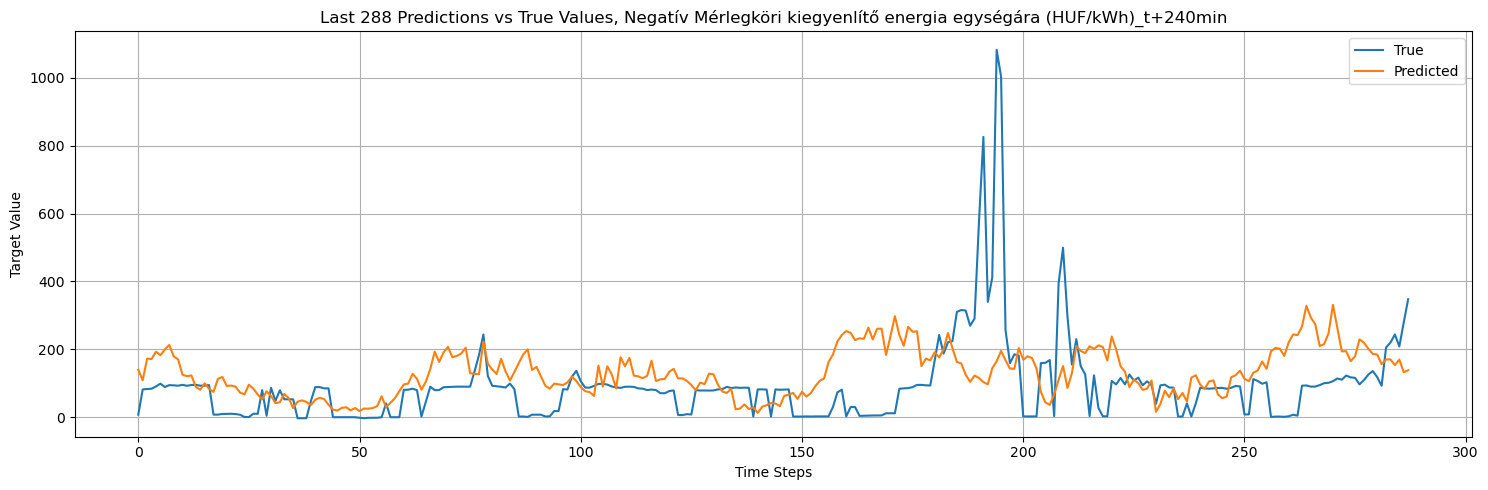

rmse: 121.86551440553109
mae: 88.4709750012389
r2: -0.6015512943267822


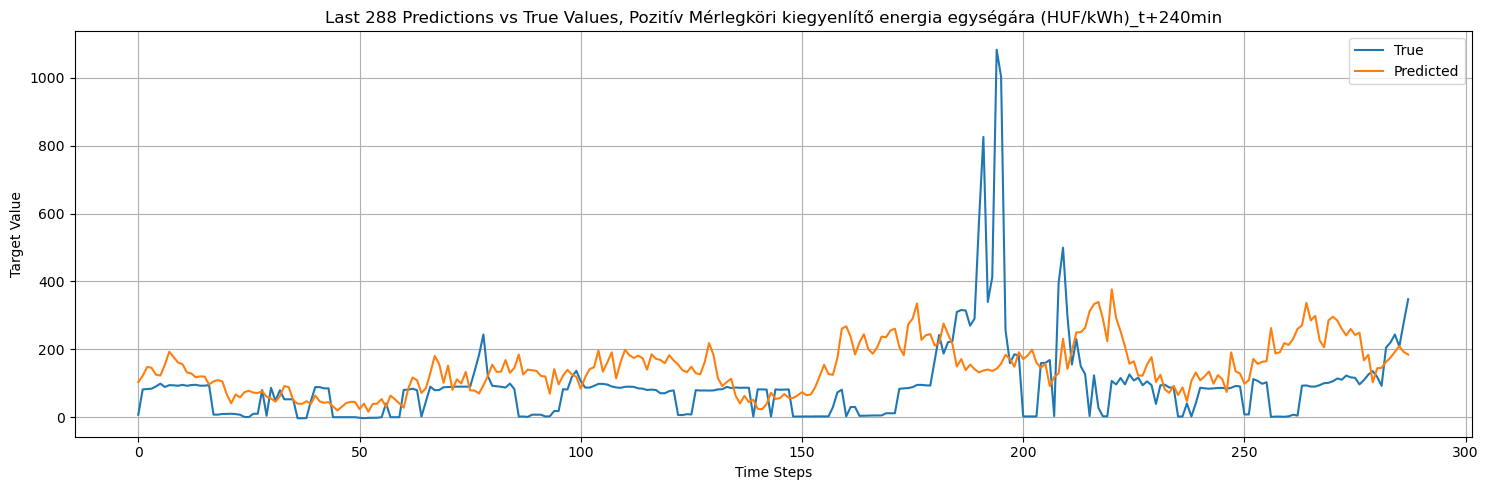

rmse: 124.56681461152553
mae: 91.19751460375792
r2: -0.6733390092849731


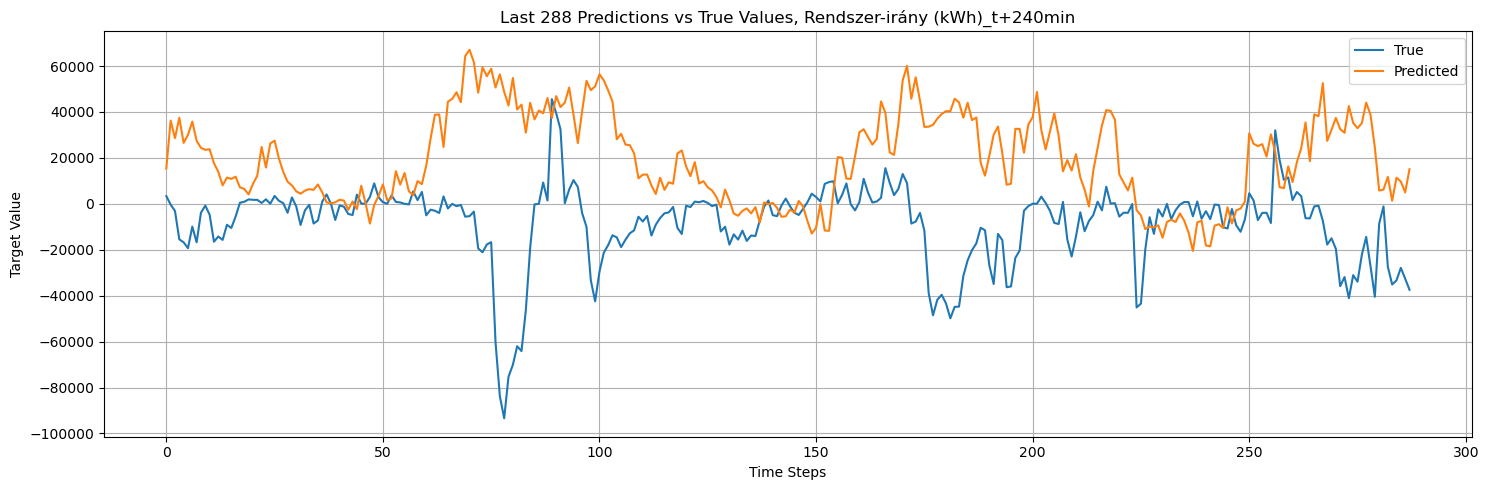

rmse: 28349.627070867267
mae: 18222.743533391742
r2: -0.07236063480377197


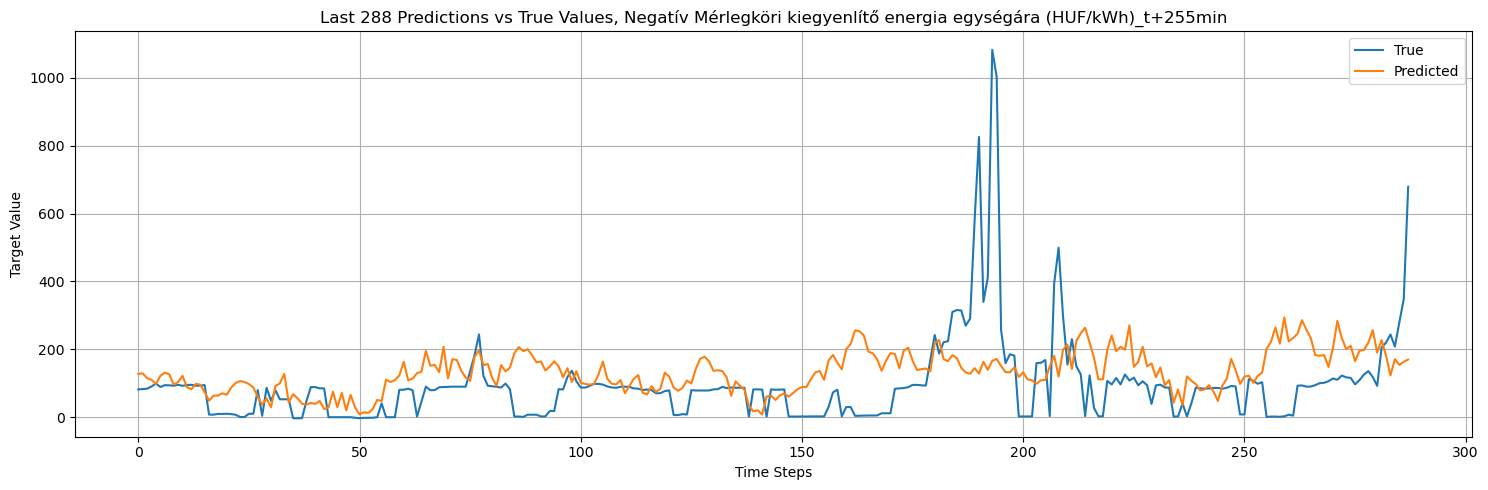

rmse: 126.6375623772649
mae: 93.1337258808241
r2: -0.7276695966720581


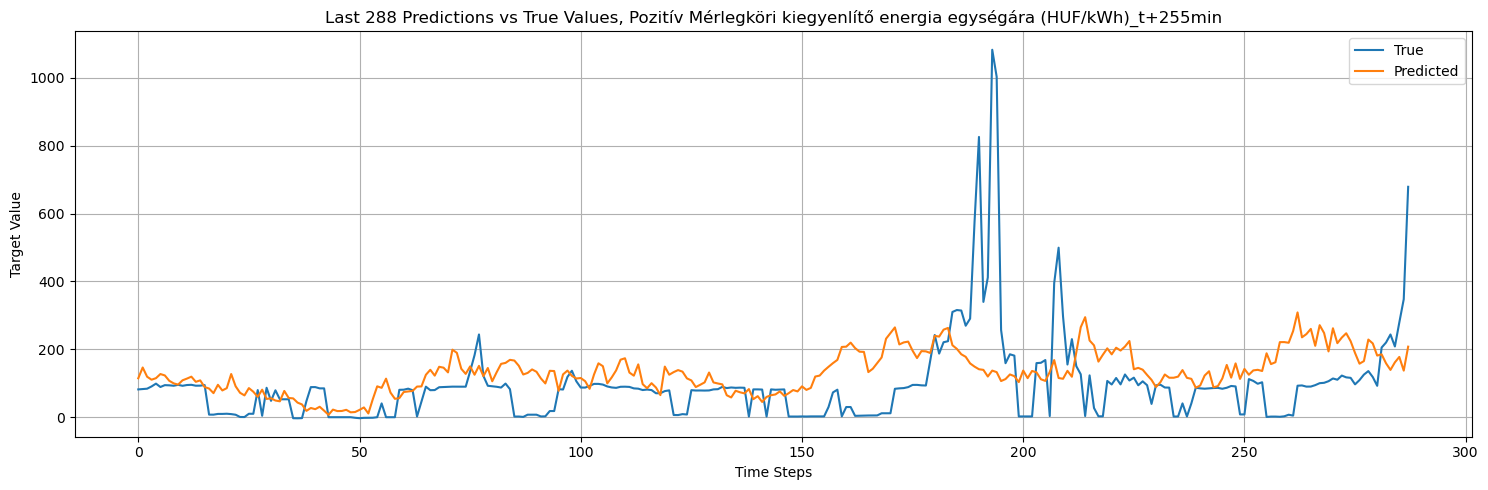

rmse: 125.27547956886738
mae: 91.64358164045754
r2: -0.6907045841217041


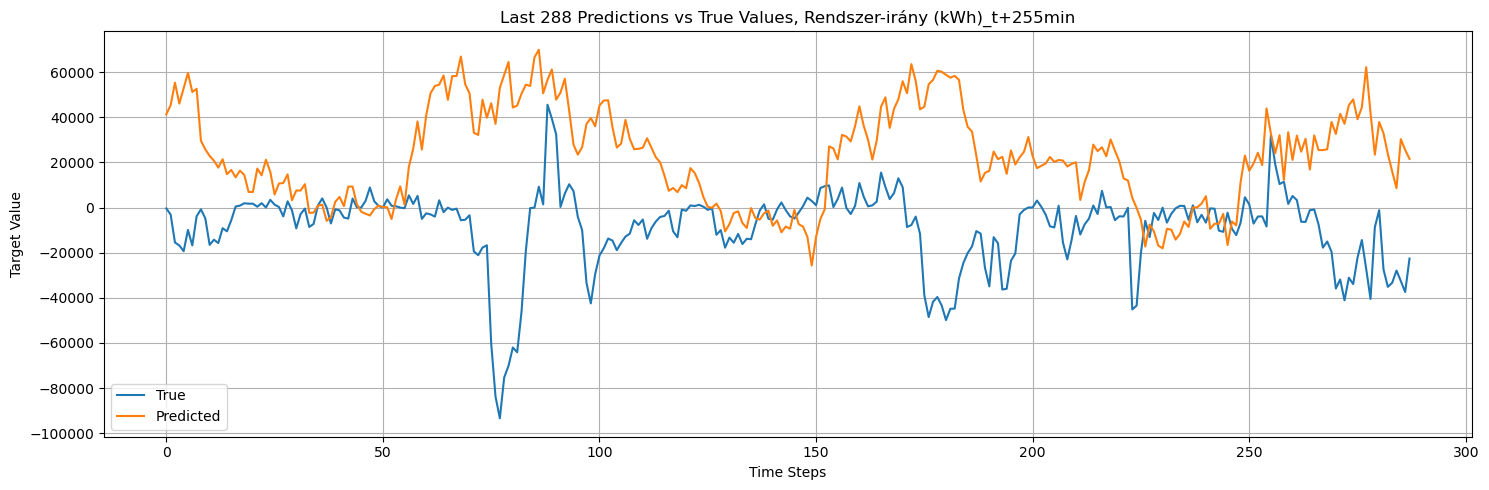

rmse: 28366.774739815464
mae: 18075.575428776378
r2: -0.07378137111663818


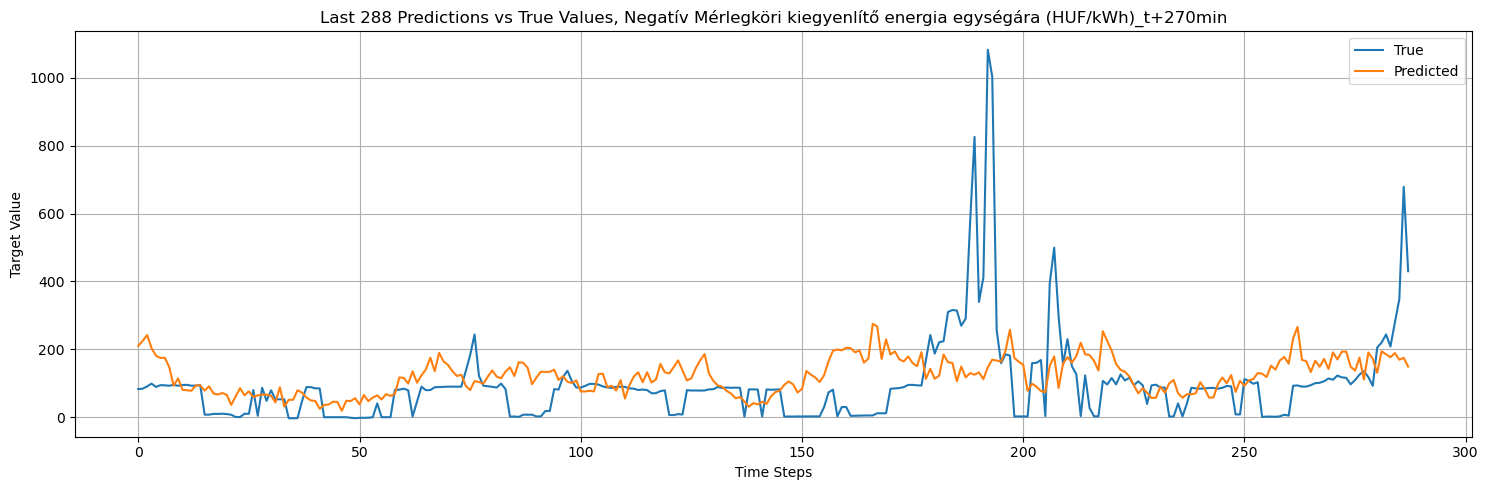

rmse: 123.06000779969351
mae: 89.55645209680658
r2: -0.630834698677063


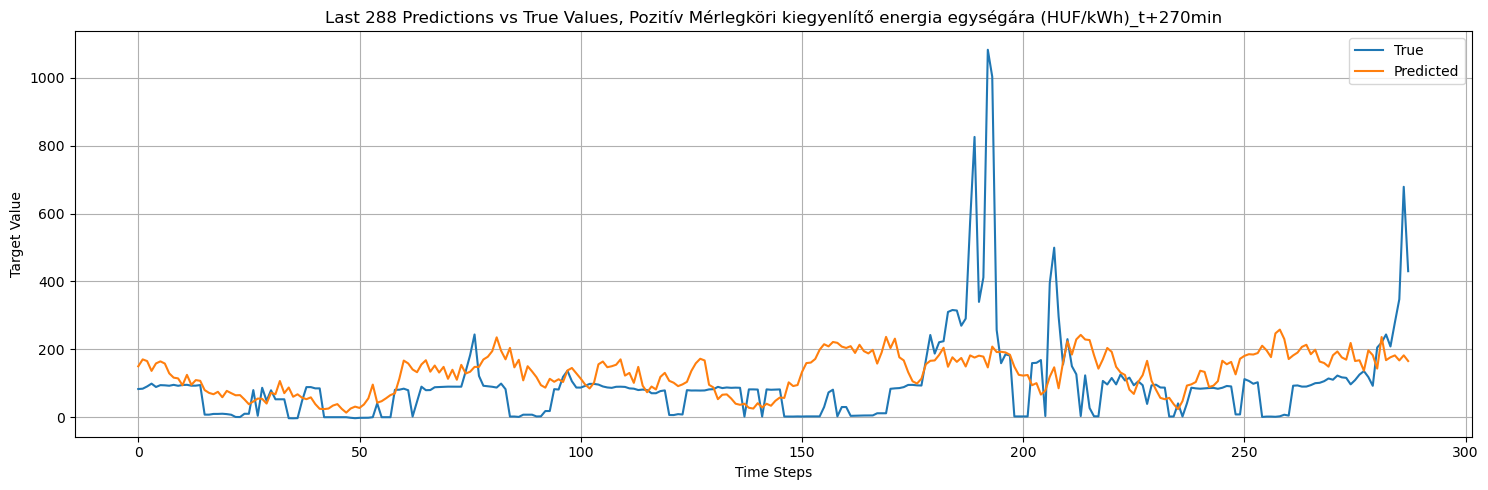

rmse: 122.22041790455329
mae: 88.5242719217638
r2: -0.6086575984954834


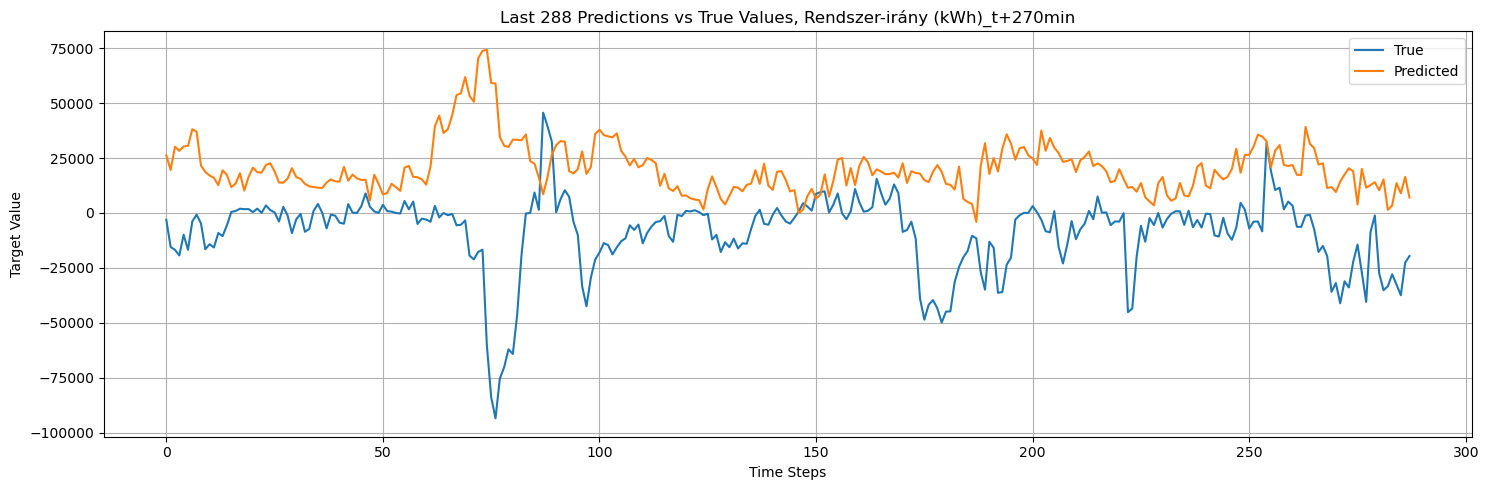

rmse: 28804.749317169862
mae: 18722.30706423548
r2: -0.10724771022796631


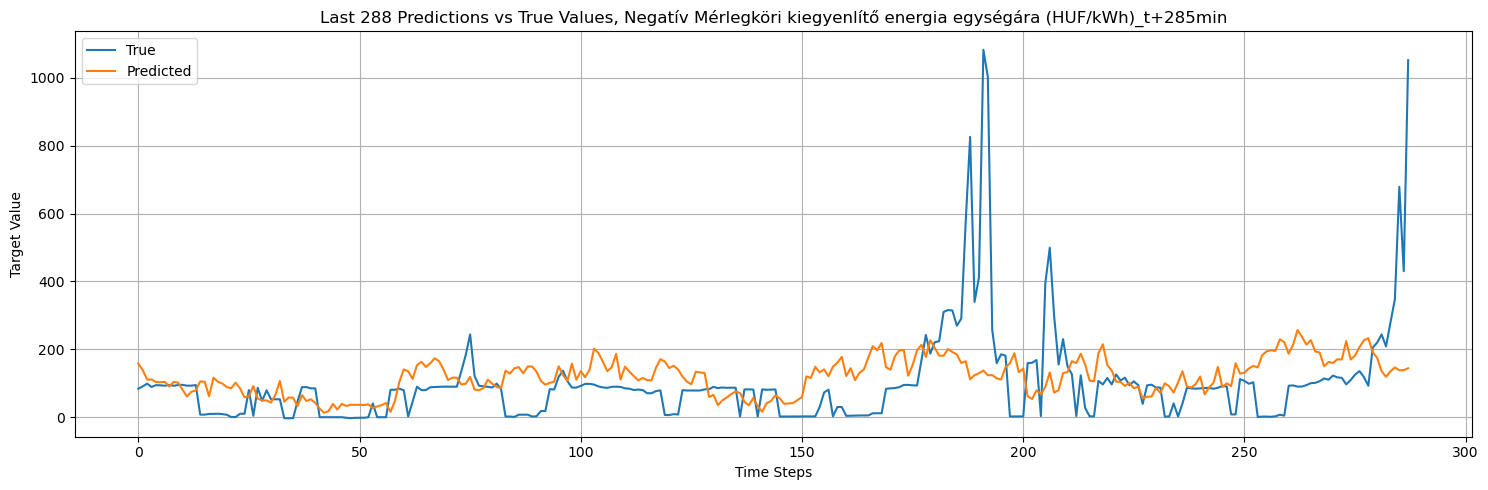

rmse: 125.75335516748723
mae: 91.92885954442131
r2: -0.6985766887664795


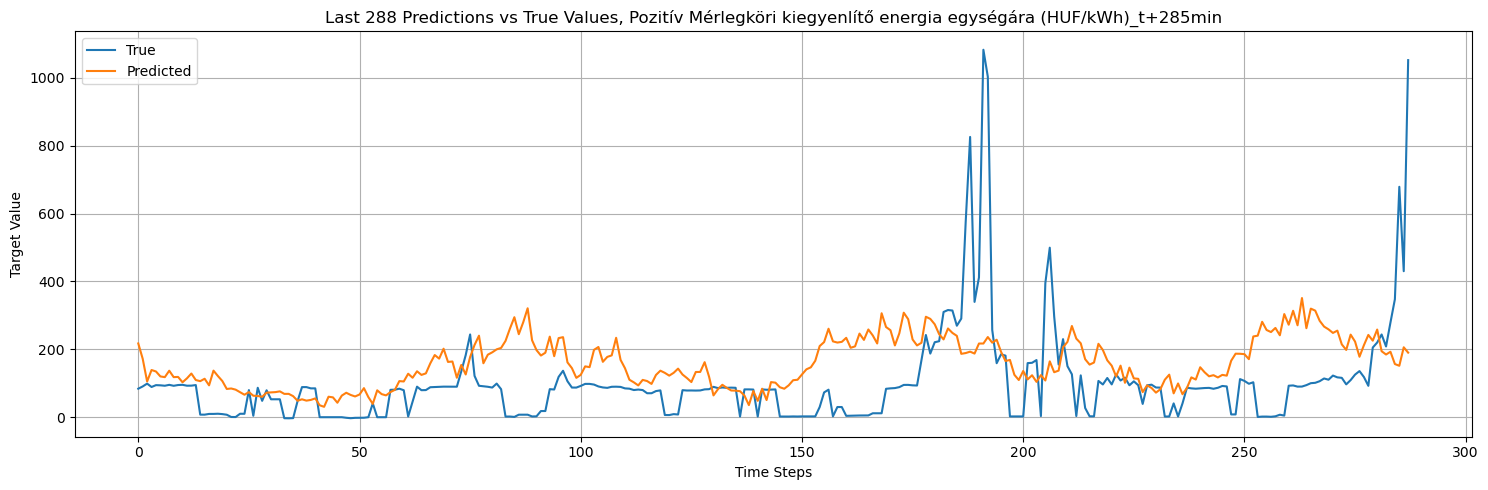

rmse: 125.64403031602257
mae: 91.4204371270147
r2: -0.6956244707107544


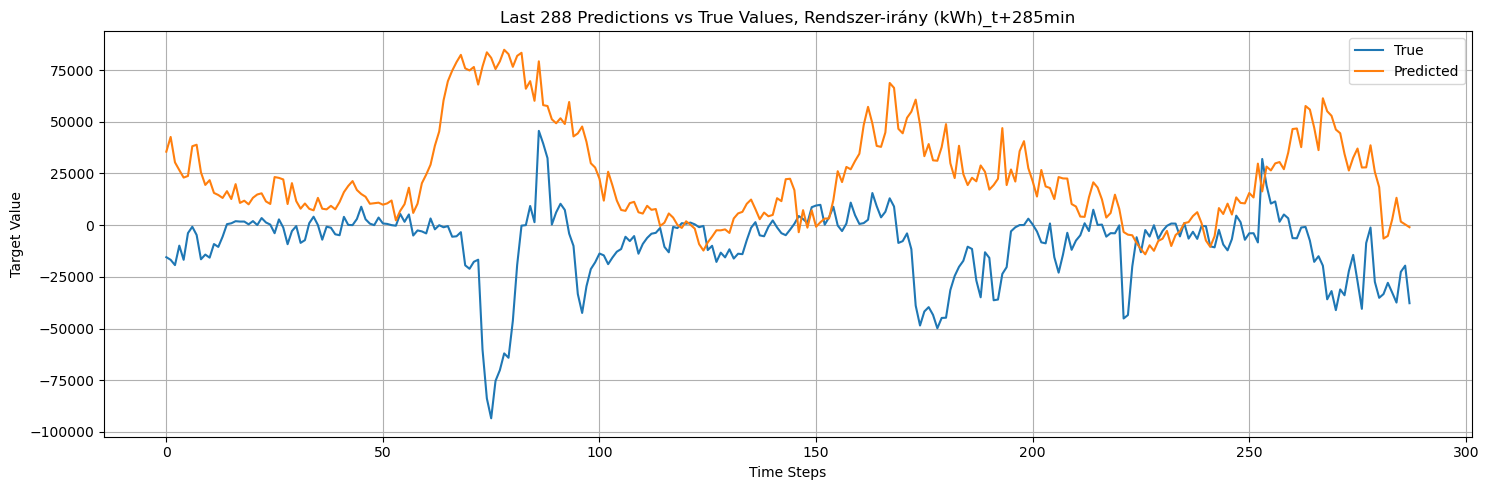

rmse: 28525.43058624973
mae: 18413.75092590219
r2: -0.08582007884979248


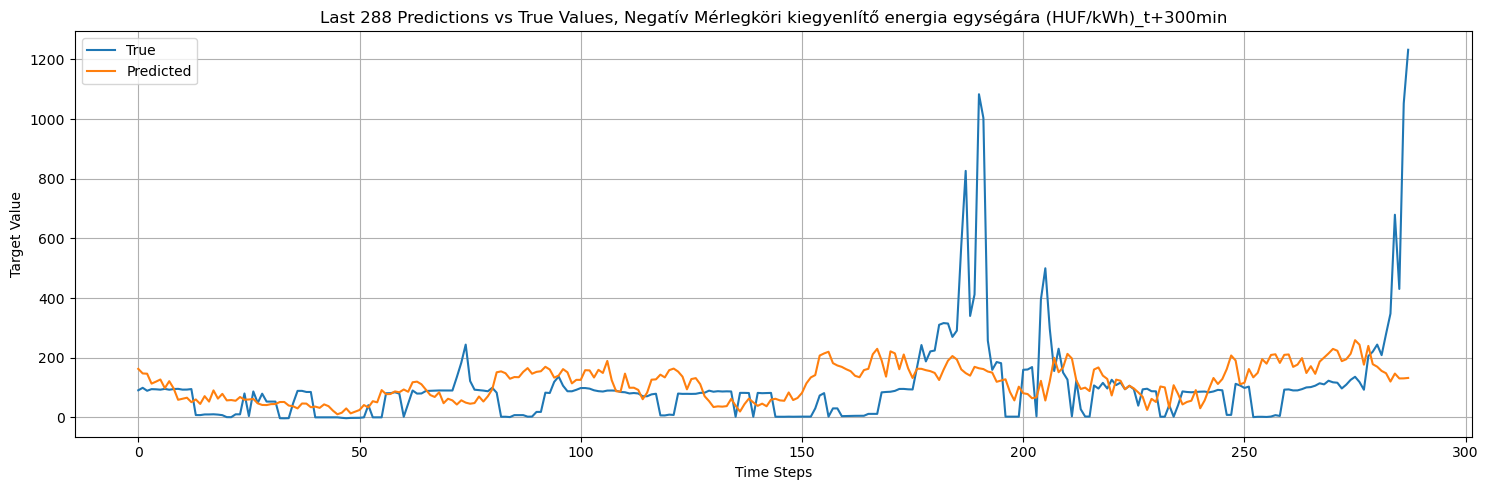

rmse: 121.22987582540087
mae: 86.32333576868898
r2: -0.5728973150253296


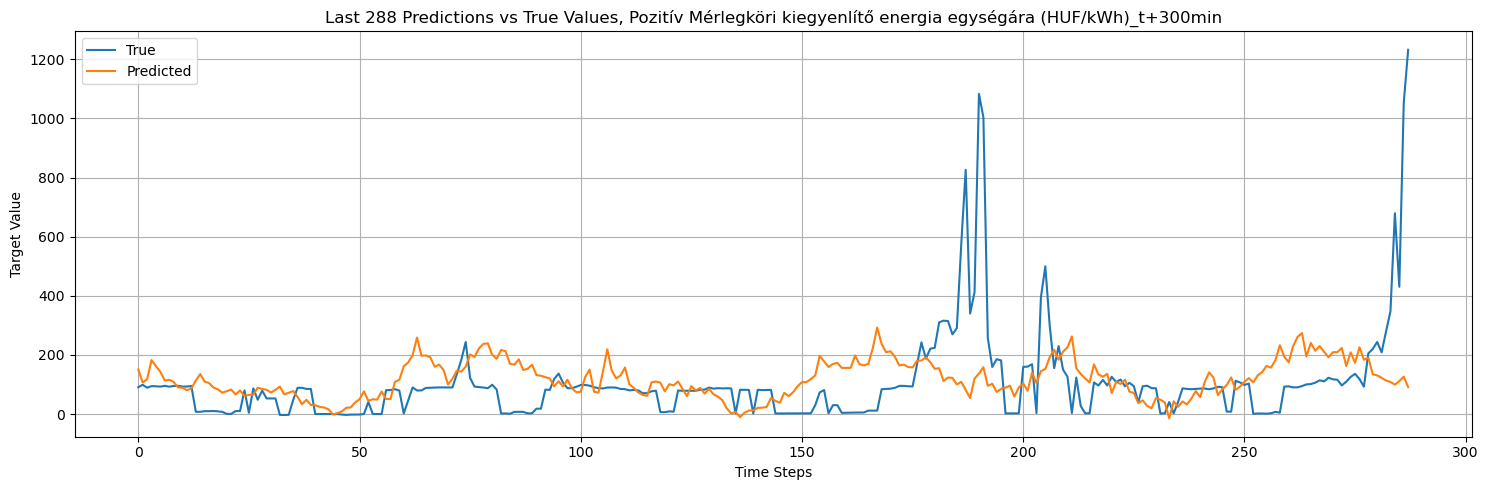

rmse: 120.9358821314458
mae: 86.79488773980293
r2: -0.5652776956558228


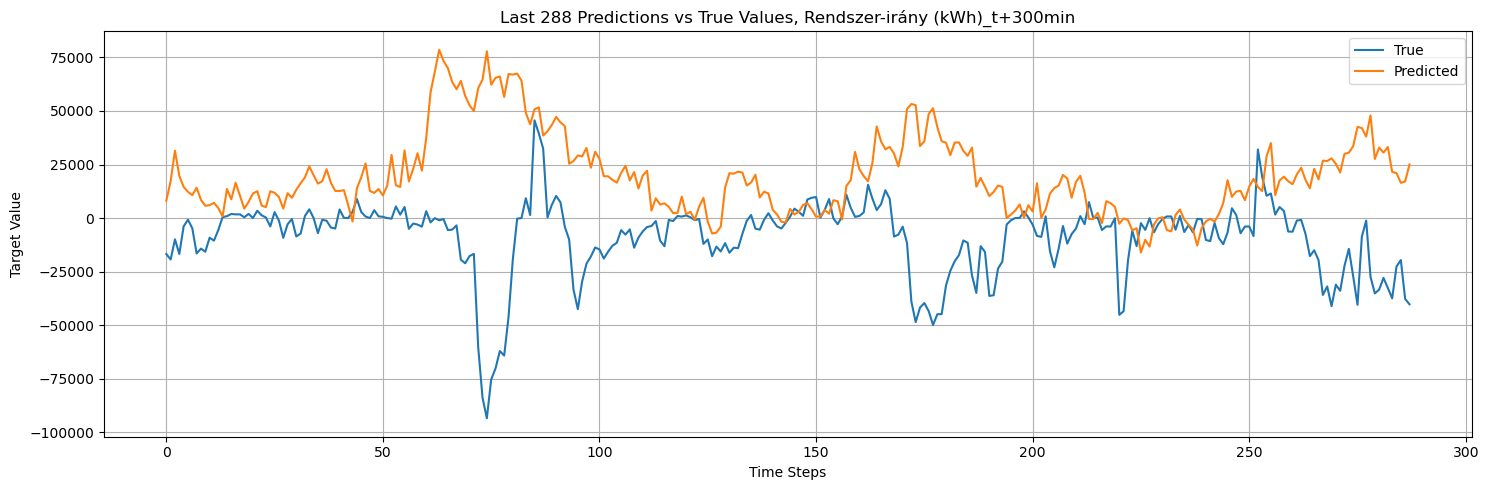

rmse: 29261.36367158573
mae: 19012.595781796237
r2: -0.14249300956726074


,Target,RMSE,MAE,R²
0,Negatív Mérlegköri kiegyenlítő energia egységá...,121.865514,88.470975,-0.601551
1,Pozitív Mérlegköri kiegyenlítő energia egységá...,124.566815,91.197515,-0.673339
2,Rendszer-irány (kWh)_t+240min,28349.627071,18222.743533,-0.072361
3,Negatív Mérlegköri kiegyenlítő energia egységá...,126.637562,93.133726,-0.727670
4,Pozitív Mérlegköri kiegyenlítő energia egységá...,125.275480,91.643582,-0.690705
5,Rendszer-irány (kWh)_t+255min,28366.774740,18075.575429,-0.073781
6,Negatív Mérlegköri kiegyenlítő energia egységá...,123.060008,89.556452,-0.630835
7,Pozitív Mérlegköri kiegyenlítő energia egységá...,122.220418,88.524272,-0.608658
8,Rendszer-irány (kWh)_t+270min,28804.749317,18722.307064,-0.107248
9,Negatív Mérlegköri kiegyenlítő energia egységá...,125.753355,91.928860,-0.698577


In [ ]:
results = []
# Iterate over target columns
for idx, col in enumerate(y_test.columns):
    rmse = root_mean_squared_error(y_test[col], y_pred[:, idx])
    mae = mean_absolute_error(y_test[col], y_pred[:, idx])
    r2 = r2_score(y_test[col], y_pred[:, idx])

    plt.figure(figsize=(15, 5))
    plt.plot(y_test[col][-288:], label="True")
    plt.plot(y_pred[-288:, idx], label="Predicted")
    plt.title(f"Last 288 Predictions vs True Values, {col}")
    plt.xlabel("Time Steps")
    plt.ylabel("Target Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    print("rmse:", rmse)
    print("mae:", mae)
    print("r2:", r2)

    results.append({"Target": col, "RMSE": rmse, "MAE": mae, "R²": r2})

results_df = pd.DataFrame(results)
display(results_df)

In [ ]:
import polars as pl
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error

# Convert to pandas and set index
df = final_df.to_pandas()
df = df.set_index("Időpont")
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["month"] = df.index.month
df["is_weekend"] = (df.index.dayofweek >= 5).astype(int)

from preprocess_dataset_for_training import create_training_data

joined_df = pl.read_parquet("data/joined_df.parquet")
X, y = create_training_data(joined_df)


# Base predictors (originals)
base_predictors = [
    "Naperőművek becsült termelése (aktuális)",
    "Naperőművek becsült termelése (intraday)",
    "Naperőművek becsült termelése (dayahead)",
    "HU-UK",
    "HU-SK",
    "HU-RS",
    "HU-AT",
    "HU-HR",
    "HU-RO",
    "HU-AT menetrend",
    "HU-HR menetrend",
    "HU-SK menetrend",
    "HU-RS menetrend",
    "HU-UK menetrend",
    "HU-RO menetrend",
    "Bruttó terv erőművi termelés",
    "Bruttó tény erőművi termelés",
    "Bruttó hitelesített rendszerterhelés tény",
    "Bruttó rendszerterhelés becslés (dayahead)",
    "Szélerőművek becsült termelése (aktuális)",
    "Szélerőművek becsült termelése (dayahead)",
    "Szélerőművek becsült termelése (intraday)",
]

# Forecast horizons (in minutes)
forecast_steps = [15, 30, 45, 60, 75]

# Define target variable bases
target_bases = [
    "Negatív Mérlegköri kiegyenlítő energia egységára (HUF/kWh)",
    "Pozitív Mérlegköri kiegyenlítő energia egységára (HUF/kWh)",
    "Rendszer-irány (kWh)",
]

# 1. Build full predictor list (originals + all forward lags)
all_predictors = []
for base in base_predictors:
    # Include the original base predictor if present
    if base in df.columns:
        all_predictors.append(base)

    # Include all forward-lagged versions of this predictor
    forward_lagged = [col for col in df.columns if col.startswith(base + "_t+")]
    all_predictors.extend(forward_lagged)

print(all_predictors)

['Naperőművek becsült termelése (aktuális)', 'Naperőművek becsült termelése (aktuális)_t+15min', 'Naperőművek becsült termelése (aktuális)_t+30min', 'Naperőművek becsült termelése (aktuális)_t+45min', 'Naperőművek becsült termelése (aktuális)_t+60min', 'Naperőművek becsült termelése (aktuális)_t+75min', 'Naperőművek becsült termelése (aktuális)_t+90min', 'Naperőművek becsült termelése (aktuális)_t+105min', 'Naperőművek becsült termelése (aktuális)_t+120min', 'Naperőművek becsült termelése (aktuális)_t+135min', 'Naperőművek becsült termelése (aktuális)_t+150min', 'Naperőművek becsült termelése (aktuális)_t+165min', 'Naperőművek becsült termelése (aktuális)_t+180min', 'Naperőművek becsült termelése (aktuális)_t+195min', 'Naperőművek becsült termelése (aktuális)_t+210min', 'Naperőművek becsült termelése (aktuális)_t+225min', 'Naperőművek becsült termelése (aktuális)_t+240min', 'Naperőművek becsült termelése (aktuális)_t+255min', 'Naperőművek becsült termelése (aktuális)_t+270min', 'Naperő

In [9]:
# 2. Build full target list (only forward lags)
target_columns = []
for target_base in target_bases:
    for step in forecast_steps:
        target_col = f"{target_base}_t+{step}min"
        if target_col in df.columns:
            target_columns.append(target_col)
print(target_columns)

['Negatív Mérlegköri kiegyenlítő energia egységára (HUF/kWh)_t+240min', 'Negatív Mérlegköri kiegyenlítő energia egységára (HUF/kWh)_t+255min', 'Negatív Mérlegköri kiegyenlítő energia egységára (HUF/kWh)_t+270min', 'Negatív Mérlegköri kiegyenlítő energia egységára (HUF/kWh)_t+285min', 'Negatív Mérlegköri kiegyenlítő energia egységára (HUF/kWh)_t+300min', 'Pozitív Mérlegköri kiegyenlítő energia egységára (HUF/kWh)_t+240min', 'Pozitív Mérlegköri kiegyenlítő energia egységára (HUF/kWh)_t+255min', 'Pozitív Mérlegköri kiegyenlítő energia egységára (HUF/kWh)_t+270min', 'Pozitív Mérlegköri kiegyenlítő energia egységára (HUF/kWh)_t+285min', 'Pozitív Mérlegköri kiegyenlítő energia egységára (HUF/kWh)_t+300min', 'Rendszer-irány (kWh)_t+240min', 'Rendszer-irány (kWh)_t+255min', 'Rendszer-irány (kWh)_t+270min', 'Rendszer-irány (kWh)_t+285min', 'Rendszer-irány (kWh)_t+300min']


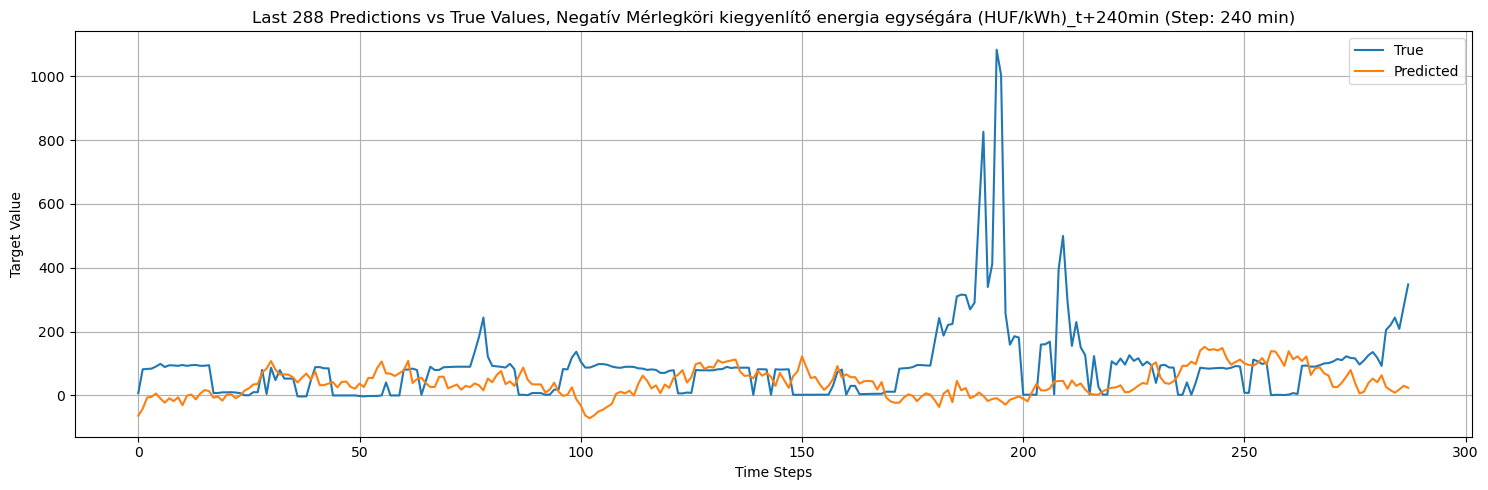

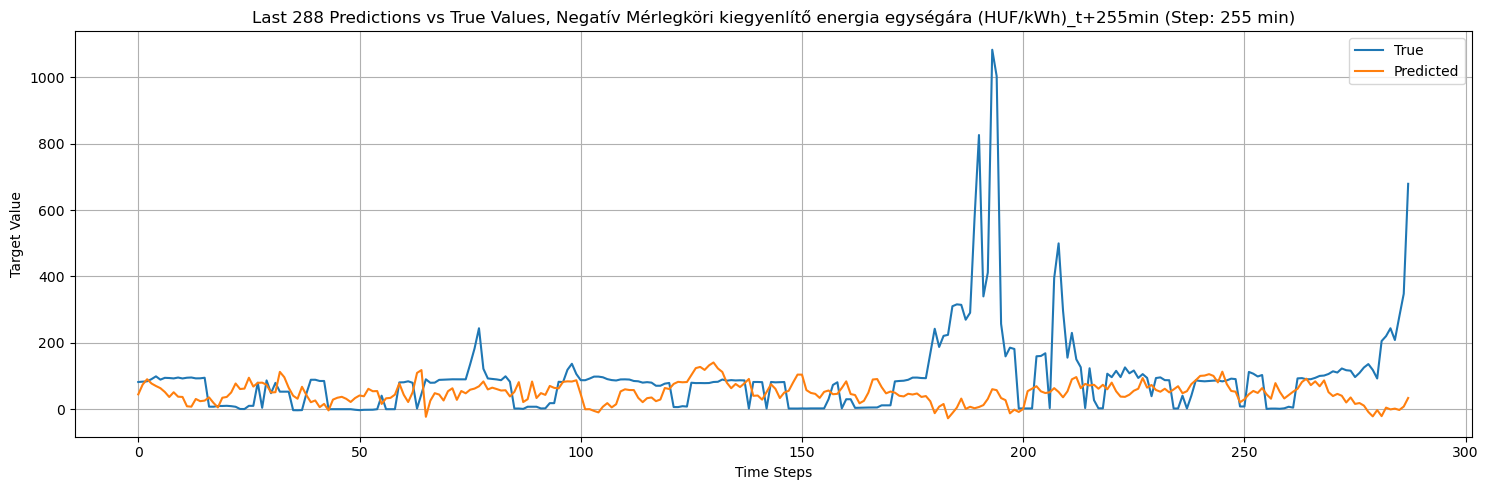

Exception ignored on calling ctypes callback function: <bound method DataIter._next_wrapper of <xgboost.data.SingleBatchInternalIter object at 0x00000229B82D5CD0>>
Traceback (most recent call last):
  File "c:\Users\marti\anaconda3\Lib\site-packages\xgboost\core.py", line 585, in _next_wrapper
    def _next_wrapper(self, this: None) -> int:  # pylint: disable=unused-argument

KeyboardInterrupt: 


: 

: 

In [ ]:
# 3. Train models
results = []
import matplotlib.pyplot as plt

for target_col in target_columns:
    # Drop NaNs
    data = df[all_predictors + [target_col]].dropna()
    if data.shape[0] < 100:
        continue

    X = data[all_predictors]
    y = data[target_col]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    # Scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Fit XGBoost
    model = XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_test_scaled)

    # Evaluate
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Extract step in minutes
    step = int(target_col.split("_t+")[1].replace("min", ""))
    # Plot last 288 points
    plt.figure(figsize=(15, 5))
    plt.plot(y_test[-288:].values, label="True")
    plt.plot(y_pred[-288:], label="Predicted")
    plt.title(f"Last 288 Predictions vs True Values, {target_col} (Step: {step} min)")
    plt.xlabel("Time Steps")
    plt.ylabel("Target Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    results.append({"Target": target_col.split("_t+")[0], "Step (min)": step, "RMSE": rmse, "MAE": mae, "R²": r2})

# Display
results_df = pd.DataFrame(results)
display(results_df.sort_values(["Target", "Step (min)"]))

c:\Users\marti\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1315/1315 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


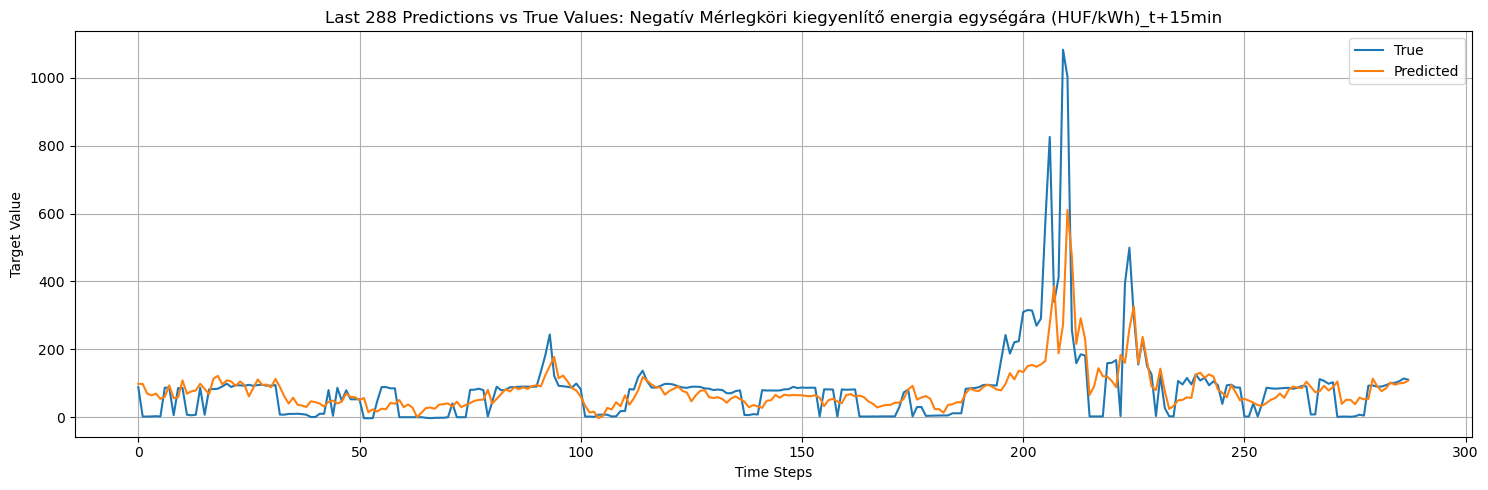

c:\Users\marti\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


KeyboardInterrupt: 

In [ ]:
from preprocess_dataset_for_training import create_training_data
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Load data and create training sets
joined_df = pl.read_parquet("data/joined_df.parquet")
X, y = create_training_data(joined_df)  # X: all predictors, y: all targets

results = []
# Iterate over each target column in y
for col in y.columns:
    # Split data for current target
    X_train, X_test, y_train, y_test = train_test_split(X, y[col], test_size=0.2, shuffle=False)

    # Scale predictors
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Define the neural network model
    model = Sequential(
        [
            Dense(256, activation="relu", input_shape=(X_train_scaled.shape[1],)),
            Dropout(0.3),
            Dense(256, activation="relu"),
            Dropout(0.2),
            Dense(1),
        ]
    )
    model.compile(optimizer="adam", loss="mse", metrics=[tf.keras.metrics.RootMeanSquaredError()])

    # Train the model
    model.fit(X_train_scaled, y_train, epochs=20, batch_size=32, verbose=0)

    # Predict and evaluate
    y_pred = model.predict(X_test_scaled).flatten()
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Plot last 288 observations for visual evaluation
    plt.figure(figsize=(15, 5))
    plt.plot(y_test[-288:], label="True")
    plt.plot(y_pred[-288:], label="Predicted")
    plt.title(f"Last 288 Predictions vs True Values: {col}")
    plt.xlabel("Time Steps")
    plt.ylabel("Target Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    results.append({"Target": col, "RMSE": rmse, "MAE": mae, "R²": r2})

# Display results
results_df = pd.DataFrame(results)
display(results_df.sort_values("Target"))

In [ ]:
print("rmse:", rmse)
print("mae:", mae)
print("r2:", r2)

rmse: 71.53081863411428
mae: 39.076947907414926
r2: 0.44905978441238403


In [42]:
import altair as alt


def lag_chart(df, colors=["red", "green"], width=800, height=400):
    # Base encodings
    base = alt.Chart(df).encode(
        x=alt.X("lag:T", axis=alt.Axis(title="Lag", labelAngle=0, labelFontSize=14, titleFontSize=14, tickCount=4, format="%H:%M")),
        y=alt.Y("error:Q", axis=alt.Axis(title="Error", labelFontSize=14, titleFontSize=14)),
        color=alt.Color("Target:N", scale=alt.Scale(range=colors)).legend(
            orient="bottom", direction="vertical", labelFontSize=13, titleFontSize=13, labelLimit=600
        ),
        strokeDash=alt.StrokeDash("error measure:N").legend(orient="bottom", labelFontSize=13, titleFontSize=13),
    )

    # Line chart
    line = base.mark_line(size=2)

    # Point markers
    points = base.mark_point(size=50, filled=False)

    # Combine
    return (points + line).properties(width=800, height=300)

c:\Users\marti\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
4734/4734 ━━━━━━━━━━━━━━━━━━━━ 88s 17ms/step - loss: 151718480.0000 - root_mean_squared_error: 12258.3799 - val_loss: 141658400.0000 - val_root_mean_squared_error: 11902.0332
Epoch 2/20
4734/4734 ━━━━━━━━━━━━━━━━━━━━ 67s 14ms/step - loss: 97876688.0000 - root_mean_squared_error: 9893.1182 - val_loss: 133710584.0000 - val_root_mean_squared_error: 11563.3291
Epoch 3/20
4734/4734 ━━━━━━━━━━━━━━━━━━━━ 71s 15ms/step - loss: 93062096.0000 - root_mean_squared_error: 9646.6660 - val_loss: 131677448.0000 - val_root_mean_squared_error: 11475.0791
Epoch 4/20
4734/4734 ━━━━━━━━━━━━━━━━━━━━ 52s 11ms/step - loss: 90002304.0000 - root_mean_squared_error: 9486.8447 - val_loss: 129839520.0000 - val_root_mean_squared_error: 11394.7148
Epoch 5/20
4734/4734 ━━━━━━━━━━━━━━━━━━━━ 59s 12ms/step - loss: 88077824.0000 - root_mean_squared_error: 9384.7930 - val_loss: 129408808.0000 - val_root_mean_squared_error: 11375.7988
Epoch 6/20
4734/4734 ━━━━━━━━━━━━━━━━━━━━ 58s 12ms/step - loss: 86229544.0000 

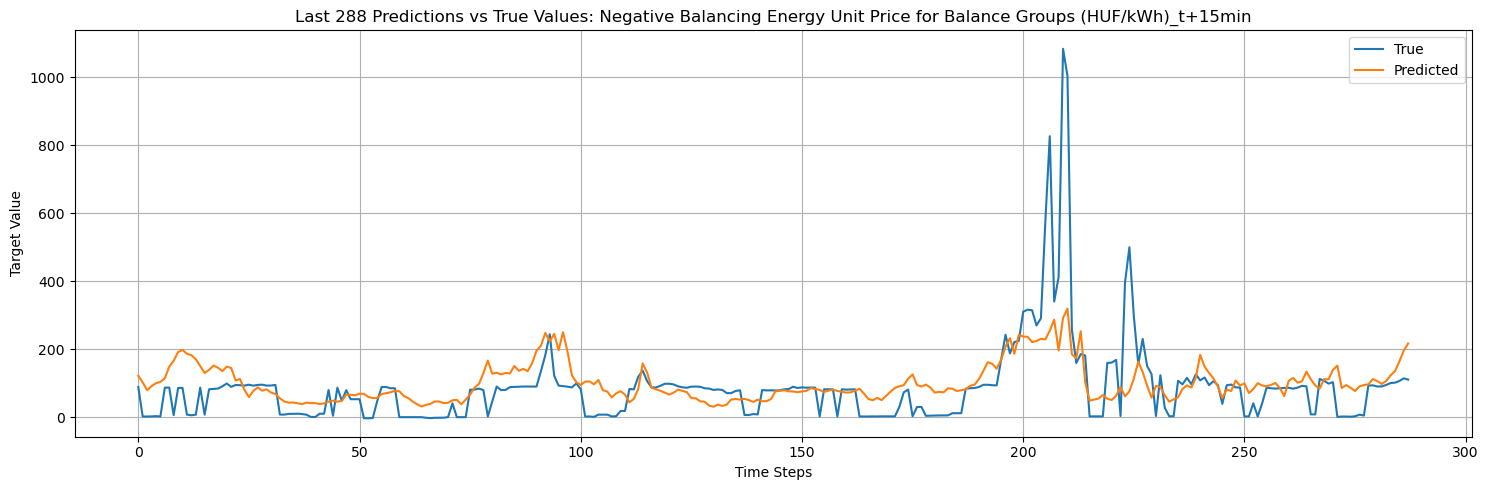

rmse: 87.29688957328797
mae: 59.90925141649833
r2: 0.1794300675392151


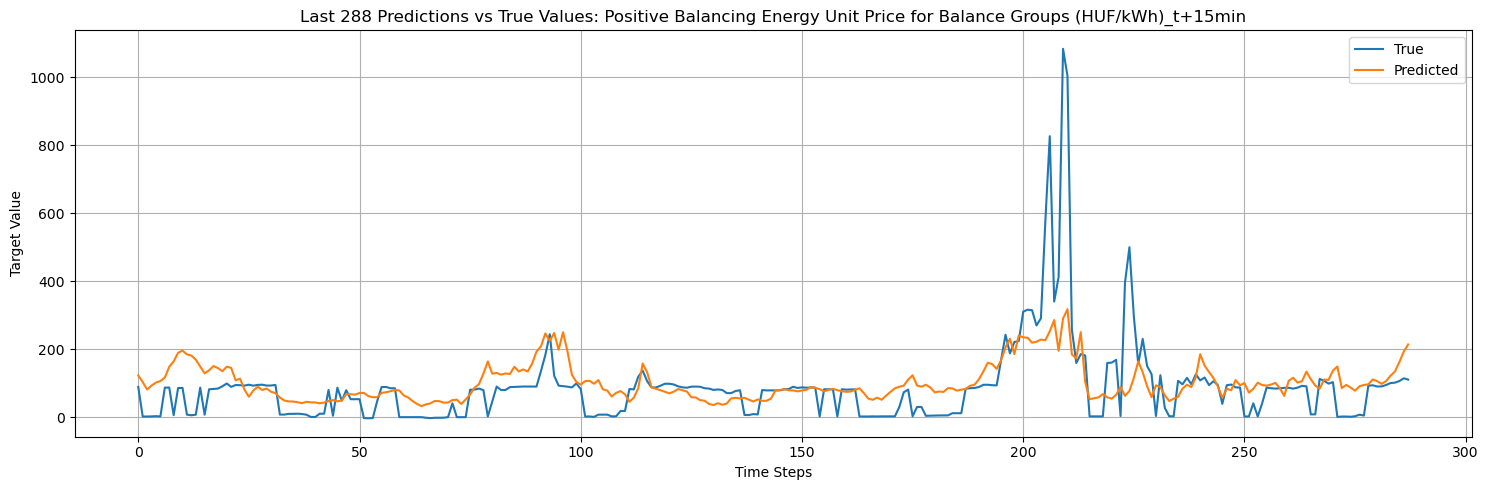

rmse: 87.74560661331847
mae: 60.88564275213685
r2: 0.17097264528274536


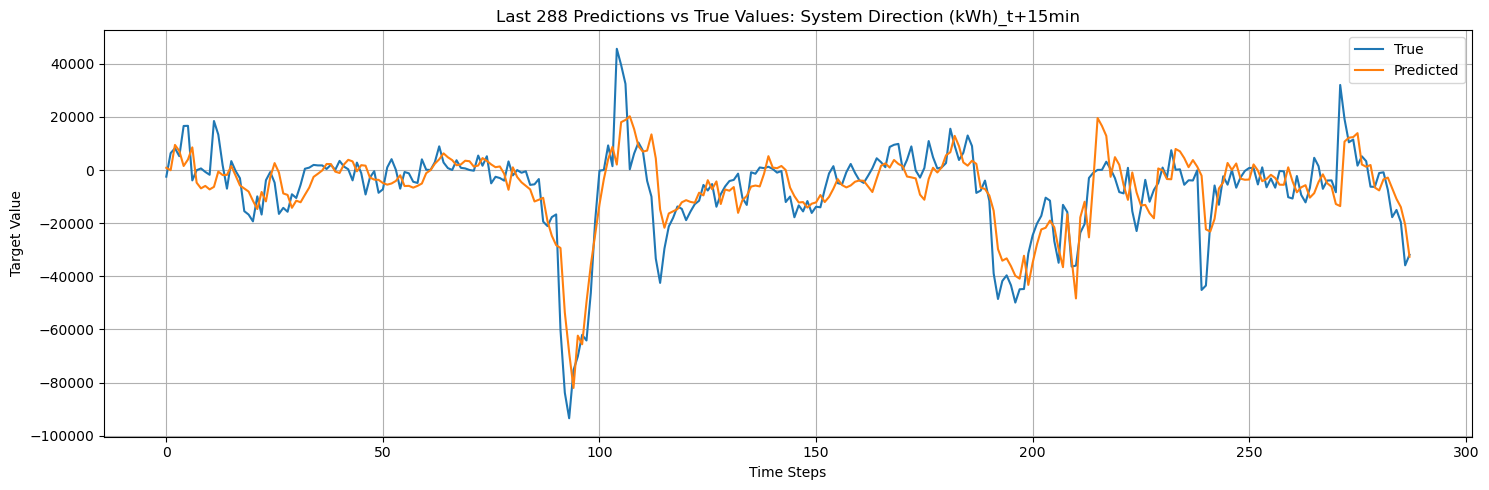

rmse: 16110.399780758527
mae: 11055.585666186202
r2: 0.6544070243835449


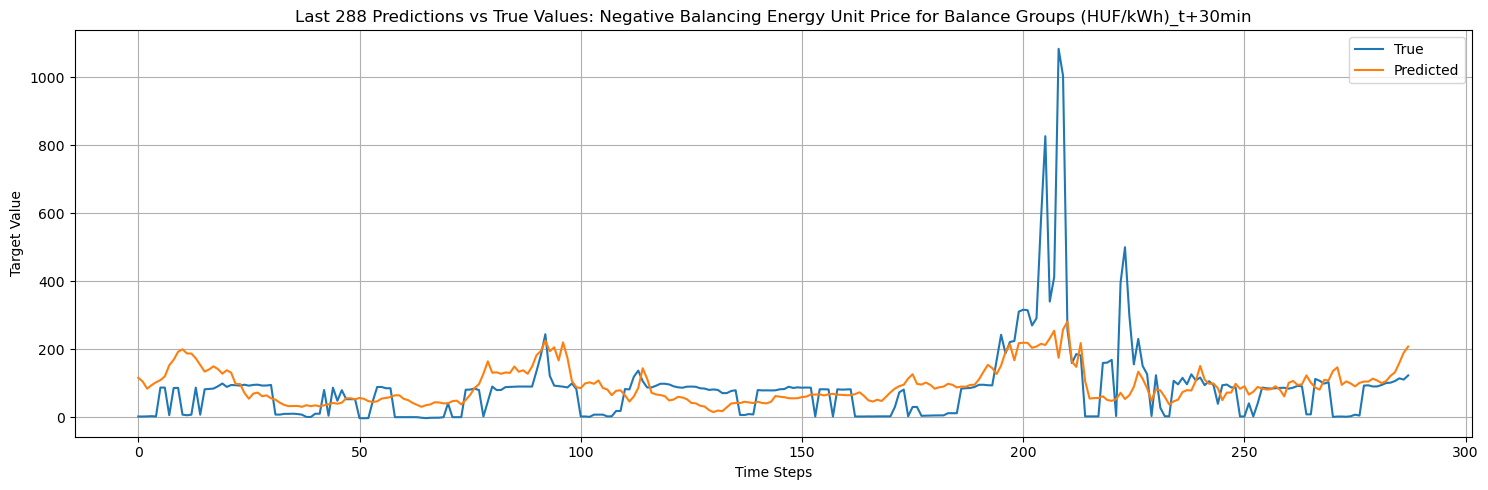

rmse: 93.59802962580606
mae: 63.41138261719011
r2: 0.056273460388183594


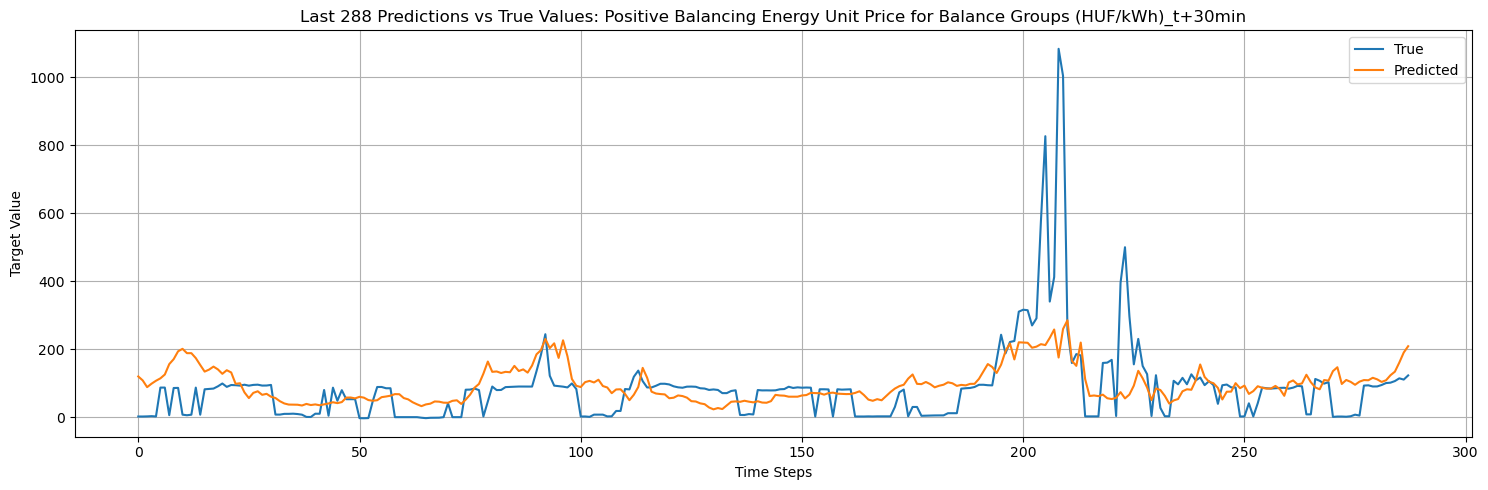

rmse: 95.29117817261574
mae: 66.0851365182245
r2: 0.02182149887084961


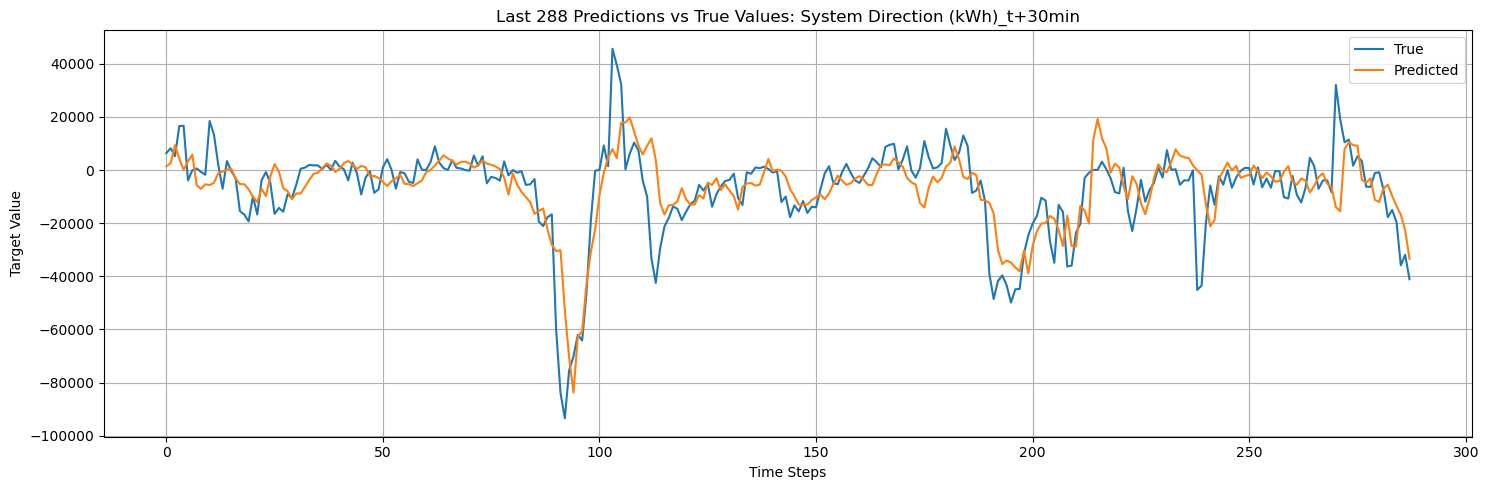

rmse: 18954.149633430046
mae: 12768.688746186934
r2: 0.5215461254119873


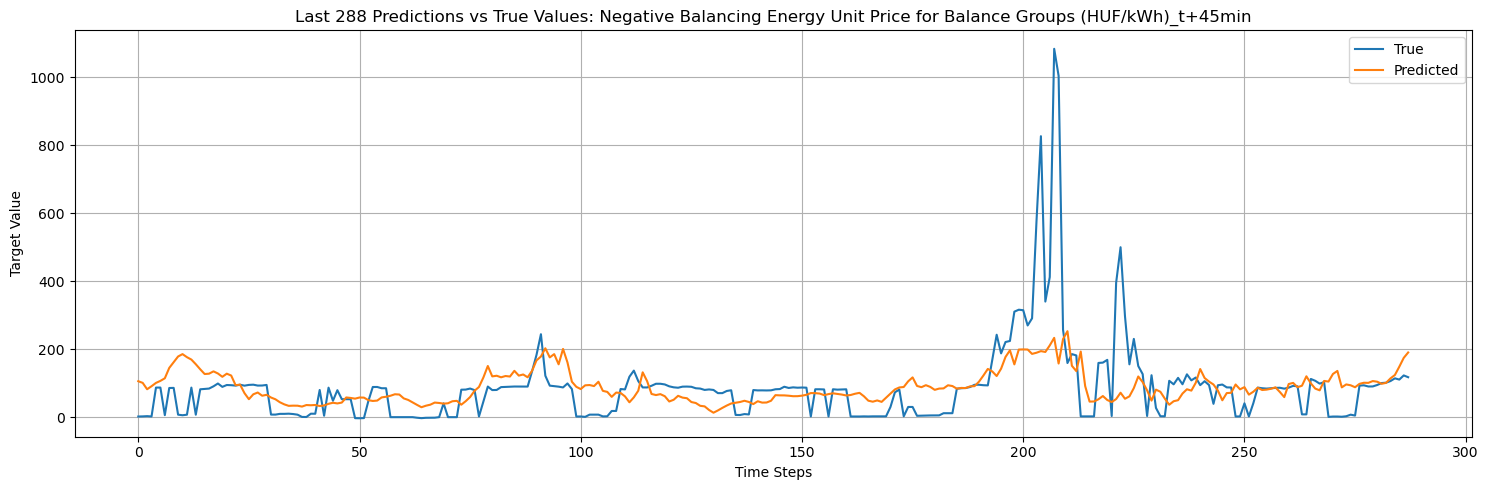

rmse: 93.82913258203052
mae: 61.11980546439868
r2: 0.051329612731933594


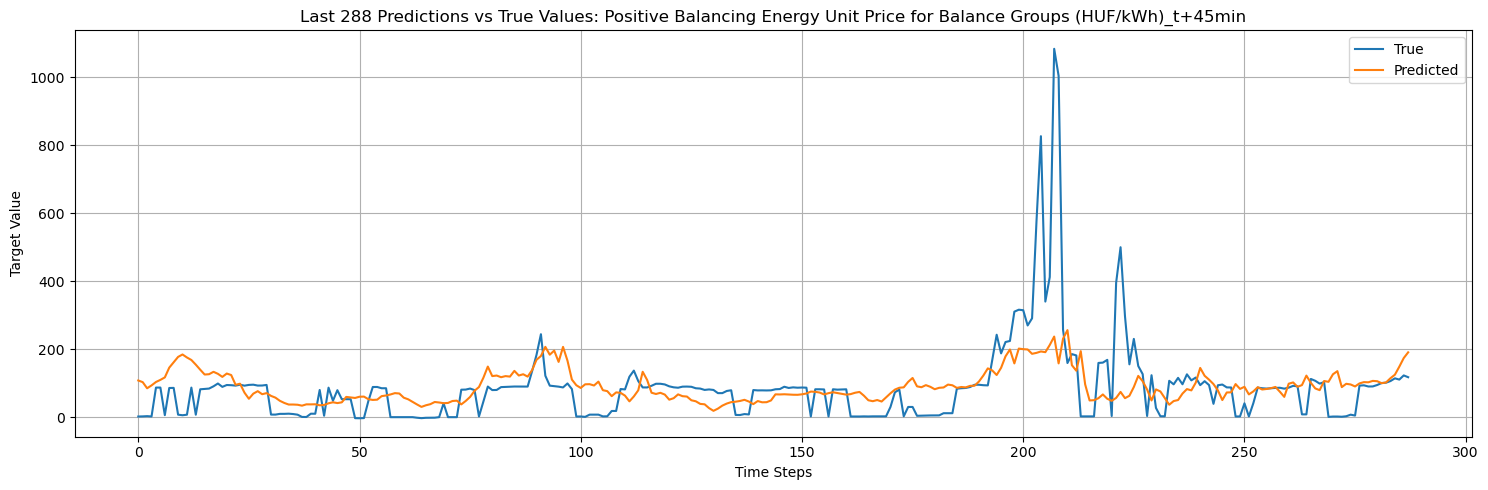

rmse: 94.269723385941
mae: 62.14715199433798
r2: 0.04239934682846069


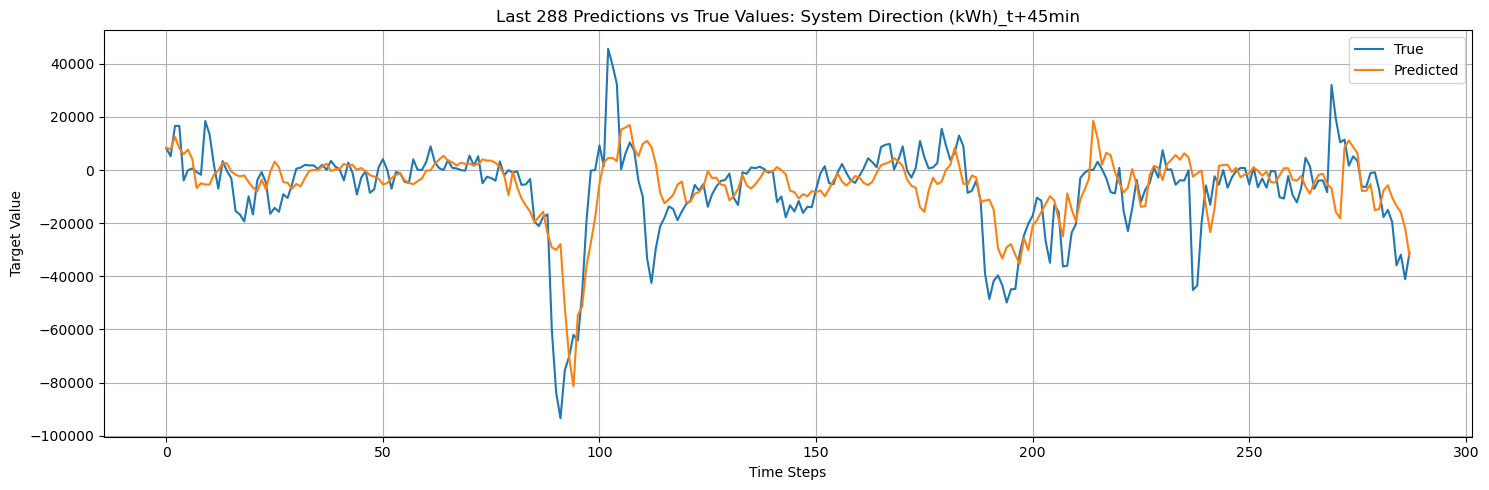

rmse: 21214.94008855461
mae: 14062.966178511811
r2: 0.40045249462127686


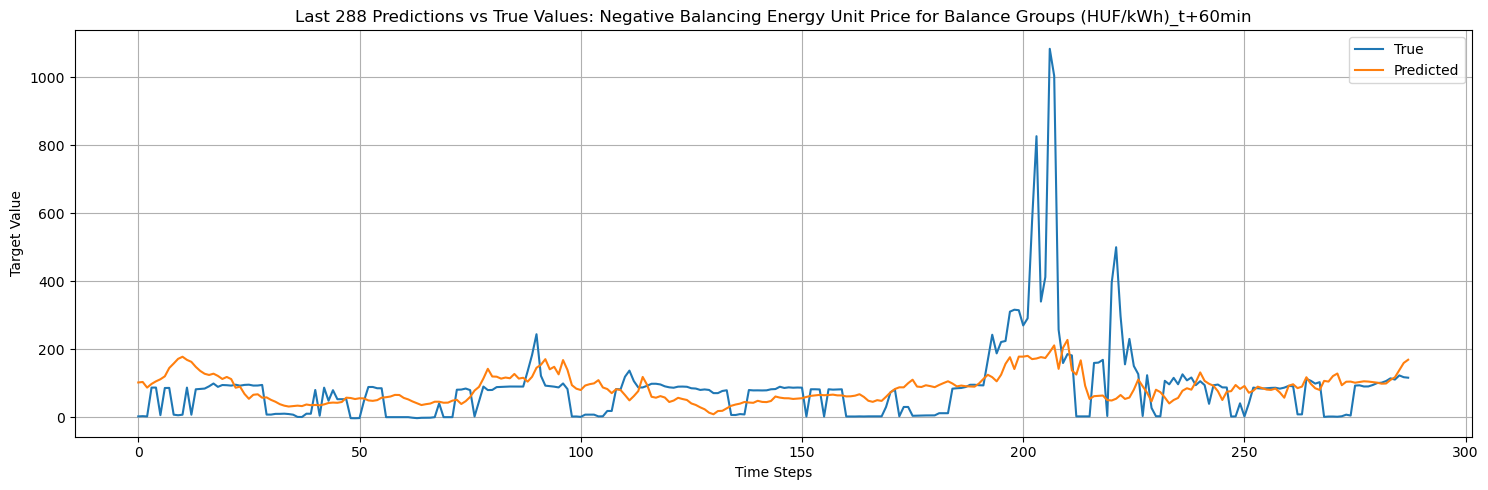

rmse: 96.50190677429259
mae: 65.11776910889499
r2: -0.003843069076538086


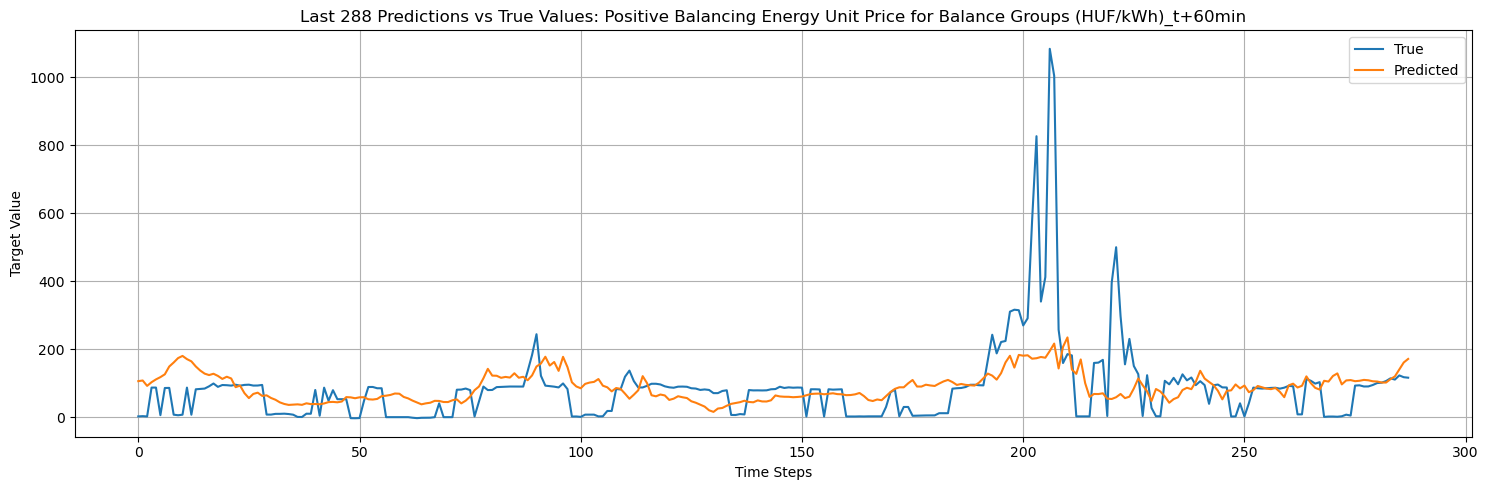

rmse: 97.81190394722888
mae: 67.23705713071656
r2: -0.03128206729888916


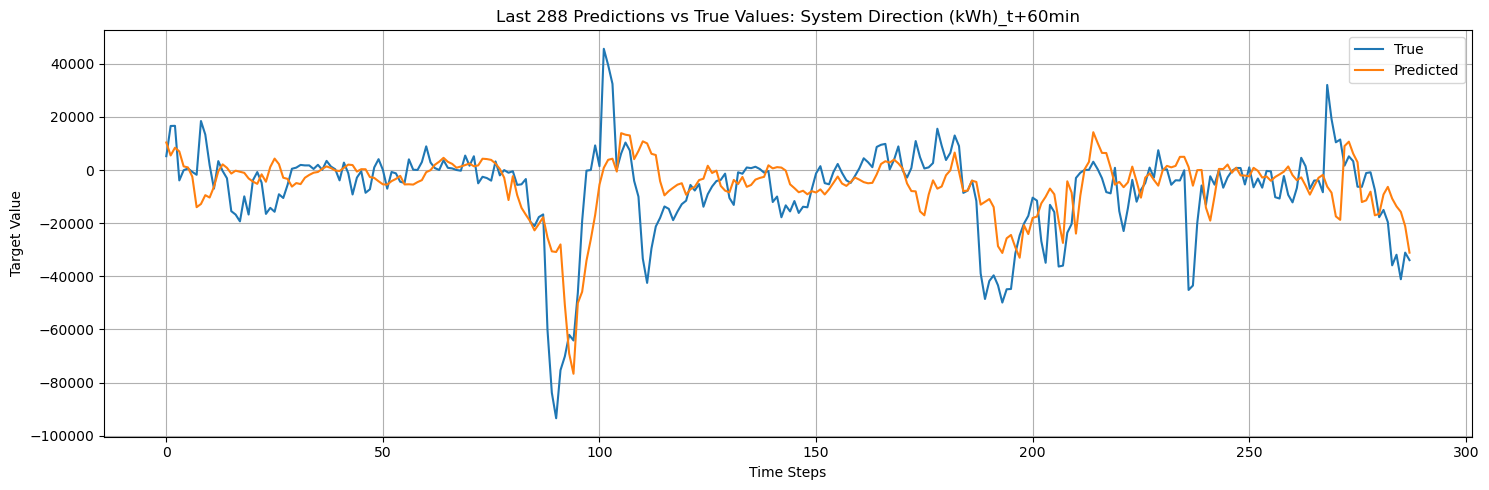

rmse: 22922.18446349438
mae: 14958.258175387104
r2: 0.2998695969581604


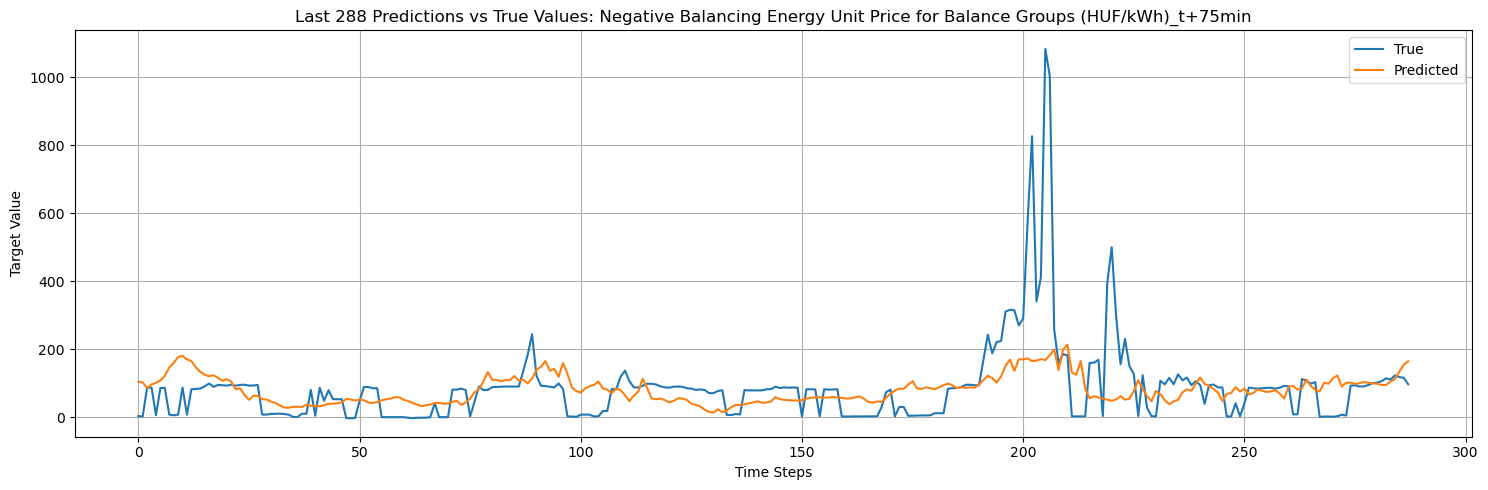

rmse: 97.5136233313708
mae: 64.5571109851327
r2: -0.025397062301635742


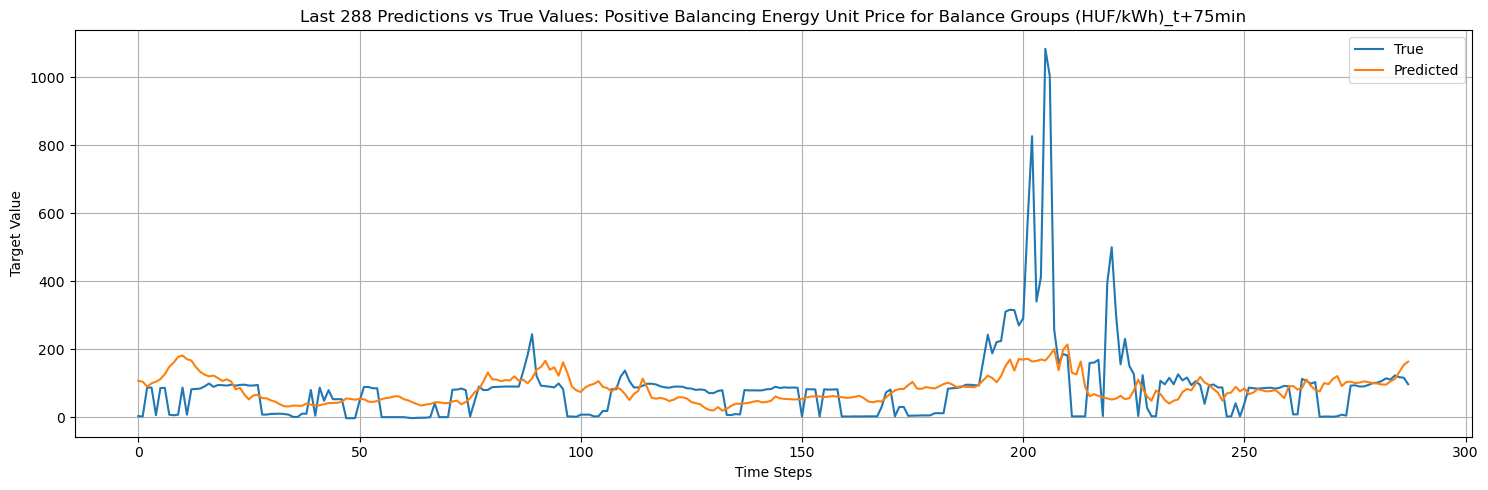

rmse: 98.28886531452562
mae: 66.0803009116283
r2: -0.041765809059143066


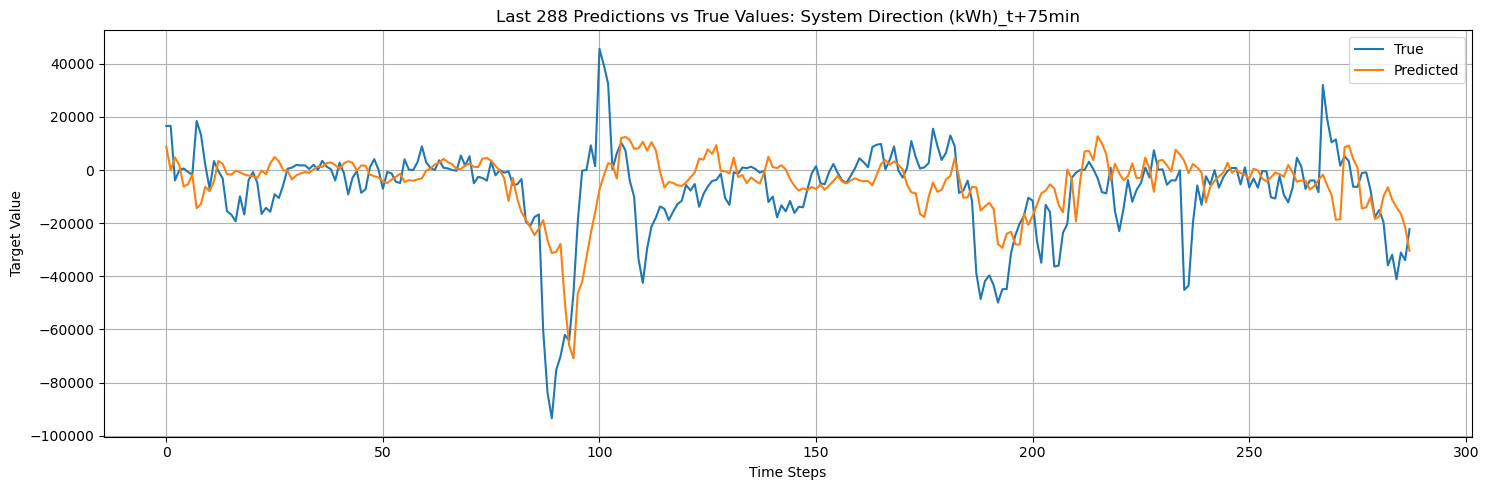

rmse: 24775.357357366283
mae: 15916.826049659627
r2: 0.1819831132888794


,Target,RMSE,MAE,R²
0,Negative Balancing Energy Unit Price for Balan...,87.296890,59.909251,0.179430
3,Negative Balancing Energy Unit Price for Balan...,93.598030,63.411383,0.056273
6,Negative Balancing Energy Unit Price for Balan...,93.829133,61.119805,0.051330
9,Negative Balancing Energy Unit Price for Balan...,96.501907,65.117769,-0.003843
12,Negative Balancing Energy Unit Price for Balan...,97.513623,64.557111,-0.025397
1,Positive Balancing Energy Unit Price for Balan...,87.745607,60.885643,0.170973
4,Positive Balancing Energy Unit Price for Balan...,95.291178,66.085137,0.021821
7,Positive Balancing Energy Unit Price for Balan...,94.269723,62.147152,0.042399
10,Positive Balancing Energy Unit Price for Balan...,97.811904,67.237057,-0.031282
13,Positive Balancing Energy Unit Price for Balan...,98.288865,66.080301,-0.041766


In [4]:
from preprocess_dataset_for_training import create_training_data
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Load data and create training sets (X: all predictors, y: all targets)
joined_df = pl.read_parquet("data/joined_df.parquet")
X, y = create_training_data(joined_df)  # y: multi-target

# Split data once
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Scale predictors
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define the multi-output neural network model
model = Sequential(
    [
        Dense(256, activation="relu", input_shape=(X_train_scaled.shape[1],)),
        Dropout(0.3),
        Dense(256, activation="relu"),
        Dropout(0.2),
        Dense(y_train.shape[1]),  # number of outputs equals number of target columns
    ]
)
model.compile(optimizer="adam", loss="mse", metrics=[tf.keras.metrics.RootMeanSquaredError()])

# Train the model with visible epochs output (verbose=1)
model.fit(X_train_scaled, y_train, epochs=20, batch_size=32, verbose=1, validation_split=0.1)

# Predict multi-target outputs
y_pred = model.predict(X_test_scaled)

# Evaluate and plot per target column
results = []
for idx, col in enumerate(y.columns):
    rmse = np.sqrt(mean_squared_error(y_test[col], y_pred[:, idx]))
    mae = mean_absolute_error(y_test[col], y_pred[:, idx])
    r2 = r2_score(y_test[col], y_pred[:, idx])

    plt.figure(figsize=(15, 5))
    plt.plot(y_test[col][-288:], label="True")
    plt.plot(y_pred[-288:, idx], label="Predicted")
    plt.title(f"Last 288 Predictions vs True Values: {col}")
    plt.xlabel("Time Steps")
    plt.ylabel("Target Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    print("rmse:", rmse)
    print("mae:", mae)
    print("r2:", r2)
    results.append({"Target": col, "RMSE": rmse, "MAE": mae, "R²": r2})

results_df = pd.DataFrame(results)
display(results_df.sort_values("Target"))

In [47]:
results_df.to_parquet("dense_results.parquet")

In [ ]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS
import tqdm
import logging
import os

# Assuming your create_training_data returns (X, y) where y is a DataFrame of targets
from preprocess_dataset_for_training import create_training_data

# Load data
joined_df = pl.read_parquet("data/joined_df.parquet")
X, y = create_training_data(joined_df)

# Convert "Időpont" column to pandas datetime (remove tz if any to avoid merge issues)
time_index = joined_df["Időpont"].to_pandas()
time_index = time_index.iloc[-len(X) :].reset_index(drop=True)
time_index = time_index.dt.tz_localize(None)  # Remove timezone if exists

assert len(time_index) == len(X) == len(y), "Mismatch in data lengths!"

# Parameters
h = 6  # forecast horizon steps (6 steps ahead)
input_size = 96  # input history size (e.g., 96 x 15min = 24h)
stride = h  # rolling window stride

results = []

for col in y.columns:
    print(f"Training NHITS for target: {col}")

    # Prepare dataframe for NeuralForecast
    df_nf = pd.DataFrame({"unique_id": "series_1", "ds": time_index, "y": y[col]})

    # Split train/test
    split_idx = int(len(df_nf) * 0.8)
    df_train = df_nf.iloc[:split_idx].copy().reset_index(drop=True)
    df_test = df_nf.iloc[split_idx:].copy().reset_index(drop=True)

    # Define NHITS model
    model = NHITS(h=h, input_size=input_size, max_steps=300, batch_size=32)
    nf = NeuralForecast(models=[model], freq="15min")

    # Train once on train set
    nf.fit(df_train)

    # Rolling forecast on test set without retraining
    y_trues = []
    y_preds = []

    n_windows = (len(df_test) - input_size - h) // stride
    print(f"Number of test windows: {n_windows}")

    for i in range(n_windows):
        start_idx = i * stride
        end_idx = start_idx + input_size

        # Build test window with history + horizon
        df_window = df_test.iloc[start_idx : end_idx + h].copy().reset_index(drop=True)

        # Predict next h steps from this window, no retraining
        forecast_window = nf.predict(df=df_window, verbose=False)

        y_pred = forecast_window["NHITS"].values
        y_true = df_window["y"].iloc[input_size : input_size + h].values

        if len(y_true) < h:
            break

        y_preds.append(y_pred)
        y_trues.append(y_true)

    y_preds = np.stack(y_preds)
    y_trues = np.stack(y_trues)

    # Calculate and print metrics per forecast step
    for step in range(h):
        rmse = np.sqrt(mean_squared_error(y_trues[:, step], y_preds[:, step]))
        mae = mean_absolute_error(y_trues[:, step], y_preds[:, step])
        r2 = r2_score(y_trues[:, step], y_preds[:, step])

        print(f"Step {step + 1}: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}")

        results.append({"Target": col, "Step (t+min)": (step + 1) * 15, "RMSE": rmse, "MAE": mae, "R²": r2})

    # Plot last forecast window
    plt.figure(figsize=(15, 5))
    plt.plot(y_trues[-1], label="True")
    plt.plot(y_preds[-1], label="NHITS Predicted")
    plt.title(f"NHITS Last Forecast Window: {col}")
    plt.xlabel("Forecast Step")
    plt.ylabel("Target Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Summary of all results
results_df = pd.DataFrame(results)
display(results_df.sort_values(["Target", "Step (t+min)"]))

Seed set to 1


Training NHITS for target: Negative Balancing Energy Unit Price for Balance Groups (HUF/kWh)_t+15min


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
from preprocess_dataset_for_training import create_training_data
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Load data and create training sets (X: all predictors, y: all target columns)
joined_df = pl.read_parquet("data/joined_df.parquet")
X, y = create_training_data(joined_df)

results = []

# Split data once for all targets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Scale predictors
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape predictors for LSTM: (samples, timesteps=1, features)
X_train_reshaped = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_reshaped = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

# Define the multitarget LSTM model
model = Sequential(
    [
        LSTM(128, input_shape=(1, X_train_scaled.shape[1])),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dropout(0.2),
        Dense(y_train.shape[1]),  # multitarget output
    ]
)
model.compile(optimizer="adam", loss="mse", metrics=[tf.keras.metrics.RootMeanSquaredError()])

# Train the model
model.fit(X_train_reshaped, y_train.to_numpy(), epochs=20, batch_size=128, verbose=2)

# Predict and evaluate
y_pred = model.predict(X_test_reshaped)

for idx, col in enumerate(y.columns):
    rmse = np.sqrt(mean_squared_error(y_test[col], y_pred[:, idx]))
    mae = mean_absolute_error(y_test[col], y_pred[:, idx])
    r2 = r2_score(y_test[col], y_pred[:, idx])

    # Plot the last 288 observations
    plt.figure(figsize=(15, 5))
    plt.plot(y_test[col][-288:], label="True")
    plt.plot(y_pred[-288:, idx], label="Predicted")
    plt.title(f"Last 288 Predictions vs True Values: {col} (LSTM)")
    plt.xlabel("Time Steps")
    plt.ylabel("Target Value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    print("rmse:", rmse)
    print("mae:", mae)
    print("r2:", r2)
    results.append({"Target": col, "RMSE": rmse, "MAE": mae, "R²": r2})

results_df = pd.DataFrame(results)
display(results_df.sort_values("Target"))

In [2]:
results_df.to_parquet("lstm_results.parquet")

In [ ]:
results = (
    pl.from_pandas(results_df)
    .unpivot(["MAE", "RMSE", "R²"], index=["Target"], variable_name="error measure", value_name="error")
    .with_columns(
        (pl.col("Target").str.extract("_t\+(\d*)min").cast(pl.Int32) * 60 * 1000).cast(pl.Datetime("ms")),
    )
)
sys_dir = results.filter((pl.col("target") == "System Direction (kWh)"))
unit_prices = results.filter((pl.col("target") != "System Direction (kWh)"))

chart = lag_chart(sys_dir.filter(pl.col("error measure").is_in(("rmse", "mae"))), ["blue"])
chart.save("figures/LSTM_rmse_system_direction.png")

chart = lag_chart(unit_prices.filter(pl.col("error measure").is_in(("rmse", "mae"))))
chart.save("figures/LSTM_rmse_unit_price.png")

chart = lag_chart(results.filter(pl.col("error measure") == "R2"), ["red", "green", "blue"])
chart.save("figures/LSTM_R2.png")

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd


# ------------------ Positional Encoding ------------------
class PositionalEncoding(layers.Layer):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.pos_encoding = tf.constant(angle_rads[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        return x + self.pos_encoding[:, : tf.shape(x)[1], :]


# ------------------ Transformer Encoder Block ------------------
def transformer_encoder(inputs, head_size=64, num_heads=4, ff_dim=128, dropout=0.1):
    x = layers.MultiHeadAttention(num_heads=num_heads, key_dim=head_size)(inputs, inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x + inputs)

    ff = layers.Dense(ff_dim, activation="relu")(x)
    ff = layers.Dense(inputs.shape[-1])(ff)
    ff = layers.Dropout(dropout)(ff)
    return layers.LayerNormalization(epsilon=1e-6)(x + ff)


# ------------------ Build Transformer Model ------------------
def build_transformer_model(input_shape):
    inputs = tf.keras.Input(shape=input_shape)
    x = PositionalEncoding(d_model=input_shape[1])(inputs)

    x = transformer_encoder(x)
    x = transformer_encoder(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.1)(x)
    outputs = layers.Dense(1)(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer="adam", loss="mse", metrics=[tf.keras.metrics.RootMeanSquaredError()])
    return model


# ------------------ Main Forecasting Loop ------------------
window_size = 2
results = []

# Base predictors (originals)
base_predictors = [
    "dayofweek",
    "month",
    "hour",
    "is_weekend",
    "Naperőművek becsült termelése (aktuális)",
    "Naperőművek becsült termelése (intraday)",
    "Naperőművek becsült termelése (dayahead)",
    "HU-UK",
    "HU-SK",
    "HU-RS",
    "HU-AT",
    "HU-HR",
    "HU-RO",
    "HU-AT menetrend",
    "HU-HR menetrend",
    "HU-SK menetrend",
    "HU-RS menetrend",
    "HU-UK menetrend",
    "HU-RO menetrend",
    "Bruttó terv erőművi termelés",
    "Bruttó tény erőművi termelés",
    "Bruttó hitelesített rendszerterhelés tény",
    "Bruttó rendszerterhelés becslés (dayahead)",
    "Szélerőművek becsült termelése (aktuális)",
    "Szélerőművek becsült termelése (dayahead)",
    "Szélerőművek becsült termelése (intraday)",
]

target_bases = [
    "Negatív Mérlegköri kiegyenlítő energia egységára (HUF/kWh)",
    "Pozitív Mérlegköri kiegyenlítő energia egységára (HUF/kWh)",
    "Rendszer-irány (kWh)",
]
forecast_steps = [240, 255, 270, 285, 300]

all_predictors = []
for base in base_predictors:
    if base in df.columns:
        all_predictors.append(base)
    all_predictors += [col for col in df.columns if col.startswith(base + "_t+")]

for target_base in target_bases:
    for step in forecast_steps:
        target_col = f"{target_base}_t+{step}min"
        if target_col not in df.columns:
            continue

        usable_cols = all_predictors + [target_col]
        data = df[usable_cols].dropna()
        if len(data) < window_size + 100:
            continue

        # Scale
        scaler = StandardScaler()
        data_scaled = scaler.fit_transform(data)

        # Windowed sequences
        X, y = [], []
        for i in range(len(data_scaled) - window_size):
            X.append(data_scaled[i : i + window_size, :-1])
            y.append(data_scaled[i + window_size - 1, -1])

        X = np.array(X)
        y = np.array(y)

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

        model = build_transformer_model(input_shape=X_train.shape[1:])
        early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
        model.fit(X_train, y_train, validation_split=0.1, epochs=20, batch_size=1024, callbacks=[early_stop], verbose=0)

        y_pred = model.predict(X_test).flatten()

        results.append(
            {
                "Target": target_base,
                "Step (min)": step,
                "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
                "MAE": mean_absolute_error(y_test, y_pred),
                "R²": r2_score(y_test, y_pred),
            }
        )

results_df = pd.DataFrame(results)
display(results_df.sort_values(["Target", "Step (min)"]))

KeyboardInterrupt: 